## Abgrenzung der Datengrundlage

### verfügbaren Filter

| Variable | Filter-Kriterium | Beschreibung | Basis |
|----------|------------------|--------------|-------|
| `filter_dict['alle_daten']` | - | Kompletter Datensatz | Alle |
| `filter_dict['ohne_ausland']` | `Bezirk != 'Ausland'` | Nur deutsche Spieler | Alle |
| `filter_dict['nur_aktive']` | `Status in ['a', 'n']` | Nur aktive Spieler | Alle |
| `filter_dict['top_1_positiv']` | Top 1% Quantil (0.99) | Beste 1% TTR-Sprünge | Ohne Ausland |
| `filter_dict['top_1_negativ']` | Bottom 1% Quantil (0.01) | Schlimmste 1% TTR-Abstürze | Ohne Ausland |
| `filter_dict['top_5_positiv']` | Top 5% Quantil (0.95) | Beste 5% TTR-Sprünge | Ohne Ausland |
| `filter_dict['top_5_negativ']` | Bottom 5% Quantil (0.05) | Schlimmste 5% TTR-Abstürze | Ohne Ausland |
| `filter_dict['verbandswechsler']` | `Verbandswechsel_vorhanden == 'Ja'` | Spieler mit Verbandswechsel | Alle |
| `filter_dict['viel_spieler']` | `≥10 neue Spiele` | Mindestens 10 neue Spiele/Quartal | Alle |
| `filter_dict['aktive_ohne_ausland']` | Kombination | Aktive deutsche Spieler | Alle |

In [13]:
#------------------------------------------------------#
#-#-#-#-#-#-#-#-#-#-#-# Librarys #-#-#-#-#-#-#-#-#-#-#-#
#------------------------------------------------------#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [10]:
########################################################
#--------------------- Import Data --------------------#
########################################################

TTR_Entwicklung_import = pd.read_csv("/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data/TTR_Entwicklung_ERWEITERT_2023_2025.csv")

## Filter

In [11]:
print(f"Gesamtdatensatz: {len(TTR_Entwicklung_import)} Zeilen")

# 1. Keine Ausländer
df_ohne_ausland = TTR_Entwicklung_import[TTR_Entwicklung_import['Bezirk'] != 'Ausland'].copy()
print(f"Filter 1 - Ohne Ausland: {len(df_ohne_ausland)} Zeilen")

# 2. Nur Aktive Spieler
df_nur_aktive = TTR_Entwicklung_import[TTR_Entwicklung_import['Status'].isin(['a', 'n'])].copy()
print(f"Filter 2 - Nur Aktive: {len(df_nur_aktive)} Zeilen")

# 3. Top 1% positive TTR-Sprünge (Quartal-zu-Quartal, ohne Ausländer)
quartal_spalten = [
    'Q-TTR_dif_23_Q1-23_Q2', 'Q-TTR_dif_23_Q2-23_Q3', 'Q-TTR_dif_23_Q3-23_Q4', 'Q-TTR_dif_23_Q4-24_Q1',
    'Q-TTR_dif_24_Q1-24_Q2', 'Q-TTR_dif_24_Q2-24_Q3', 'Q-TTR_dif_24_Q3-24_Q4', 'Q-TTR_dif_24_Q4-25_Q1'
]

# Alle Quartal-zu-Quartal Werte sammeln (ohne Ausländer)
df_temp = df_ohne_ausland[quartal_spalten + ['InterneNr']].copy()
alle_werte = []
for col in quartal_spalten:
    temp_df = df_temp[['InterneNr', col]].copy()
    temp_df = temp_df.dropna()
    temp_df['Spalte'] = col
    temp_df = temp_df.rename(columns={col: 'TTR_Veraenderung'})
    alle_werte.append(temp_df)

alle_ttr_veraenderungen = pd.concat(alle_werte, ignore_index=True)

# Top 1% positive Veränderungen
top_1_prozent_positiv_schwelle = alle_ttr_veraenderungen['TTR_Veraenderung'].quantile(0.99)
top_spieler_positiv = alle_ttr_veraenderungen[
    alle_ttr_veraenderungen['TTR_Veraenderung'] >= top_1_prozent_positiv_schwelle
]['InterneNr'].unique()
df_top_positiv = df_ohne_ausland[df_ohne_ausland['InterneNr'].isin(top_spieler_positiv)].copy()
print(f"Filter 3 - Top 1% positive TTR-Sprünge: {len(df_top_positiv)} Zeilen (Schwelle: {top_1_prozent_positiv_schwelle:.1f})")

# 4. Verbandswechsler
df_verbandswechsler = TTR_Entwicklung_import[TTR_Entwicklung_import['Verbandswechsel_vorhanden'] == 'Ja'].copy()
print(f"Filter 4 - Verbandswechsler: {len(df_verbandswechsler)} Zeilen")

# 5. Top 1% negative TTR-Abstürze (ohne Ausländer)
top_1_prozent_negativ_schwelle = alle_ttr_veraenderungen['TTR_Veraenderung'].quantile(0.01)
top_spieler_negativ = alle_ttr_veraenderungen[
    alle_ttr_veraenderungen['TTR_Veraenderung'] <= top_1_prozent_negativ_schwelle
]['InterneNr'].unique()
df_top_negativ = df_ohne_ausland[df_ohne_ausland['InterneNr'].isin(top_spieler_negativ)].copy()
print(f"Filter 5 - Top 1% negative TTR-Abstürze: {len(df_top_negativ)} Zeilen (Schwelle: {top_1_prozent_negativ_schwelle:.1f})")

# 6. Top 5% positive TTR-Sprünge (ohne Ausländer)
top_5_prozent_positiv_schwelle = alle_ttr_veraenderungen['TTR_Veraenderung'].quantile(0.95)
top_5_spieler_positiv = alle_ttr_veraenderungen[
    alle_ttr_veraenderungen['TTR_Veraenderung'] >= top_5_prozent_positiv_schwelle
]['InterneNr'].unique()
df_top_5_positiv = df_ohne_ausland[df_ohne_ausland['InterneNr'].isin(top_5_spieler_positiv)].copy()
print(f"Filter 6 - Top 5% positive TTR-Sprünge: {len(df_top_5_positiv)} Zeilen (Schwelle: {top_5_prozent_positiv_schwelle:.1f})")

# 7. Top 5% negative TTR-Abstürze (ohne Ausländer)
top_5_prozent_negativ_schwelle = alle_ttr_veraenderungen['TTR_Veraenderung'].quantile(0.05)
top_5_spieler_negativ = alle_ttr_veraenderungen[
    alle_ttr_veraenderungen['TTR_Veraenderung'] <= top_5_prozent_negativ_schwelle
]['InterneNr'].unique()
df_top_5_negativ = df_ohne_ausland[df_ohne_ausland['InterneNr'].isin(top_5_spieler_negativ)].copy()
print(f"Filter 7 - Top 5% negative TTR-Abstürze: {len(df_top_5_negativ)} Zeilen (Schwelle: {top_5_prozent_negativ_schwelle:.1f})")

# 8. Viel-Spieler (mindestens 10 neue Spiele in mindestens einem Quartal)
neue_spiele_spalten = [
    'Neue_Spiele_Q1_Q2_2023', 'Neue_Spiele_Q2_Q3_2023', 'Neue_Spiele_Q3_Q4_2023', 'Neue_Spiele_Q4_23_Q1_24',
    'Neue_Spiele_Q1_Q2_2024', 'Neue_Spiele_Q2_Q3_2024', 'Neue_Spiele_Q3_Q4_2024', 'Neue_Spiele_Q4_24_Q1_25'
]

df_temp_spiele = TTR_Entwicklung_import[neue_spiele_spalten].copy()
df_temp_spiele = df_temp_spiele.fillna(0)
max_neue_spiele = df_temp_spiele.max(axis=1)
df_viel_spieler = TTR_Entwicklung_import[max_neue_spiele >= 10].copy()
print(f"Filter 8 - Viel-Spieler (≥10 neue Spiele): {len(df_viel_spieler)} Zeilen")

# Kombinierte Filter für praktische Nutzung
df_aktive_ohne_ausland = TTR_Entwicklung_import[(TTR_Entwicklung_import['Bezirk'] != 'Ausland') & (TTR_Entwicklung_import['Status'].isin(['a', 'n']))].copy()
print(f"Kombination - Aktive ohne Ausland: {len(df_aktive_ohne_ausland)} Zeilen")

# Variablen für Export verfügbar machen
filter_dict = {
    'alle_daten': TTR_Entwicklung_import,
    'ohne_ausland': df_ohne_ausland,
    'nur_aktive': df_nur_aktive,
    'top_1_positiv': df_top_positiv,
    'top_1_negativ': df_top_negativ,
    'top_5_positiv': df_top_5_positiv,
    'top_5_negativ': df_top_5_negativ,
    'verbandswechsler': df_verbandswechsler,
    'viel_spieler': df_viel_spieler,
    'aktive_ohne_ausland': df_aktive_ohne_ausland
}

print(f"\n=== VERFÜGBARE FILTER-VARIABLEN ===")
for key, value in filter_dict.items():
    print(f"{key}: {len(value)} Zeilen")

Gesamtdatensatz: 793163 Zeilen
Filter 1 - Ohne Ausland: 760712 Zeilen
Filter 2 - Nur Aktive: 417545 Zeilen
Filter 3 - Top 1% positive TTR-Sprünge: 43613 Zeilen (Schwelle: 53.0)
Filter 4 - Verbandswechsler: 57191 Zeilen
Filter 5 - Top 1% negative TTR-Abstürze: 58481 Zeilen (Schwelle: -49.0)
Filter 6 - Top 5% positive TTR-Sprünge: 161359 Zeilen (Schwelle: 15.0)
Filter 7 - Top 5% negative TTR-Abstürze: 202537 Zeilen (Schwelle: -20.0)
Filter 8 - Viel-Spieler (≥10 neue Spiele): 192037 Zeilen
Kombination - Aktive ohne Ausland: 386299 Zeilen

=== VERFÜGBARE FILTER-VARIABLEN ===
alle_daten: 793163 Zeilen
ohne_ausland: 760712 Zeilen
nur_aktive: 417545 Zeilen
top_1_positiv: 43613 Zeilen
top_1_negativ: 58481 Zeilen
top_5_positiv: 161359 Zeilen
top_5_negativ: 202537 Zeilen
verbandswechsler: 57191 Zeilen
viel_spieler: 192037 Zeilen
aktive_ohne_ausland: 386299 Zeilen


# Deskriptiver Überblick über Veränderungen

Starte deskriptive Analyse der TTR-Veränderungen...
DESKRIPTIVER ÜBERBLICK TTR-VERÄNDERUNGEN

Gefundene TTR-Spalten: 9
Gefundene TTR-Differenz-Spalten: 16

GRUNDLEGENDE TTR-STATISTIKEN
         TTR_Q1_2023    TTR_Q2_2023    TTR_Q3_2023    TTR_Q4_2023  \
count  712259.000000  715793.000000  719198.000000  736034.000000   
mean     1104.236651    1102.995117    1102.864085    1097.409810   
std       243.485550     243.474848     243.239940     242.885542   
min       473.000000     473.000000     473.000000     473.000000   
25%       929.000000     929.000000     928.000000     923.000000   
50%      1061.000000    1060.000000    1059.000000    1055.000000   
75%      1244.000000    1242.000000    1241.000000    1234.000000   
max      2682.000000    2682.000000    2682.000000    2682.000000   

         TTR_Q1_2024    TTR_Q2_2024    TTR_Q3_2024    TTR_Q4_2024  \
count  739470.000000  742780.000000  745742.000000  760485.000000   
mean     1097.013059    1096.033408    1095.979860    1

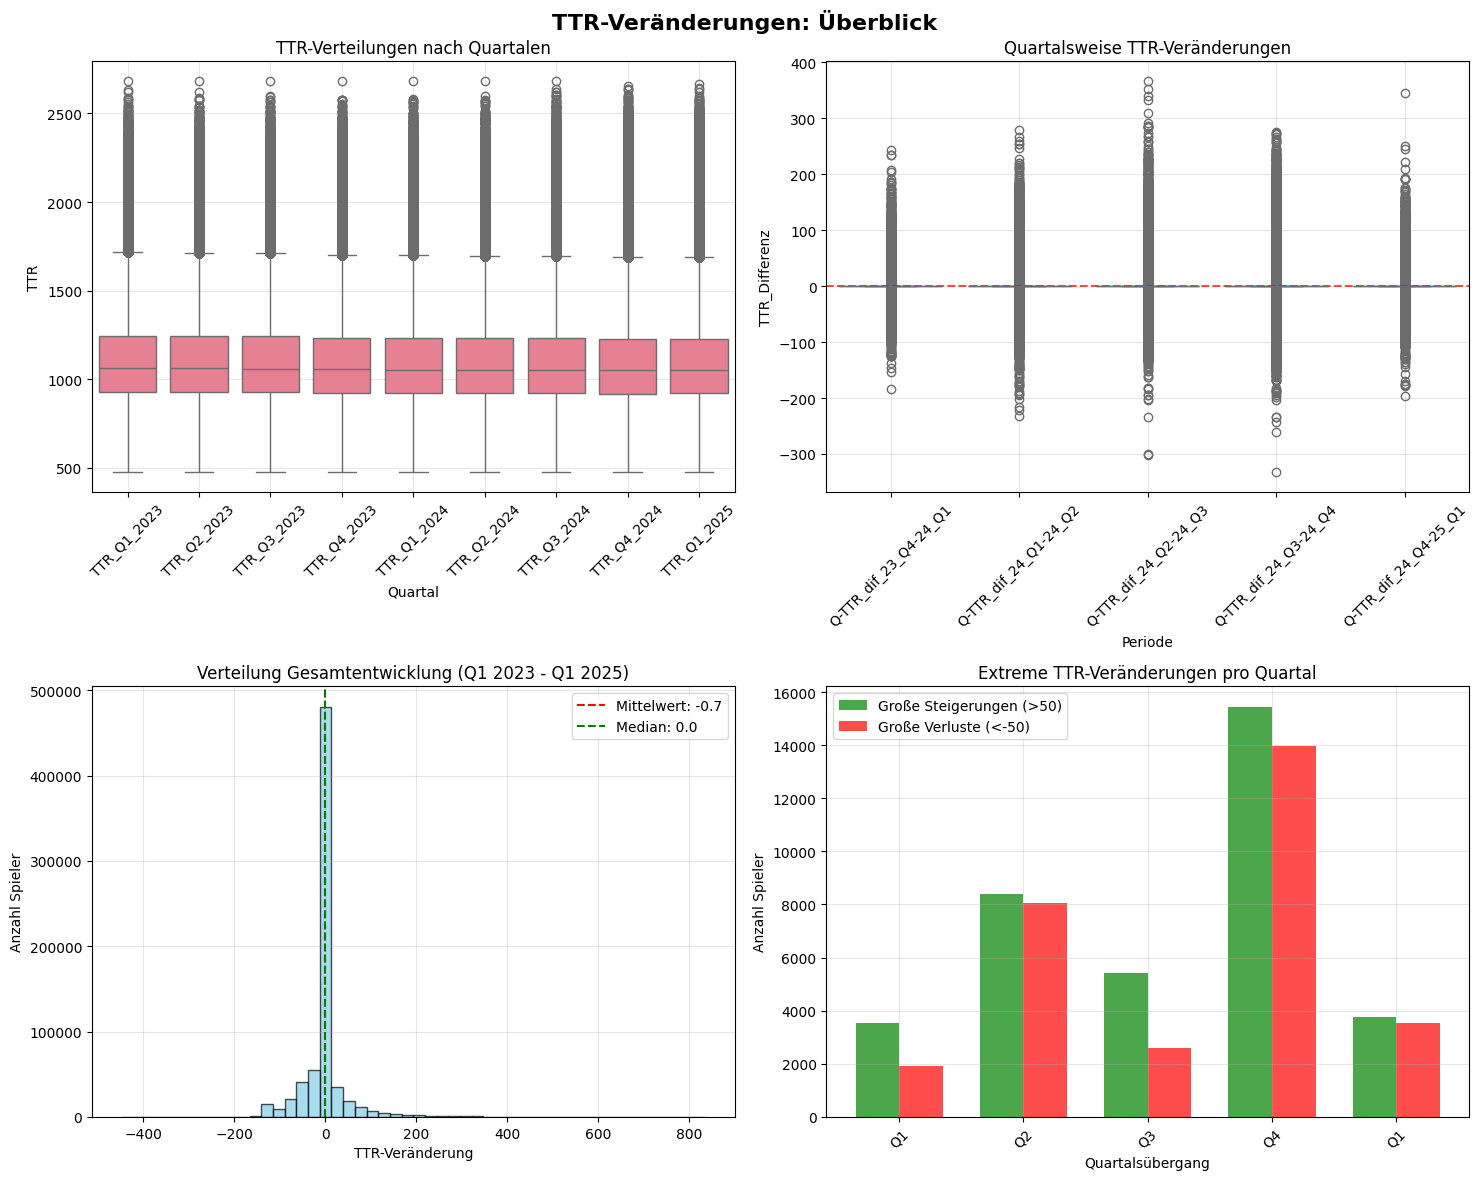

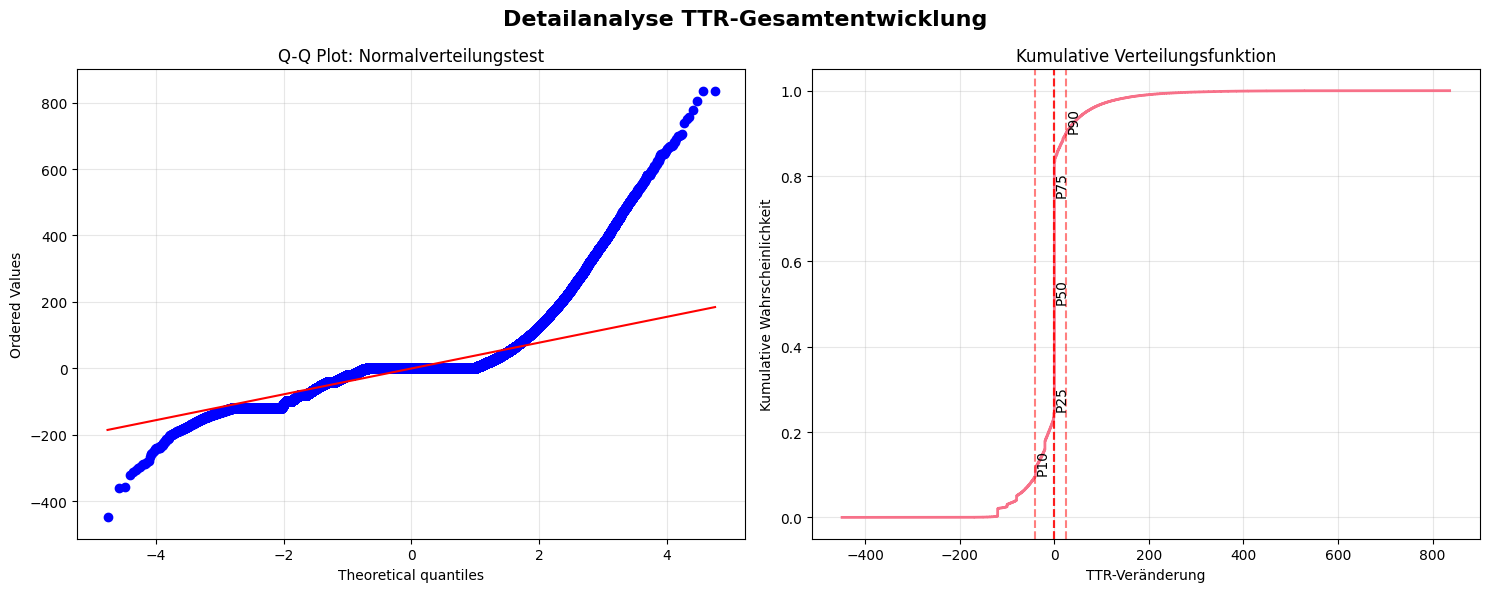


ANALYSE NACH KATEGORIEN

--- GESCHLECHT ---
             count  mean   std  median    min    max
Geschlecht                                          
M           605250  -0.6  49.2     0.0 -449.0  836.0
W           106765  -1.2  43.4     0.0 -255.0  668.0

--- ALTERSKLASSE ---
                         count   mean    std  median    min    max
Altersklasse                                                      
Damen                     6356   -2.1   67.5    -6.0 -214.0  668.0
Damen/Herren                86  -27.4   62.2     0.0 -167.0  199.0
Freizeit/Betriebssport     315  -10.1   48.9    -9.0 -128.0  183.0
Herren                  176550    3.0   72.3    -5.0 -449.0  836.0
Jugend 13                   29   83.9  118.6    86.0 -184.0  276.0
Jugend 19                 3659   69.7   91.3    55.0 -188.0  738.0
Jungen                     391   94.9  105.0    64.0  -84.0  567.0
Jungen 11                   33   84.0   83.6    73.0  -67.0  275.0
Jungen 11/13                 0    NaN    NaN     Na

In [22]:
def analyze_ttr_changes(df):
    """
    Deskriptive Analyse der TTR-Veränderungen
    """
    
    print("="*60)
    print("DESKRIPTIVER ÜBERBLICK TTR-VERÄNDERUNGEN")
    print("="*60)
    
    # 1. TTR-Spalten identifizieren
    ttr_cols = [col for col in df.columns if col.startswith('TTR_Q') and 'dif' not in col]
    ttr_diff_cols = [col for col in df.columns if 'Q-TTR_dif' in col]
    
    print(f"\nGefundene TTR-Spalten: {len(ttr_cols)}")
    print(f"Gefundene TTR-Differenz-Spalten: {len(ttr_diff_cols)}")
    
    # 2. Grundlegende Statistiken der TTR-Werte
    print("\n" + "="*40)
    print("GRUNDLEGENDE TTR-STATISTIKEN")
    print("="*40)
    
    ttr_stats = df[ttr_cols].describe()
    print(ttr_stats)
    
    # 3. Analyse der quartalsweisen Veränderungen
    print("\n" + "="*40)
    print("QUARTALSWEISE VERÄNDERUNGEN")
    print("="*40)
    
    # Wichtigste Differenz-Spalten analysieren
    key_diff_cols = [
        'Q-TTR_dif_23_Q4-24_Q1',
        'Q-TTR_dif_24_Q1-24_Q2', 
        'Q-TTR_dif_24_Q2-24_Q3',
        'Q-TTR_dif_24_Q3-24_Q4',
        'Q-TTR_dif_24_Q4-25_Q1'
    ]
    
    # Nur verfügbare Spalten verwenden
    available_diff_cols = [col for col in key_diff_cols if col in df.columns]
    
    if available_diff_cols:
        diff_stats = df[available_diff_cols].describe()
        print("Quartalsweise TTR-Differenzen:")
        print(diff_stats)
        
        # Große Veränderungen identifizieren (> 50 TTR-Punkte)
        print("\n" + "-"*40)
        print("GROSSE VERÄNDERUNGEN (|Δ| > 50 TTR)")
        print("-"*40)
        
        for col in available_diff_cols:
            large_changes = df[abs(df[col]) > 50][col].dropna()
            if len(large_changes) > 0:
                print(f"\n{col}:")
                print(f"  Anzahl große Veränderungen: {len(large_changes)}")
                print(f"  Anteil der Spieler: {len(large_changes)/len(df.dropna(subset=[col]))*100:.1f}%")
                print(f"  Größte Steigerung: +{large_changes.max():.0f}")
                print(f"  Größter Verlust: {large_changes.min():.0f}")
    
    # 4. Gesamtentwicklung analysieren
    if 'TTR_Gesamt_Entwicklung_23Q1_25Q1' in df.columns:
        print("\n" + "="*40)
        print("GESAMTENTWICKLUNG (Q1 2023 - Q1 2025)")
        print("="*40)
        
        gesamt_entwicklung = df['TTR_Gesamt_Entwicklung_23Q1_25Q1'].dropna()
        
        print(f"Anzahl Spieler mit Gesamtentwicklung: {len(gesamt_entwicklung)}")
        print(f"Durchschnittliche Entwicklung: {gesamt_entwicklung.mean():.1f} TTR")
        print(f"Standardabweichung: {gesamt_entwicklung.std():.1f} TTR")
        print(f"Median: {gesamt_entwicklung.median():.1f} TTR")
        
        # Kategorisierung der Entwicklung
        stark_gestiegen = len(gesamt_entwicklung[gesamt_entwicklung > 100])
        moderat_gestiegen = len(gesamt_entwicklung[(gesamt_entwicklung > 20) & (gesamt_entwicklung <= 100)])
        stabil = len(gesamt_entwicklung[(gesamt_entwicklung >= -20) & (gesamt_entwicklung <= 20)])
        moderat_gefallen = len(gesamt_entwicklung[(gesamt_entwicklung >= -100) & (gesamt_entwicklung < -20)])
        stark_gefallen = len(gesamt_entwicklung[gesamt_entwicklung < -100])
        
        print(f"\nKategorisierung:")
        print(f"  Stark gestiegen (>100): {stark_gestiegen} ({stark_gestiegen/len(gesamt_entwicklung)*100:.1f}%)")
        print(f"  Moderat gestiegen (20-100): {moderat_gestiegen} ({moderat_gestiegen/len(gesamt_entwicklung)*100:.1f}%)")
        print(f"  Stabil (-20 bis +20): {stabil} ({stabil/len(gesamt_entwicklung)*100:.1f}%)")
        print(f"  Moderat gefallen (-100 bis -20): {moderat_gefallen} ({moderat_gefallen/len(gesamt_entwicklung)*100:.1f}%)")
        print(f"  Stark gefallen (<-100): {stark_gefallen} ({stark_gefallen/len(gesamt_entwicklung)*100:.1f}%)")
    
    return ttr_cols, available_diff_cols

def create_visualizations(df, ttr_cols, diff_cols):
    """
    Erstellt Visualisierungen der TTR-Veränderungen
    """
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # 1. TTR-Verteilungen über Zeit
    if len(ttr_cols) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('TTR-Veränderungen: Überblick', fontsize=16, fontweight='bold')
        
        # Subplot 1: TTR-Verteilungen über Quartale
        ax1 = axes[0, 0]
        ttr_data = df[ttr_cols].melt(var_name='Quartal', value_name='TTR')
        ttr_data = ttr_data.dropna()
        
        if len(ttr_data) > 0:
            sns.boxplot(data=ttr_data, x='Quartal', y='TTR', ax=ax1)
            ax1.set_title('TTR-Verteilungen nach Quartalen')
            ax1.tick_params(axis='x', rotation=45)
            ax1.grid(True, alpha=0.3)
        
        # Subplot 2: Quartalsweise Differenzen
        ax2 = axes[0, 1]
        if diff_cols:
            diff_data = df[diff_cols].melt(var_name='Periode', value_name='TTR_Differenz')
            diff_data = diff_data.dropna()
            
            if len(diff_data) > 0:
                sns.boxplot(data=diff_data, x='Periode', y='TTR_Differenz', ax=ax2)
                ax2.set_title('Quartalsweise TTR-Veränderungen')
                ax2.tick_params(axis='x', rotation=45)
                ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
                ax2.grid(True, alpha=0.3)
        
        # Subplot 3: Gesamtentwicklung Histogramm
        ax3 = axes[1, 0]
        if 'TTR_Gesamt_Entwicklung_23Q1_25Q1' in df.columns:
            gesamt_entwicklung = df['TTR_Gesamt_Entwicklung_23Q1_25Q1'].dropna()
            
            if len(gesamt_entwicklung) > 0:
                ax3.hist(gesamt_entwicklung, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
                ax3.axvline(gesamt_entwicklung.mean(), color='red', linestyle='--', 
                           label=f'Mittelwert: {gesamt_entwicklung.mean():.1f}')
                ax3.axvline(gesamt_entwicklung.median(), color='green', linestyle='--', 
                           label=f'Median: {gesamt_entwicklung.median():.1f}')
                ax3.set_title('Verteilung Gesamtentwicklung (Q1 2023 - Q1 2025)')
                ax3.set_xlabel('TTR-Veränderung')
                ax3.set_ylabel('Anzahl Spieler')
                ax3.legend()
                ax3.grid(True, alpha=0.3)
        
        # Subplot 4: Extreme Veränderungen
        ax4 = axes[1, 1]
        if diff_cols:
            extreme_changes = []
            for col in diff_cols:
                data = df[col].dropna()
                if len(data) > 0:
                    extreme_pos = len(data[data > 50])
                    extreme_neg = len(data[data < -50])
                    extreme_changes.append({
                        'Periode': col.split('_')[-1] if '_' in col else col,
                        'Große_Steigerungen': extreme_pos,
                        'Große_Verluste': extreme_neg
                    })
            
            if extreme_changes:
                extreme_df = pd.DataFrame(extreme_changes)
                x = range(len(extreme_df))
                width = 0.35
                
                ax4.bar([i - width/2 for i in x], extreme_df['Große_Steigerungen'], 
                       width, label='Große Steigerungen (>50)', color='green', alpha=0.7)
                ax4.bar([i + width/2 for i in x], extreme_df['Große_Verluste'], 
                       width, label='Große Verluste (<-50)', color='red', alpha=0.7)
                
                ax4.set_title('Extreme TTR-Veränderungen pro Quartal')
                ax4.set_xlabel('Quartalsübergang')
                ax4.set_ylabel('Anzahl Spieler')
                ax4.set_xticks(x)
                ax4.set_xticklabels(extreme_df['Periode'], rotation=45)
                ax4.legend()
                ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # 2. Detailanalyse der Verteilungen
    if 'TTR_Gesamt_Entwicklung_23Q1_25Q1' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('Detailanalyse TTR-Gesamtentwicklung', fontsize=16, fontweight='bold')
        
        gesamt_entwicklung = df['TTR_Gesamt_Entwicklung_23Q1_25Q1'].dropna()
        
        if len(gesamt_entwicklung) > 0:
            # Q-Q Plot für Normalverteilung
            stats.probplot(gesamt_entwicklung, dist="norm", plot=axes[0])
            axes[0].set_title('Q-Q Plot: Normalverteilungstest')
            axes[0].grid(True, alpha=0.3)
            
            # Kumulative Verteilungsfunktion
            sorted_data = np.sort(gesamt_entwicklung)
            cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            
            axes[1].plot(sorted_data, cumulative, linewidth=2)
            axes[1].set_title('Kumulative Verteilungsfunktion')
            axes[1].set_xlabel('TTR-Veränderung')
            axes[1].set_ylabel('Kumulative Wahrscheinlichkeit')
            axes[1].grid(True, alpha=0.3)
            
            # Perzentile markieren
            percentiles = [10, 25, 50, 75, 90]
            for p in percentiles:
                value = np.percentile(gesamt_entwicklung, p)
                axes[1].axvline(value, color='red', linestyle='--', alpha=0.5)
                axes[1].text(value, p/100, f'P{p}', rotation=90, verticalalignment='bottom')
        
        plt.tight_layout()
        plt.show()

def analyze_by_categories(df):
    """
    Analyse der Veränderungen nach Kategorien
    """
    print("\n" + "="*40)
    print("ANALYSE NACH KATEGORIEN")
    print("="*40)
    
    categorical_cols = ['Geschlecht', 'Altersklasse', 'Spielklasse']
    
    for cat_col in categorical_cols:
        if cat_col in df.columns and 'TTR_Gesamt_Entwicklung_23Q1_25Q1' in df.columns:
            print(f"\n--- {cat_col.upper()} ---")
            
            category_analysis = df.groupby(cat_col)['TTR_Gesamt_Entwicklung_23Q1_25Q1'].agg([
                'count', 'mean', 'std', 'median', 'min', 'max'
            ]).round(1)
            
            print(category_analysis)

# Hauptfunktion
def main(df):
    """
    Hauptfunktion für die komplette Analyse
    """
    print("Starte deskriptive Analyse der TTR-Veränderungen...")
    
    # Grundanalyse
    ttr_cols, diff_cols = analyze_ttr_changes(df)
    
    # Visualisierungen
    create_visualizations(df, ttr_cols, diff_cols)
    
    # Kategorienanalyse
    analyze_by_categories(df)
    
    print("\n" + "="*60)
    print("ANALYSE ABGESCHLOSSEN")
    print("="*60)

# Verwendung:
main(df_ohne_ausland)

# Große TTR-Veränderungen bezogen auf Spieleanzahl

## Kombinierte Darstellung - Top1

- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.

Erstelle Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1
Erstelle TTR-Spielebereiche Visualisierungen in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1
Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1/ttr_spielebereiche_q1_24_q2_24.png


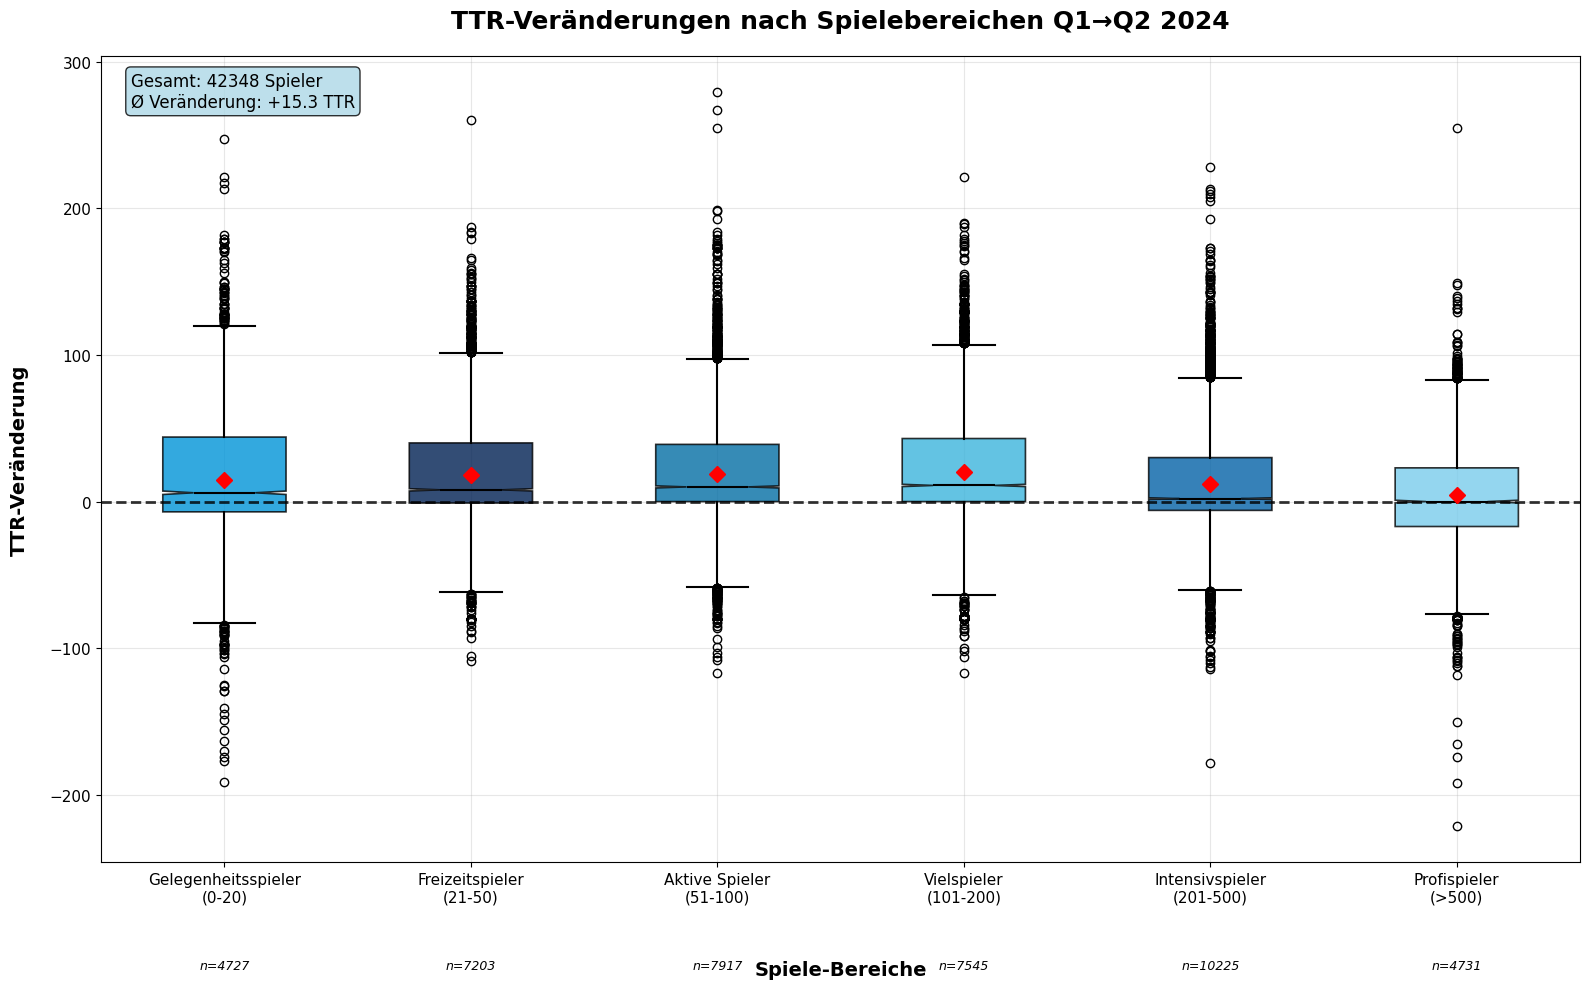

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1/ttr_spielebereiche_q2_24_q3_24.png


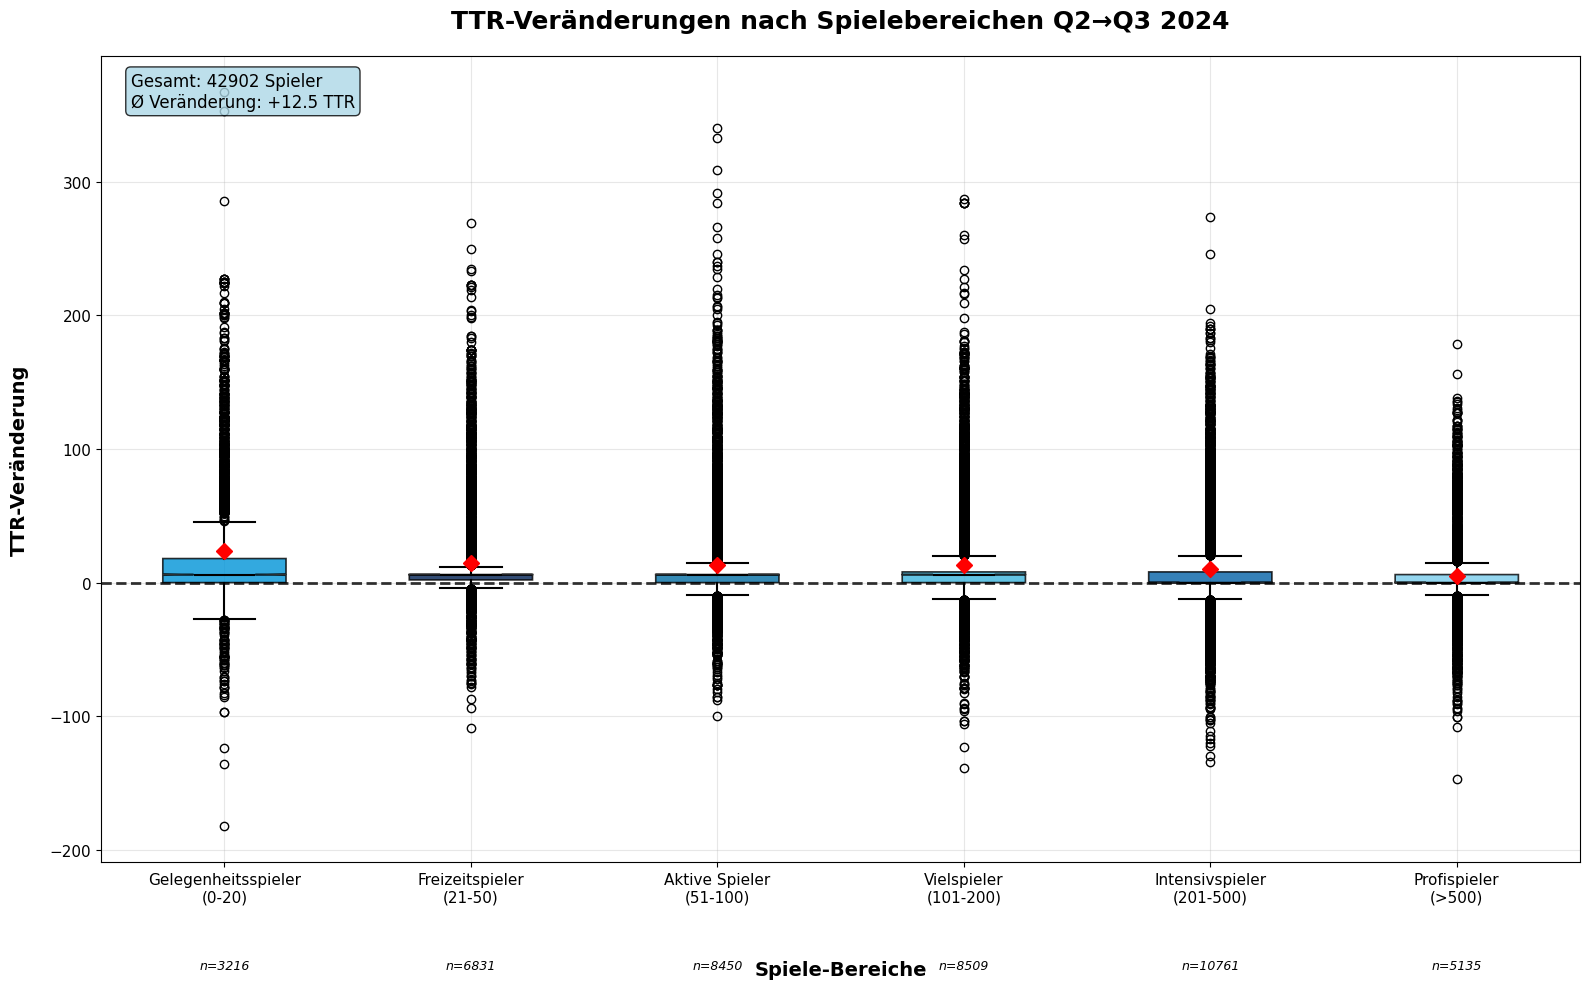

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1/ttr_spielebereiche_q3_24_q4_24.png


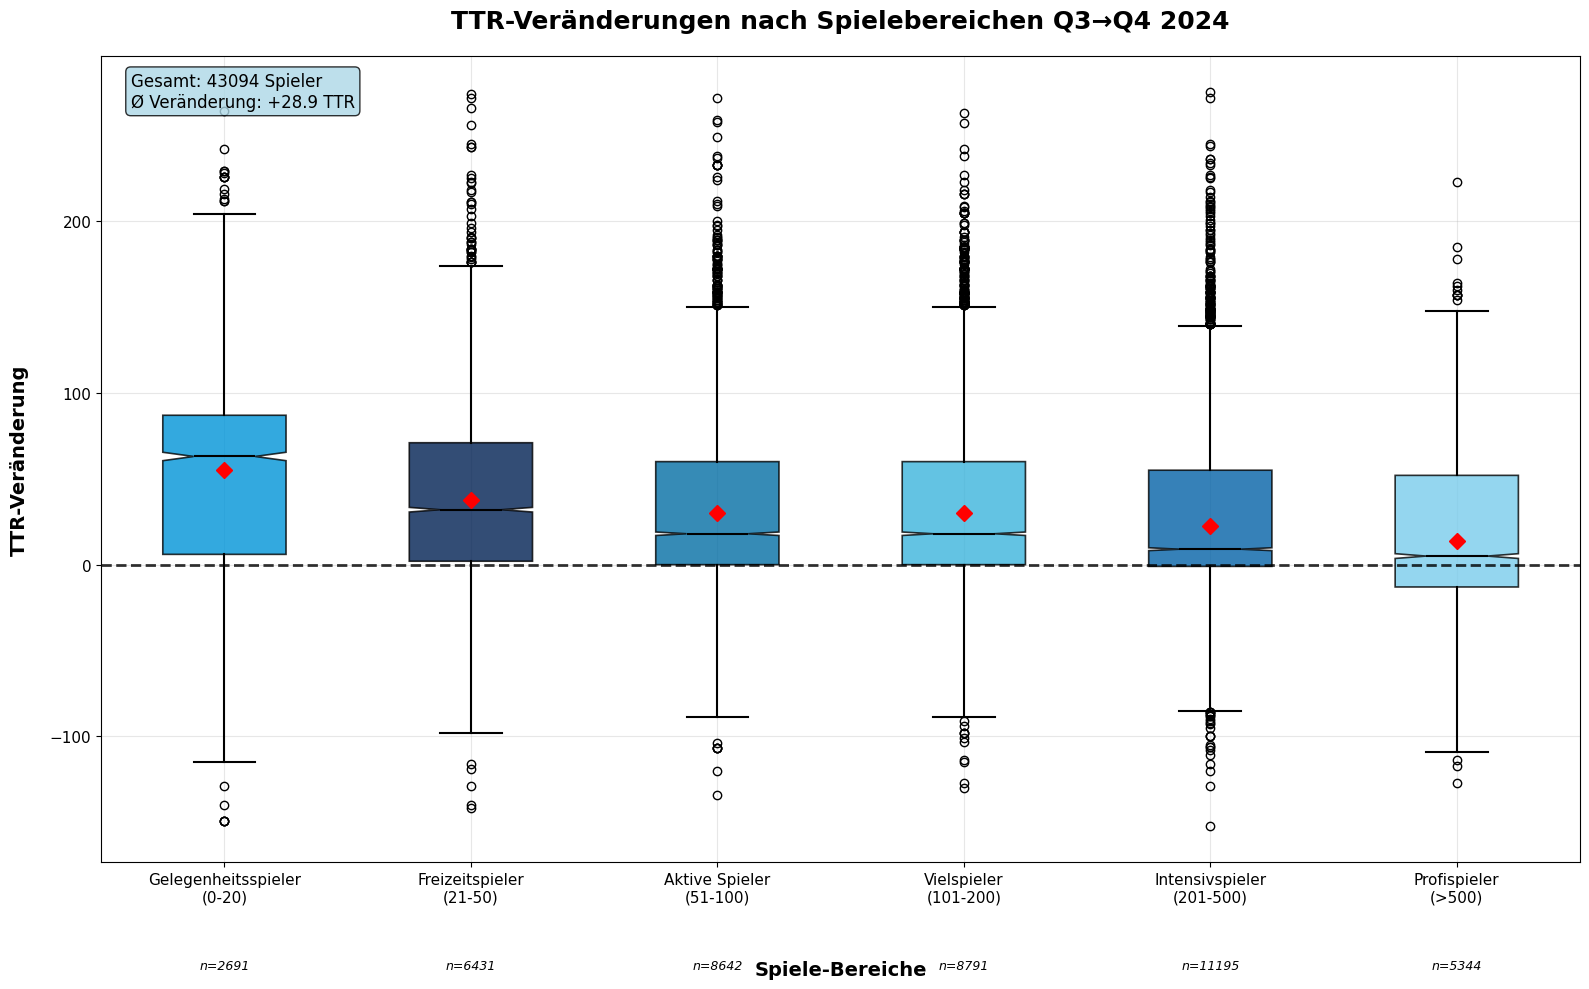

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1/ttr_spielebereiche_q4_24_q1_25.png


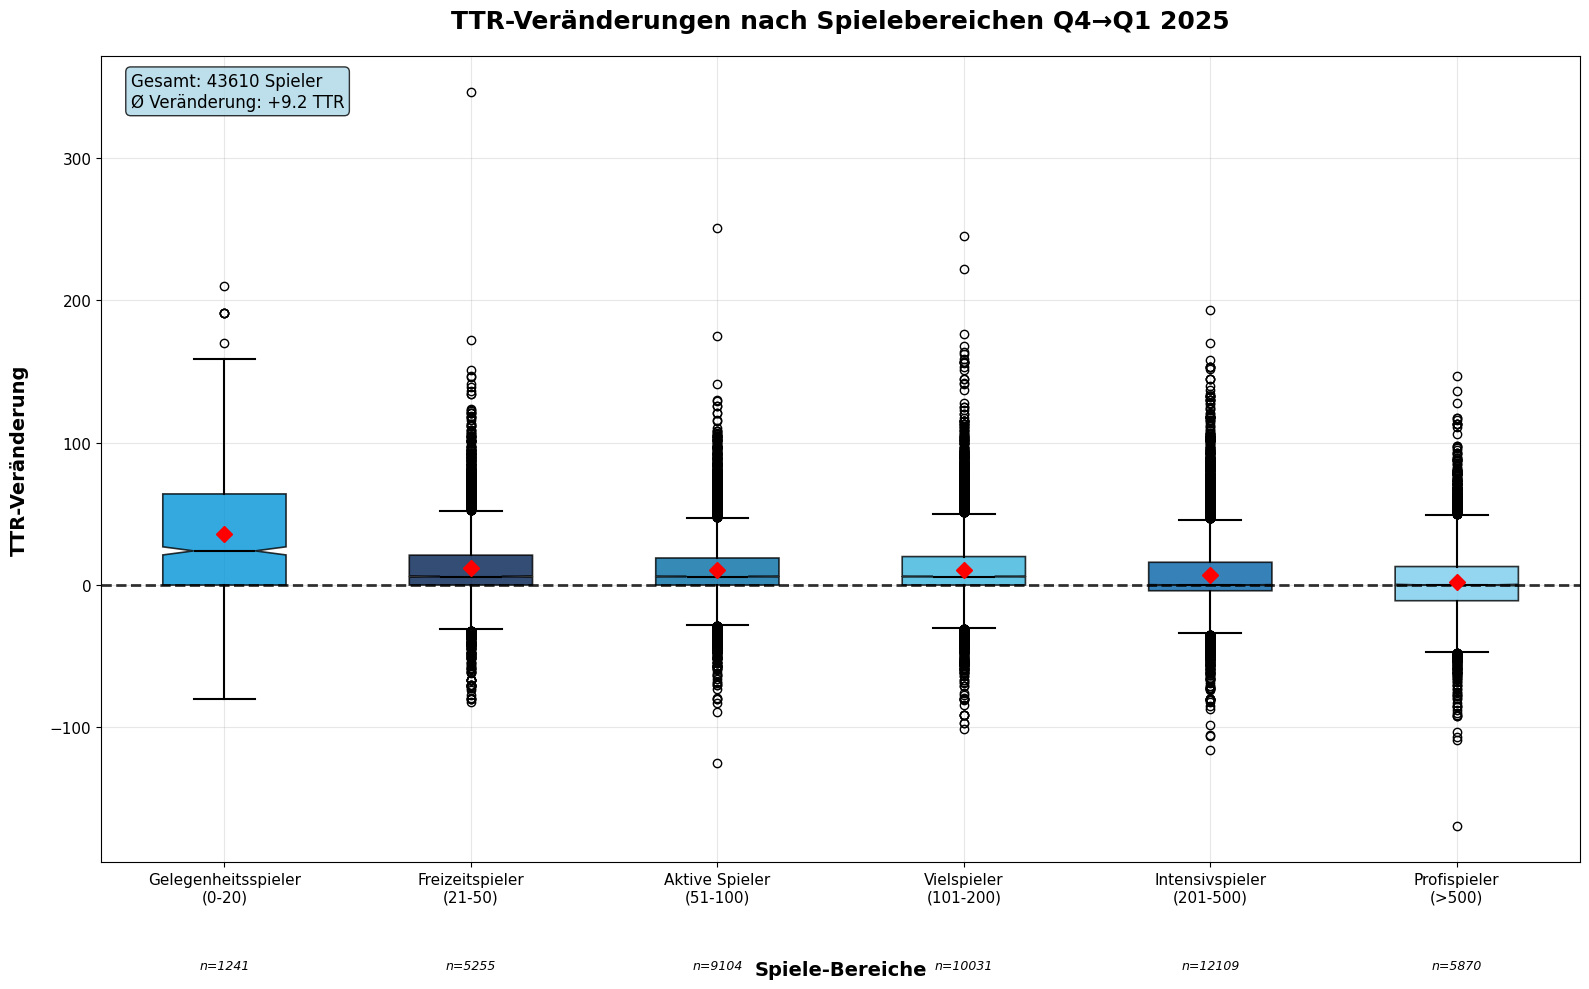

Unbekannter Zeitraum: Q1_24_Q1_25
Unbekannter Zeitraum: Q1_23_Q1_24
Balkendiagramm gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1/spieler_verteilung_spielebereiche_q1_2024.png


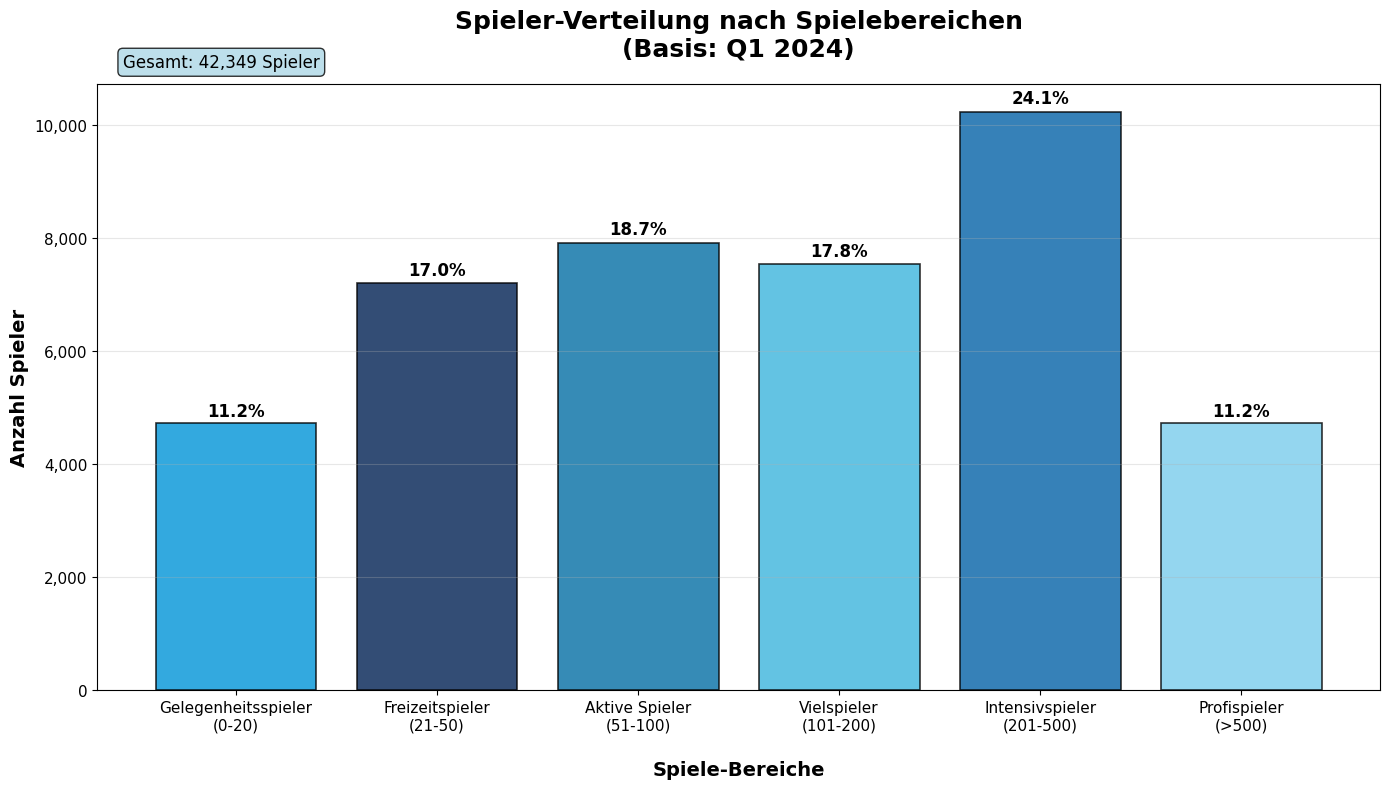

Alle Visualisierungen erstellt in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1


In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def create_ttr_spielebereiche_boxplot(data, period_key, save_folder="/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1"):
    """
    Erstellt Boxplot für TTR-Veränderungen kategorisiert nach Spielebereichen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    period_key: String der den Zeitraum angibt (z.B. 'Q1_24_Q2_24')
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    # Spielebereiche-Kategorien (in gewünschter Reihenfolge)
    category_order = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erweitere Farben für alle Kategorien
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Zeitraum-Definitionen mit TTR-Veränderungen
    periods = {
        'Q1_24_Q2_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q1→Q2 2024',
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'spiele_basis_col': 'Anzahl_Einzel_Q1_2024'
        },
        'Q2_24_Q3_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q2→Q3 2024',
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'spiele_basis_col': 'Anzahl_Einzel_Q2_2024'
        },
        'Q3_24_Q4_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q3→Q4 2024',
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'spiele_basis_col': 'Anzahl_Einzel_Q3_2024'
        },
        'Q4_24_Q1_25': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q4→Q1 2025',
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'spiele_basis_col': 'Anzahl_Einzel_Q4_2024'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    change_col = period_info['change_col']
    spiele_basis_col = period_info['spiele_basis_col']
    
    # Für Jahresvergleiche: Berechne TTR-Gesamtveränderung
    if period_key == 'Q1_24_Q1_25':
        # Berechne TTR-Differenz zwischen Q1 2024 und Q1 2025
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
            
    elif period_key == 'Q1_23_Q1_24':
        # Berechne TTR-Differenz zwischen Q1 2023 und Q1 2024
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    
    # Prüfe ob die benötigten Spalten existieren
    if change_col not in data.columns:
        print(f"Warnung: Spalte {change_col} nicht gefunden!")
        return
    if spiele_basis_col not in data.columns:
        print(f"Warnung: Spalte {spiele_basis_col} nicht gefunden!")
        return
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Erstelle Spielebereich-Spalte basierend auf der entsprechenden Quartals-Spieleanzahl
    data['spiele_kategorie'] = data[spiele_basis_col].apply(categorize_spiele)
    
    # Berechne echte Statistiken aus den Daten
    valid_data = data[change_col].dropna()
    total_players = len(valid_data)
    avg_change = valid_data.mean()
    
    plt.figure(figsize=(16, 10))
    
    # Filtere Daten nach Spielebereichen und sammle für Boxplot
    category_data = []
    box_labels = []
    sample_sizes = []
    
    for category in category_order:
        # Filtere nach Spielekategorie
        cat_data = data[data['spiele_kategorie'] == category]
        
        if len(cat_data) > 0:
            change_values = cat_data[change_col].dropna()
            if len(change_values) > 0:
                category_data.append(change_values)
                box_labels.append(category)
                sample_sizes.append(len(change_values))
    
    if not category_data:
        print(f"Keine Daten für {period_key} gefunden!")
        return
    
    # Erstelle Boxplot
    box_plot = plt.boxplot(category_data, 
                          labels=box_labels,
                          patch_artist=True,
                          notch=True,
                          showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='red', 
                                       markeredgecolor='red', markersize=8))
    
    # Färbe die Boxen
    for patch, category in zip(box_plot['boxes'], box_labels):
        patch.set_facecolor(color_dict[category])
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    # Styling der anderen Boxplot-Elemente
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(box_plot[element], color='black', linewidth=1.5)
    
    # Titel und Labels
    plt.title(period_info['title'], fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=40)
    
    # Statistik-Box
    stats_text = f"Gesamt: {total_players} Spieler\n"
    stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR"
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Achsen-Styling - X-Achse NICHT rotiert
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    
    # Füge Sample-Größen unter die Labels hinzu
    ax = plt.gca()
    for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
        ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
               f'n={n}', ha='center', va='top', fontsize=9, style='italic')
    
    plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Y-Achse erweitern um negative Werte sichtbar zu machen
    y_min, y_max = ax.get_ylim()
    if y_min >= -5:  # Falls Y-Achse bei 0 oder knapp darüber beginnt
        ax.set_ylim(bottom=min(-10, y_min - abs(y_max) * 0.1))
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, f"ttr_spielebereiche_{period_key.lower()}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Boxplot gespeichert: {save_path}")
    
    plt.show()


def create_spieler_verteilung_balkendiagramm(data, save_folder="visualisierungen"):
    """
    Erstellt Balkendiagramm für Spieler-Verteilung nach Spielebereichen (Q1 2024)
    
    Parameters:
    data: DataFrame mit Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Verwende Q1 2024 als Basis für die Kategorisierung
    if 'Anzahl_Einzel_Q1_2024' not in data.columns:
        print("Fehler: Spalte 'Anzahl_Einzel_Q1_2024' nicht gefunden!")
        return
    
    # Erstelle Spielekategorien
    data['spiele_kategorie'] = data['Anzahl_Einzel_Q1_2024'].apply(categorize_spiele)
    
    # Berechne die Verteilung
    kategorie_counts = data['spiele_kategorie'].value_counts()
    
    # Definiere die gewünschte Reihenfolge
    kategorie_reihenfolge = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erstelle DataFrame in der richtigen Reihenfolge
    spieler_data = []
    for kategorie in kategorie_reihenfolge:
        anzahl = kategorie_counts.get(kategorie, 0)
        spieler_data.append({
            'Spielebereich': kategorie,
            'Anzahl': anzahl
        })
    
    df = pd.DataFrame(spieler_data)
    
    # Berechne Prozentanteile
    total_players = df['Anzahl'].sum()
    df['Prozent'] = round((df['Anzahl'] / total_players) * 100, 1)
    
    plt.figure(figsize=(14, 8))
    
    # Erstelle Balkendiagramm
    bars = plt.bar(df['Spielebereich'], df['Anzahl'], 
                   color=colors[:len(df)], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Füge Prozentangaben auf die Balken hinzu
    for bar, prozent in zip(bars, df['Prozent']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{prozent}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Titel und Labels
    plt.title('Spieler-Verteilung nach Spielebereichen\n(Basis: Q1 2024)', 
              fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('Anzahl Spieler', fontsize=14, fontweight='bold')
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=20)
    
    # Gesamtanzahl in Statistik-Box
    stats_text = f"Gesamt: {total_players:,} Spieler"
    
    plt.text(0.02, 1.05, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Y-Achse formatieren (Tausendertrennzeichen)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    # Achsen-Styling
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, "spieler_verteilung_spielebereiche_q1_2024.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Balkendiagramm gespeichert: {save_path}")
    
    plt.show()


# Hauptfunktion zum Erstellen aller Visualisierungen
def create_all_ttr_spielebereiche_visualisierungen(data, save_folder="visualisierungen"):
    """
    Erstellt alle TTR-Spielebereiche Visualisierungen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    print(f"Erstelle TTR-Spielebereiche Visualisierungen in Ordner: {save_folder}")
    
    # Alle Zeiträume
    periods = ['Q1_24_Q2_24', 'Q2_24_Q3_24', 'Q3_24_Q4_24', 'Q4_24_Q1_25', 'Q1_24_Q1_25', 'Q1_23_Q1_24']
    
    # Erstelle alle Boxplots
    for period in periods:
        create_ttr_spielebereiche_boxplot(data, period, save_folder)
    
    # Erstelle Balkendiagramm für Spieler-Verteilung
    create_spieler_verteilung_balkendiagramm(data, save_folder)
    
    print(f"Alle Visualisierungen erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_top_positiv  # <-- PFAD ZU DEINER DATEI
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top1"  # <-- HIER DEINEN PFAD EINTRAGEN   

    print("- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.")
    print(f"\nErstelle Visualisierungen in: {save_folder}")
    
    # Erstelle alle Visualisierungen
    create_all_ttr_spielebereiche_visualisierungen(data, save_folder)

## Kombinierte Darstellung - Top5

- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.

Erstelle Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5
Erstelle TTR-Spielebereiche Visualisierungen in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5
Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5/ttr_spielebereiche_q1_24_q2_24.png


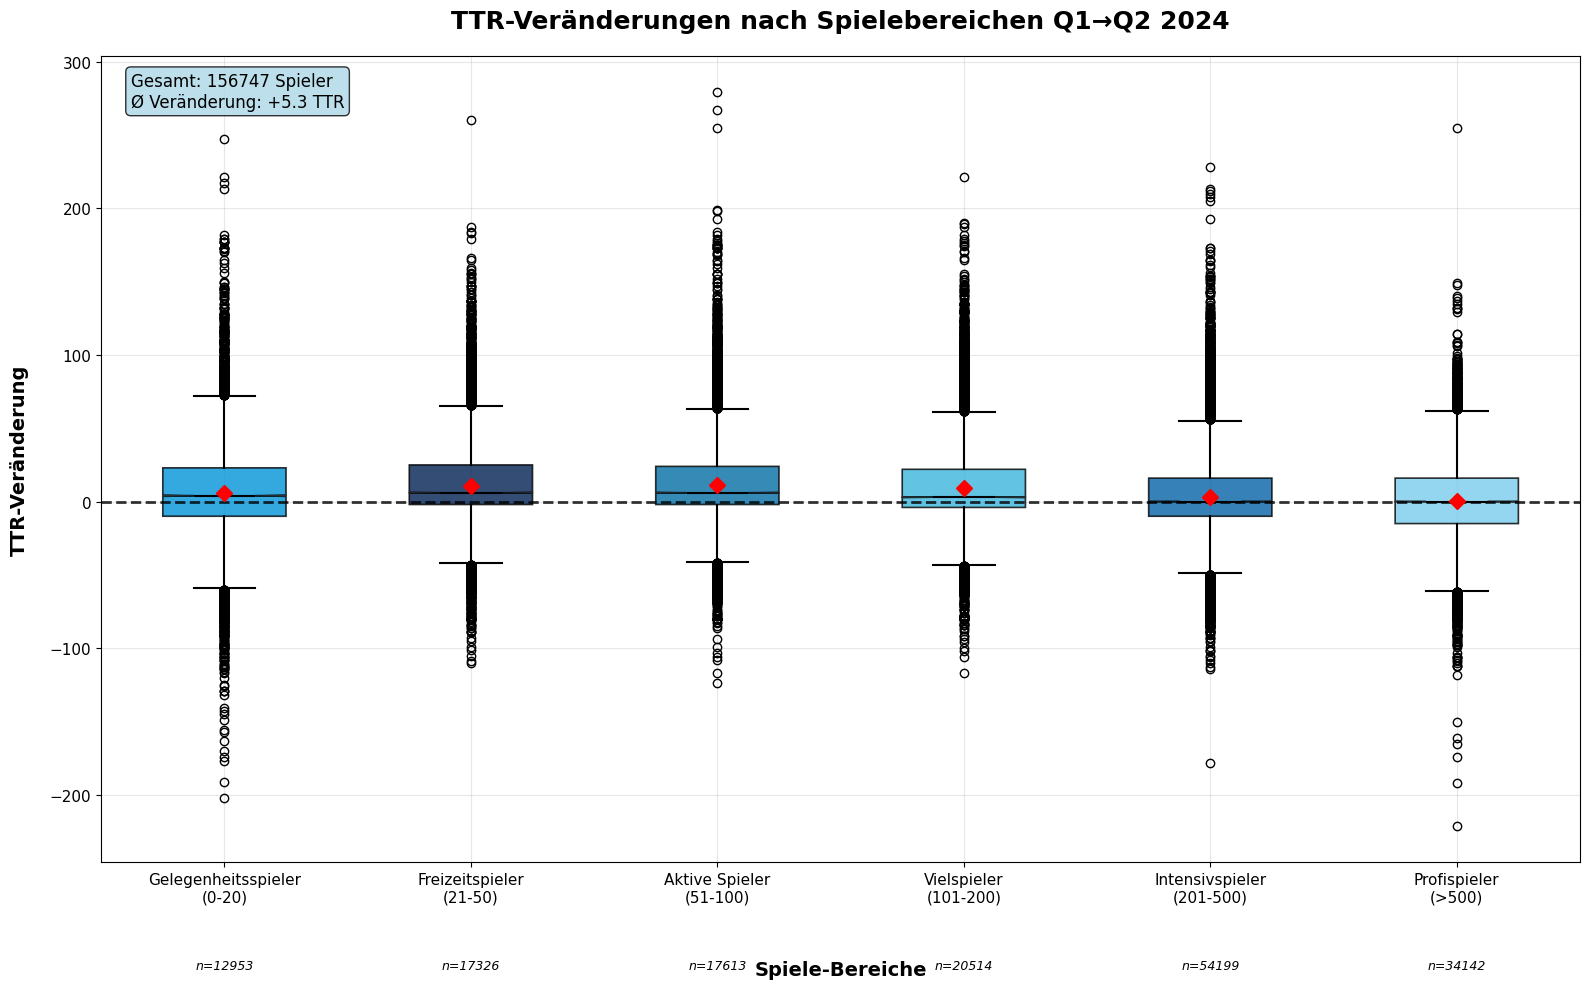

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5/ttr_spielebereiche_q2_24_q3_24.png


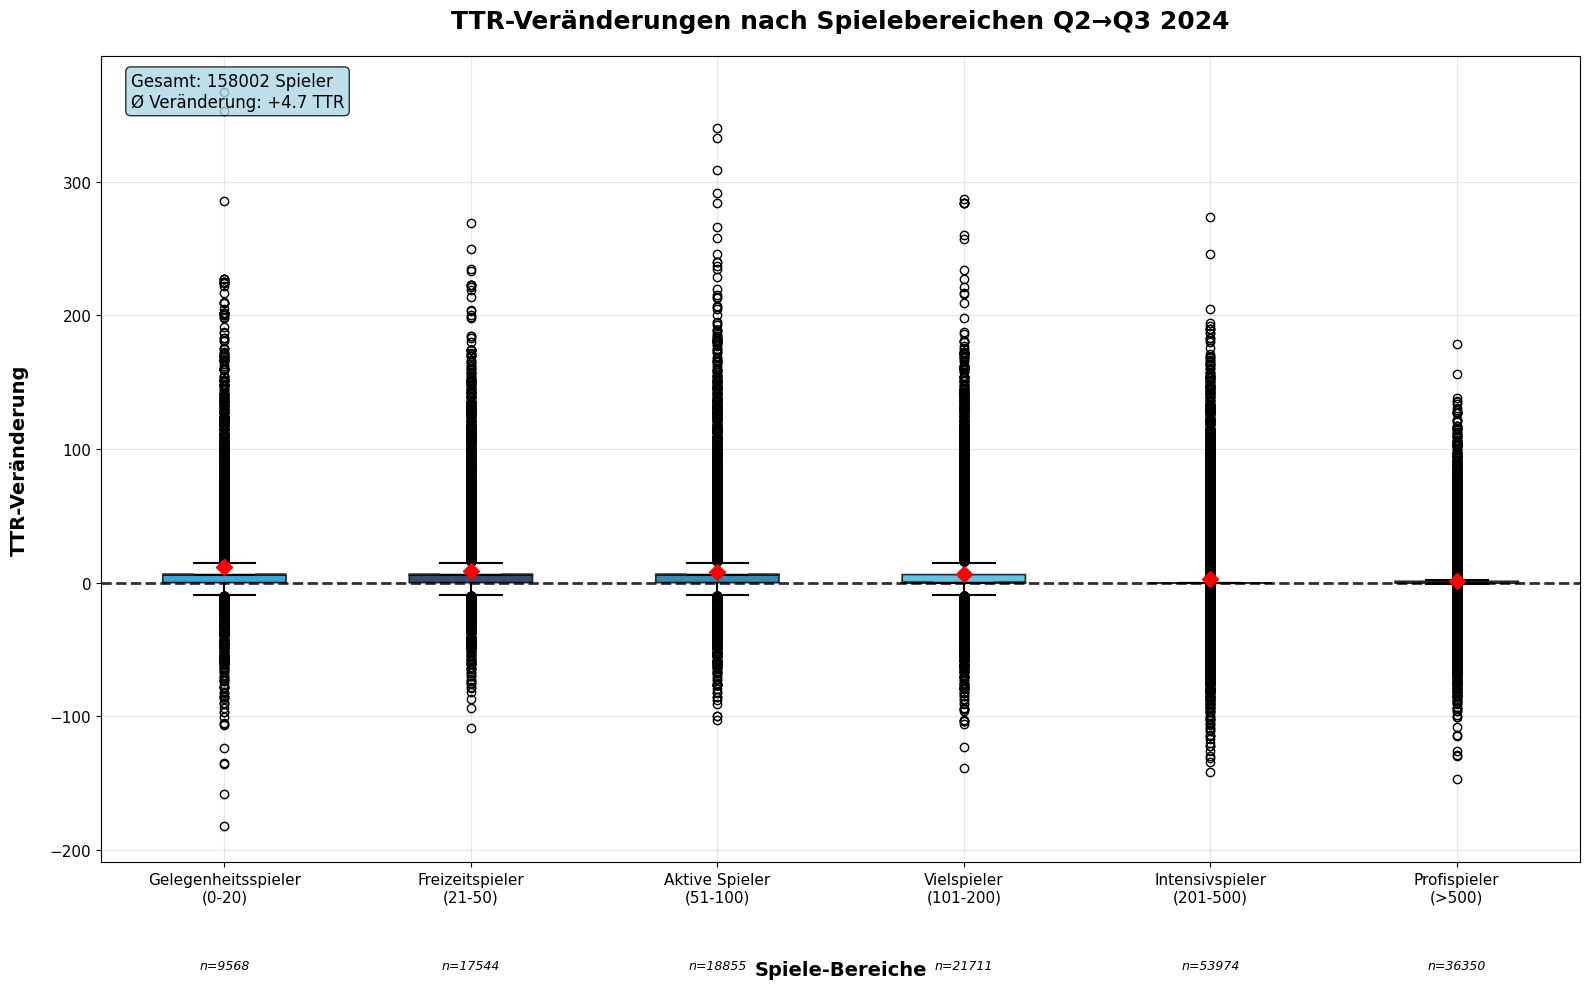

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5/ttr_spielebereiche_q3_24_q4_24.png


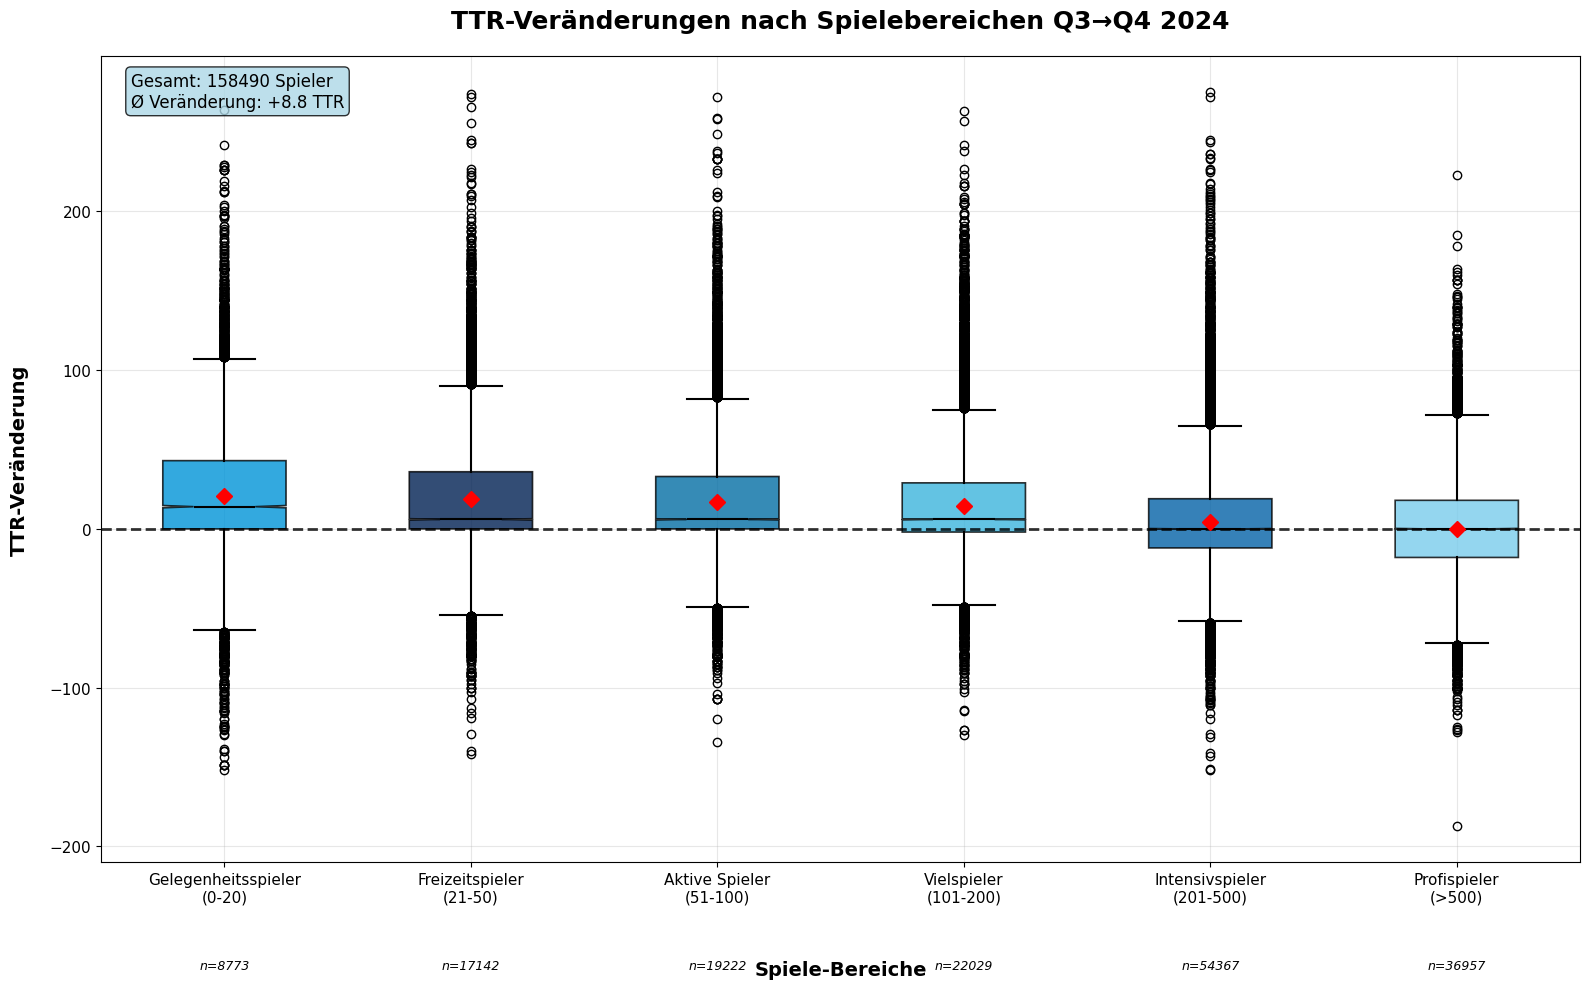

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5/ttr_spielebereiche_q4_24_q1_25.png


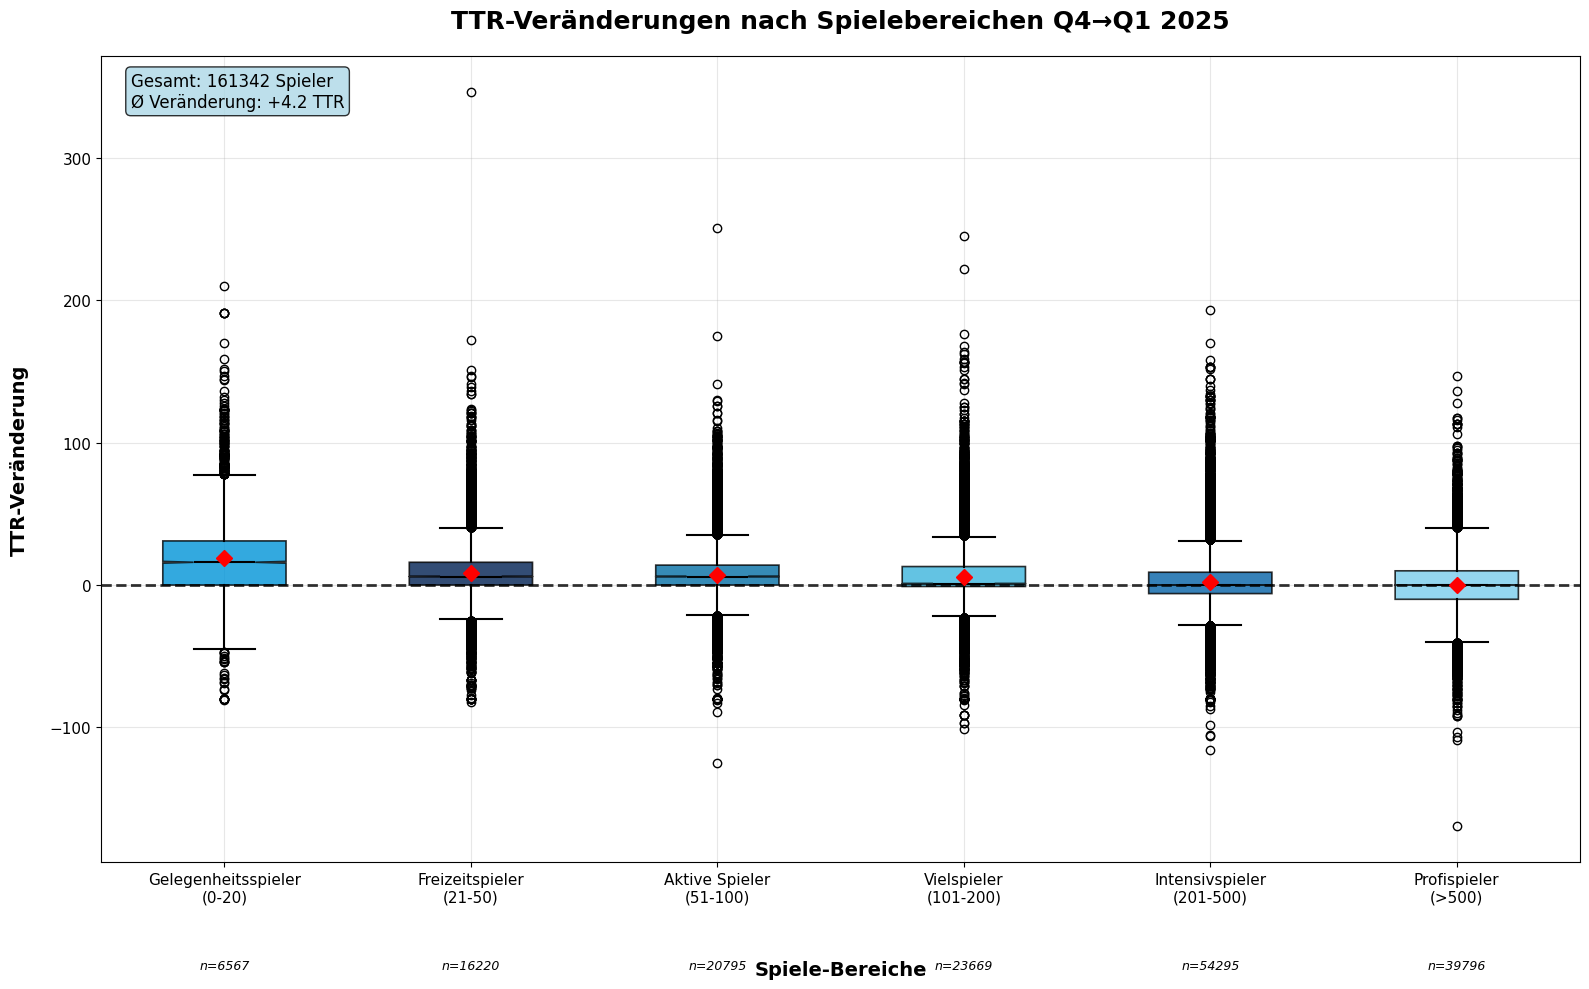

Unbekannter Zeitraum: Q1_24_Q1_25
Unbekannter Zeitraum: Q1_23_Q1_24
Balkendiagramm gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5/spieler_verteilung_spielebereiche_q1_2024.png


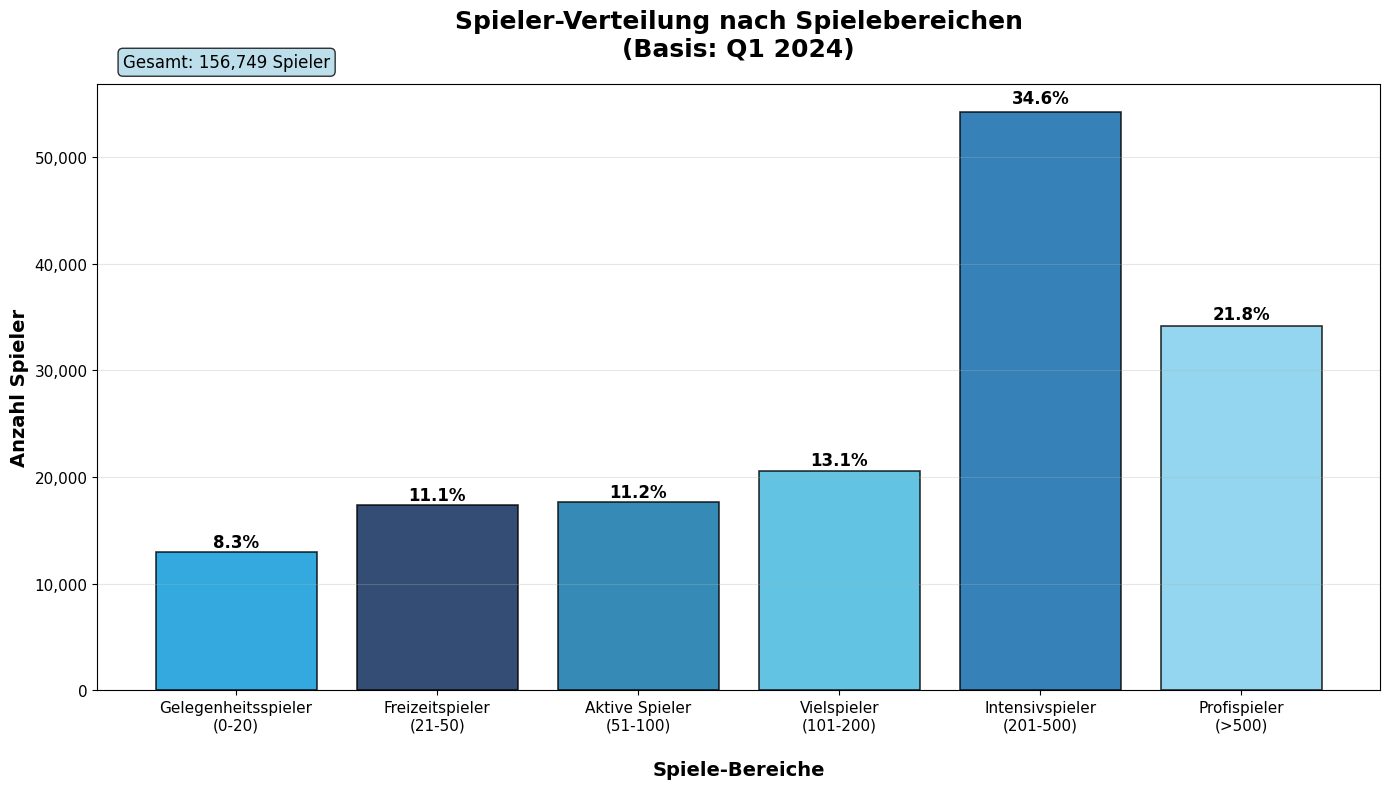

Alle Visualisierungen erstellt in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5


In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def create_ttr_spielebereiche_boxplot(data, period_key, save_folder="/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5"):
    """
    Erstellt Boxplot für TTR-Veränderungen kategorisiert nach Spielebereichen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    period_key: String der den Zeitraum angibt (z.B. 'Q1_24_Q2_24')
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    # Spielebereiche-Kategorien (in gewünschter Reihenfolge)
    category_order = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erweitere Farben für alle Kategorien
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Zeitraum-Definitionen mit TTR-Veränderungen
    periods = {
        'Q1_24_Q2_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q1→Q2 2024',
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'spiele_basis_col': 'Anzahl_Einzel_Q1_2024'
        },
        'Q2_24_Q3_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q2→Q3 2024',
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'spiele_basis_col': 'Anzahl_Einzel_Q2_2024'
        },
        'Q3_24_Q4_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q3→Q4 2024',
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'spiele_basis_col': 'Anzahl_Einzel_Q3_2024'
        },
        'Q4_24_Q1_25': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q4→Q1 2025',
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'spiele_basis_col': 'Anzahl_Einzel_Q4_2024'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    change_col = period_info['change_col']
    spiele_basis_col = period_info['spiele_basis_col']
    
    # Für Jahresvergleiche: Berechne TTR-Gesamtveränderung
    if period_key == 'Q1_24_Q1_25':
        # Berechne TTR-Differenz zwischen Q1 2024 und Q1 2025
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
            
    elif period_key == 'Q1_23_Q1_24':
        # Berechne TTR-Differenz zwischen Q1 2023 und Q1 2024
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    
    # Prüfe ob die benötigten Spalten existieren
    if change_col not in data.columns:
        print(f"Warnung: Spalte {change_col} nicht gefunden!")
        return
    if spiele_basis_col not in data.columns:
        print(f"Warnung: Spalte {spiele_basis_col} nicht gefunden!")
        return
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Erstelle Spielebereich-Spalte basierend auf der entsprechenden Quartals-Spieleanzahl
    data['spiele_kategorie'] = data[spiele_basis_col].apply(categorize_spiele)
    
    # Berechne echte Statistiken aus den Daten
    valid_data = data[change_col].dropna()
    total_players = len(valid_data)
    avg_change = valid_data.mean()
    
    plt.figure(figsize=(16, 10))
    
    # Filtere Daten nach Spielebereichen und sammle für Boxplot
    category_data = []
    box_labels = []
    sample_sizes = []
    
    for category in category_order:
        # Filtere nach Spielekategorie
        cat_data = data[data['spiele_kategorie'] == category]
        
        if len(cat_data) > 0:
            change_values = cat_data[change_col].dropna()
            if len(change_values) > 0:
                category_data.append(change_values)
                box_labels.append(category)
                sample_sizes.append(len(change_values))
    
    if not category_data:
        print(f"Keine Daten für {period_key} gefunden!")
        return
    
    # Erstelle Boxplot
    box_plot = plt.boxplot(category_data, 
                          labels=box_labels,
                          patch_artist=True,
                          notch=True,
                          showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='red', 
                                       markeredgecolor='red', markersize=8))
    
    # Färbe die Boxen
    for patch, category in zip(box_plot['boxes'], box_labels):
        patch.set_facecolor(color_dict[category])
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    # Styling der anderen Boxplot-Elemente
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(box_plot[element], color='black', linewidth=1.5)
    
    # Titel und Labels
    plt.title(period_info['title'], fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=40)
    
    # Statistik-Box
    stats_text = f"Gesamt: {total_players} Spieler\n"
    stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR"
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Achsen-Styling - X-Achse NICHT rotiert
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    
    # Füge Sample-Größen unter die Labels hinzu
    ax = plt.gca()
    for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
        ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
               f'n={n}', ha='center', va='top', fontsize=9, style='italic')
    
    plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Y-Achse erweitern um negative Werte sichtbar zu machen
    y_min, y_max = ax.get_ylim()
    if y_min >= -5:  # Falls Y-Achse bei 0 oder knapp darüber beginnt
        ax.set_ylim(bottom=min(-10, y_min - abs(y_max) * 0.1))
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, f"ttr_spielebereiche_{period_key.lower()}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Boxplot gespeichert: {save_path}")
    
    plt.show()


def create_spieler_verteilung_balkendiagramm(data, save_folder="visualisierungen"):
    """
    Erstellt Balkendiagramm für Spieler-Verteilung nach Spielebereichen (Q1 2024)
    
    Parameters:
    data: DataFrame mit Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Verwende Q1 2024 als Basis für die Kategorisierung
    if 'Anzahl_Einzel_Q1_2024' not in data.columns:
        print("Fehler: Spalte 'Anzahl_Einzel_Q1_2024' nicht gefunden!")
        return
    
    # Erstelle Spielekategorien
    data['spiele_kategorie'] = data['Anzahl_Einzel_Q1_2024'].apply(categorize_spiele)
    
    # Berechne die Verteilung
    kategorie_counts = data['spiele_kategorie'].value_counts()
    
    # Definiere die gewünschte Reihenfolge
    kategorie_reihenfolge = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erstelle DataFrame in der richtigen Reihenfolge
    spieler_data = []
    for kategorie in kategorie_reihenfolge:
        anzahl = kategorie_counts.get(kategorie, 0)
        spieler_data.append({
            'Spielebereich': kategorie,
            'Anzahl': anzahl
        })
    
    df = pd.DataFrame(spieler_data)
    
    # Berechne Prozentanteile
    total_players = df['Anzahl'].sum()
    df['Prozent'] = round((df['Anzahl'] / total_players) * 100, 1)
    
    plt.figure(figsize=(14, 8))
    
    # Erstelle Balkendiagramm
    bars = plt.bar(df['Spielebereich'], df['Anzahl'], 
                   color=colors[:len(df)], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Füge Prozentangaben auf die Balken hinzu
    for bar, prozent in zip(bars, df['Prozent']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{prozent}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Titel und Labels
    plt.title('Spieler-Verteilung nach Spielebereichen\n(Basis: Q1 2024)', 
              fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('Anzahl Spieler', fontsize=14, fontweight='bold')
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=20)
    
    # Gesamtanzahl in Statistik-Box
    stats_text = f"Gesamt: {total_players:,} Spieler"
    
    plt.text(0.02, 1.05, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Y-Achse formatieren (Tausendertrennzeichen)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    # Achsen-Styling
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, "spieler_verteilung_spielebereiche_q1_2024.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Balkendiagramm gespeichert: {save_path}")
    
    plt.show()


# Hauptfunktion zum Erstellen aller Visualisierungen
def create_all_ttr_spielebereiche_visualisierungen(data, save_folder="visualisierungen"):
    """
    Erstellt alle TTR-Spielebereiche Visualisierungen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    print(f"Erstelle TTR-Spielebereiche Visualisierungen in Ordner: {save_folder}")
    
    # Alle Zeiträume
    periods = ['Q1_24_Q2_24', 'Q2_24_Q3_24', 'Q3_24_Q4_24', 'Q4_24_Q1_25', 'Q1_24_Q1_25', 'Q1_23_Q1_24']
    
    # Erstelle alle Boxplots
    for period in periods:
        create_ttr_spielebereiche_boxplot(data, period, save_folder)
    
    # Erstelle Balkendiagramm für Spieler-Verteilung
    create_spieler_verteilung_balkendiagramm(data, save_folder)
    
    print(f"Alle Visualisierungen erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_top_5_positiv  # <-- PFAD ZU DEINER DATEI
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl_Top5"  # <-- HIER DEINEN PFAD EINTRAGEN   

    print("- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.")
    print(f"\nErstelle Visualisierungen in: {save_folder}")
    
    # Erstelle alle Visualisierungen
    create_all_ttr_spielebereiche_visualisierungen(data, save_folder)

## Kombinierte Darstellung - Ohne Ausländer

- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.

Erstelle Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl
Erstelle TTR-Spielebereiche Visualisierungen in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl
Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl/ttr_spielebereiche_q1_24_q2_24.png


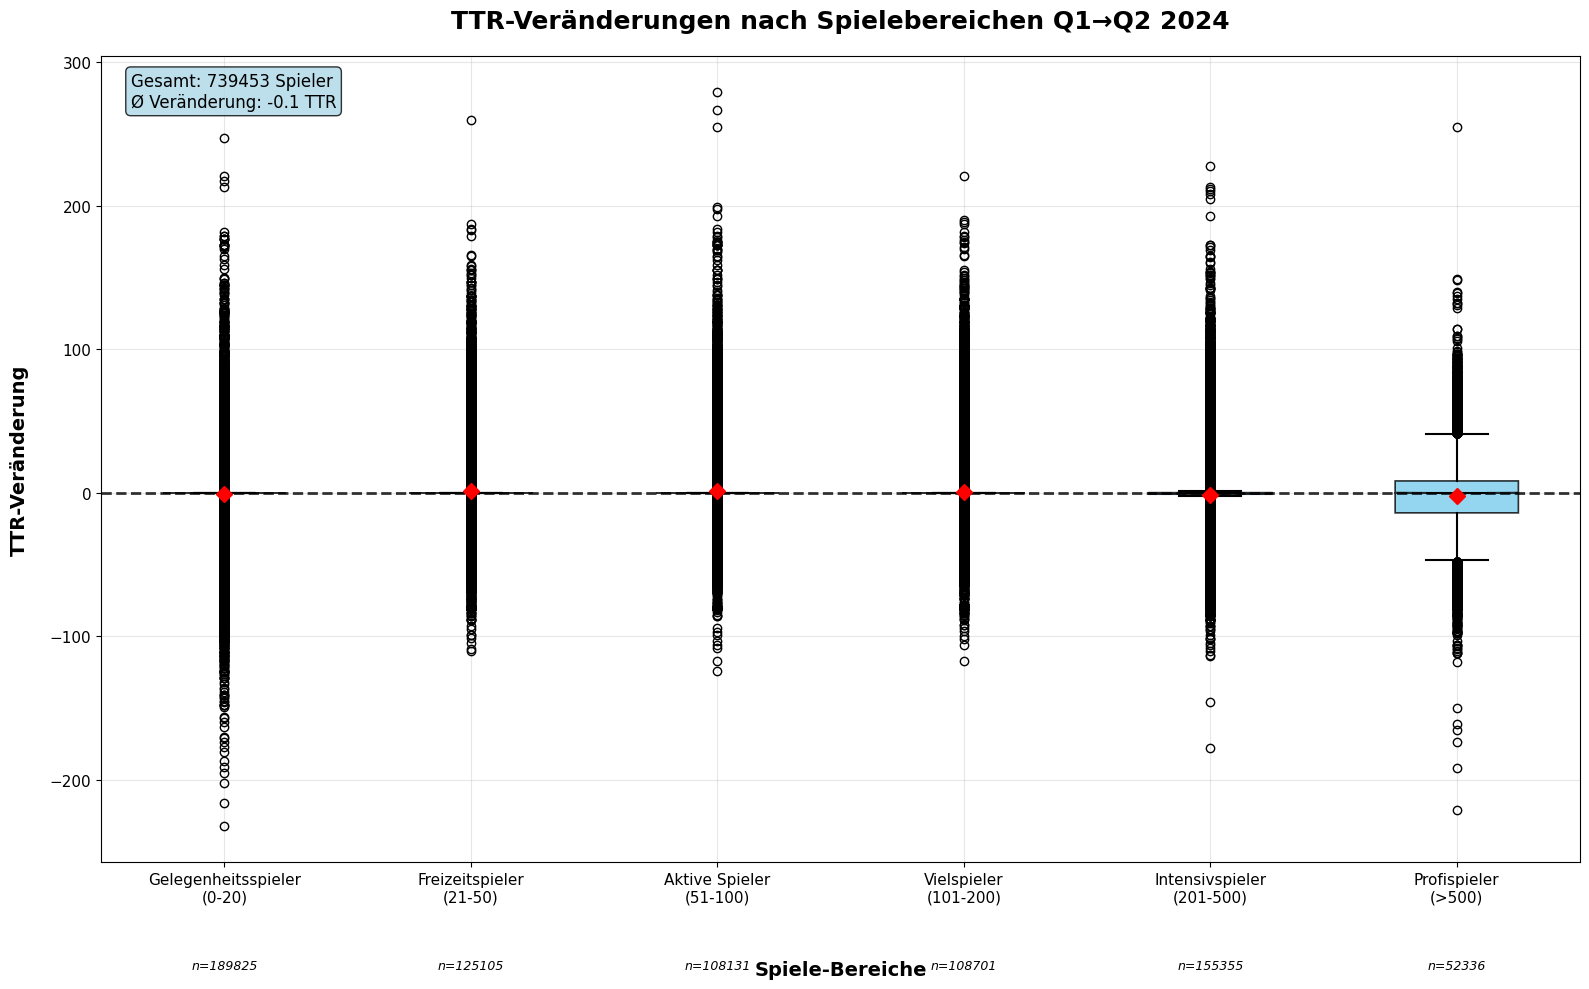

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl/ttr_spielebereiche_q2_24_q3_24.png


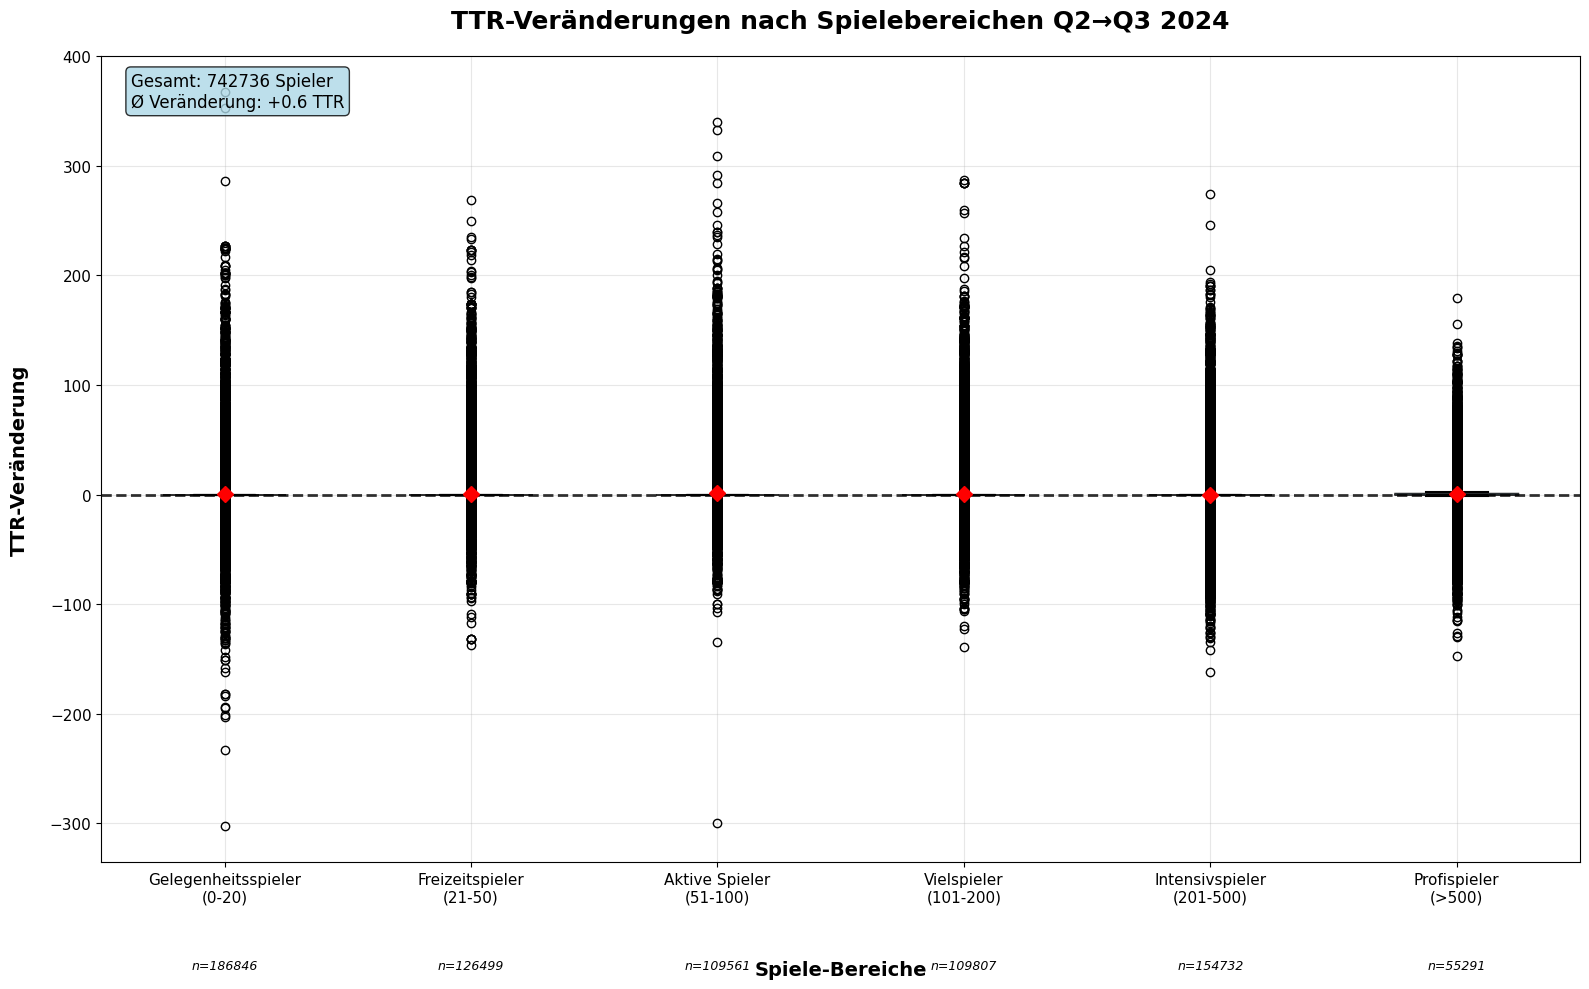

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl/ttr_spielebereiche_q3_24_q4_24.png


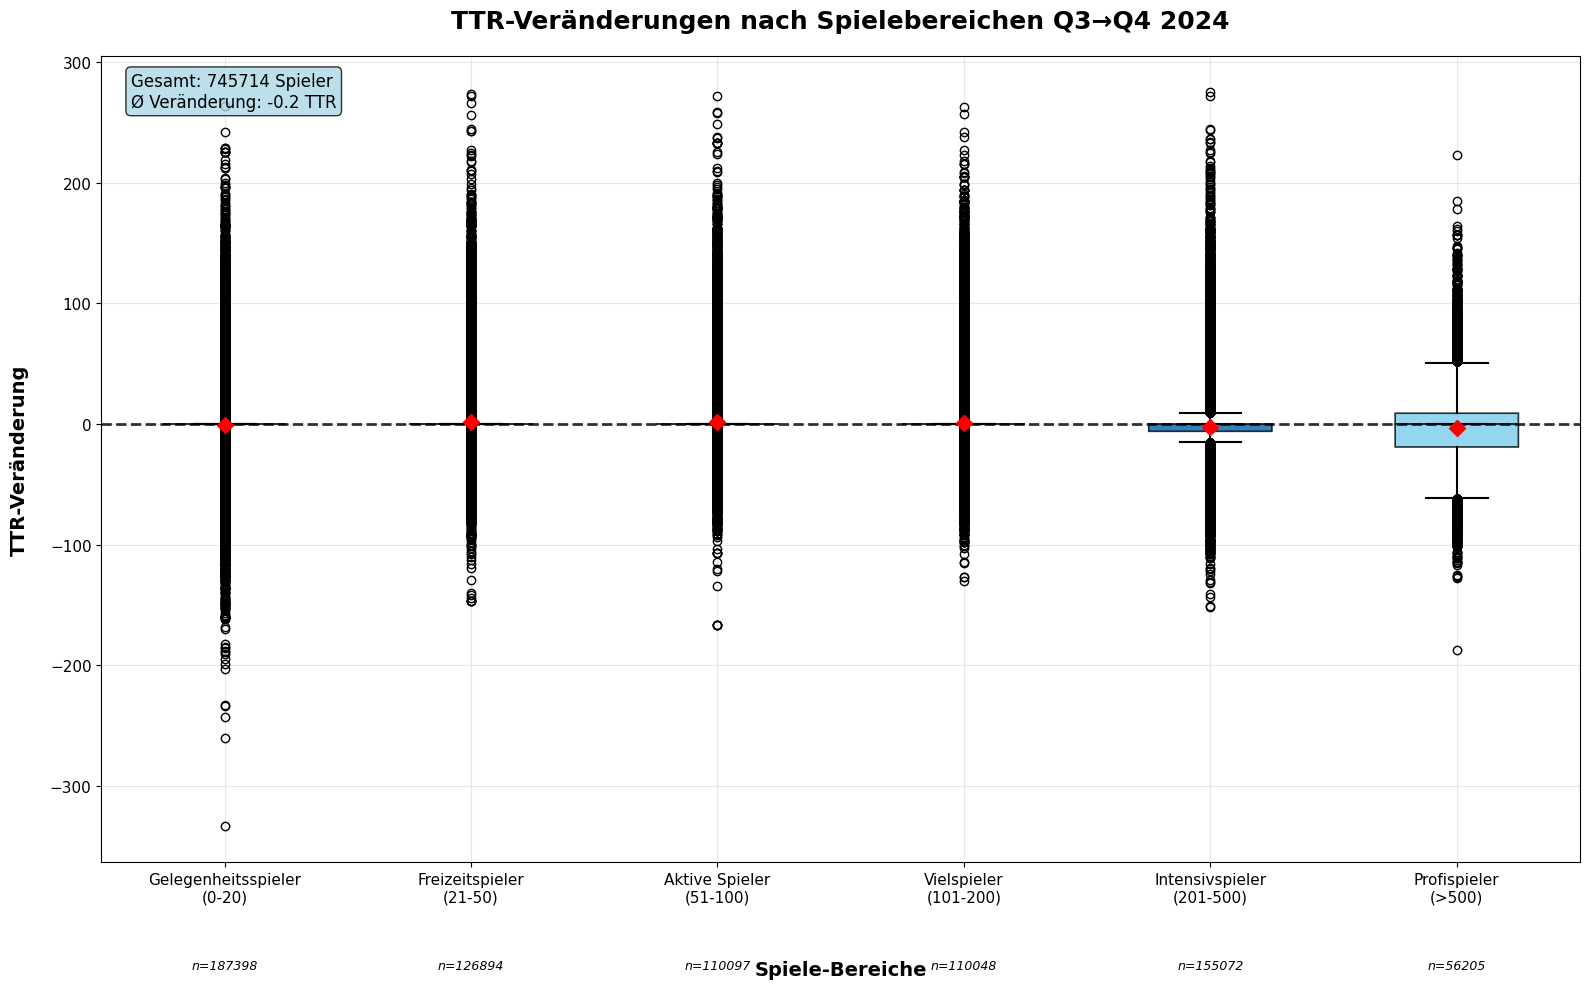

Boxplot gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl/ttr_spielebereiche_q4_24_q1_25.png


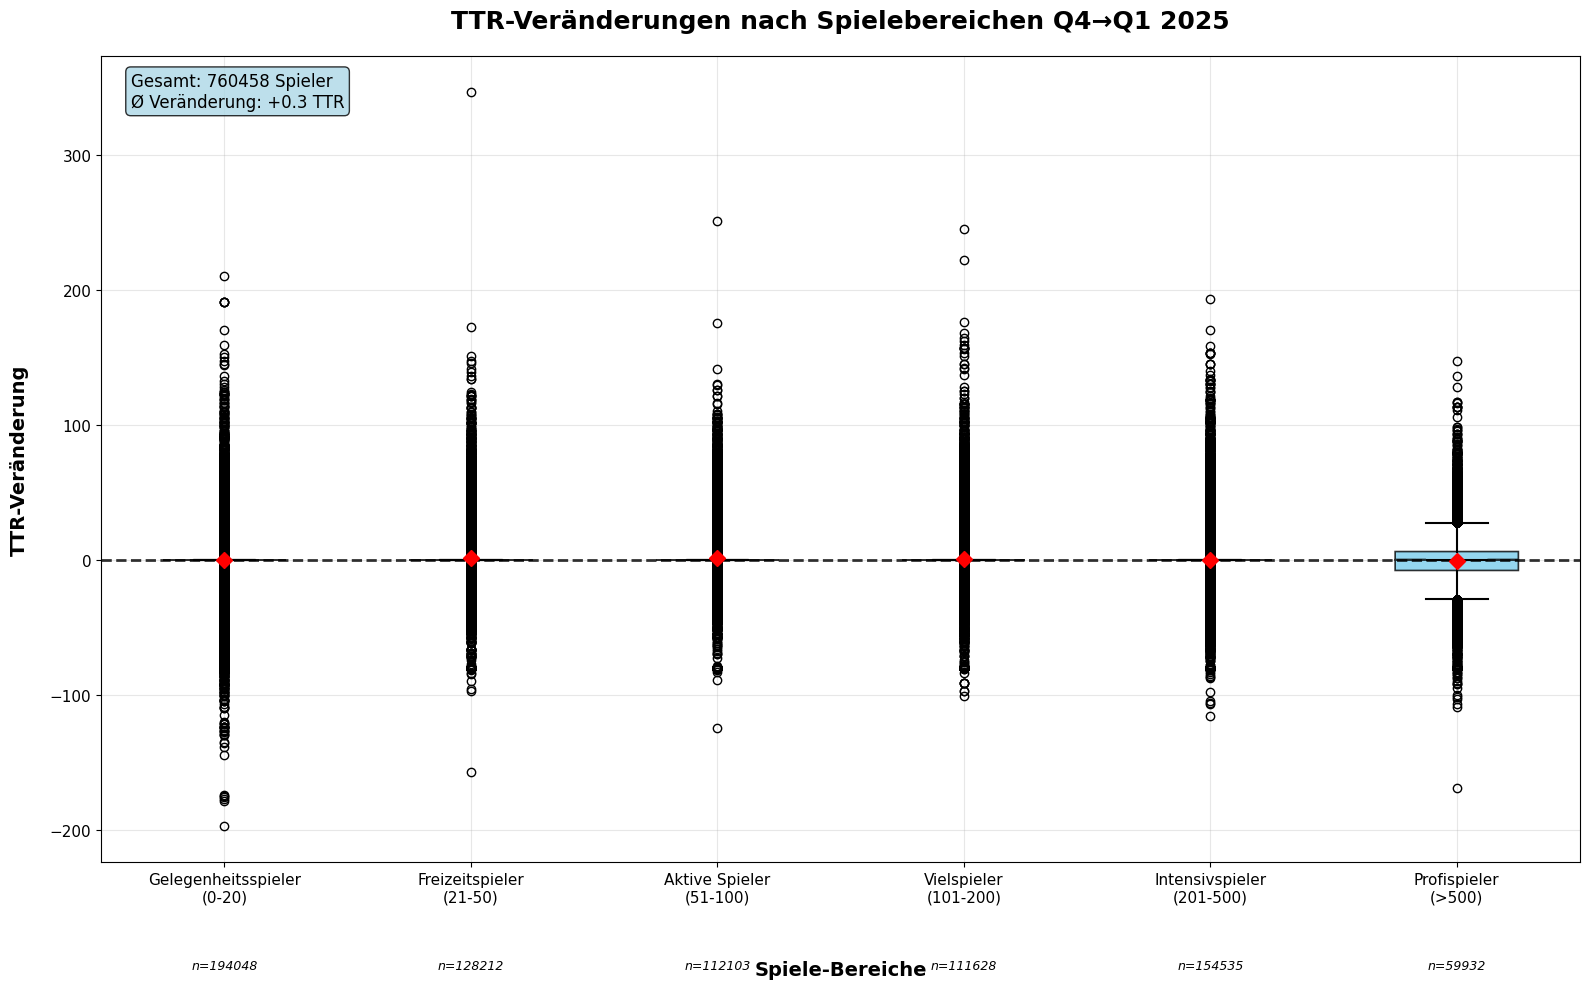

Unbekannter Zeitraum: Q1_24_Q1_25
Unbekannter Zeitraum: Q1_23_Q1_24
Balkendiagramm gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl/spieler_verteilung_spielebereiche_q1_2024.png


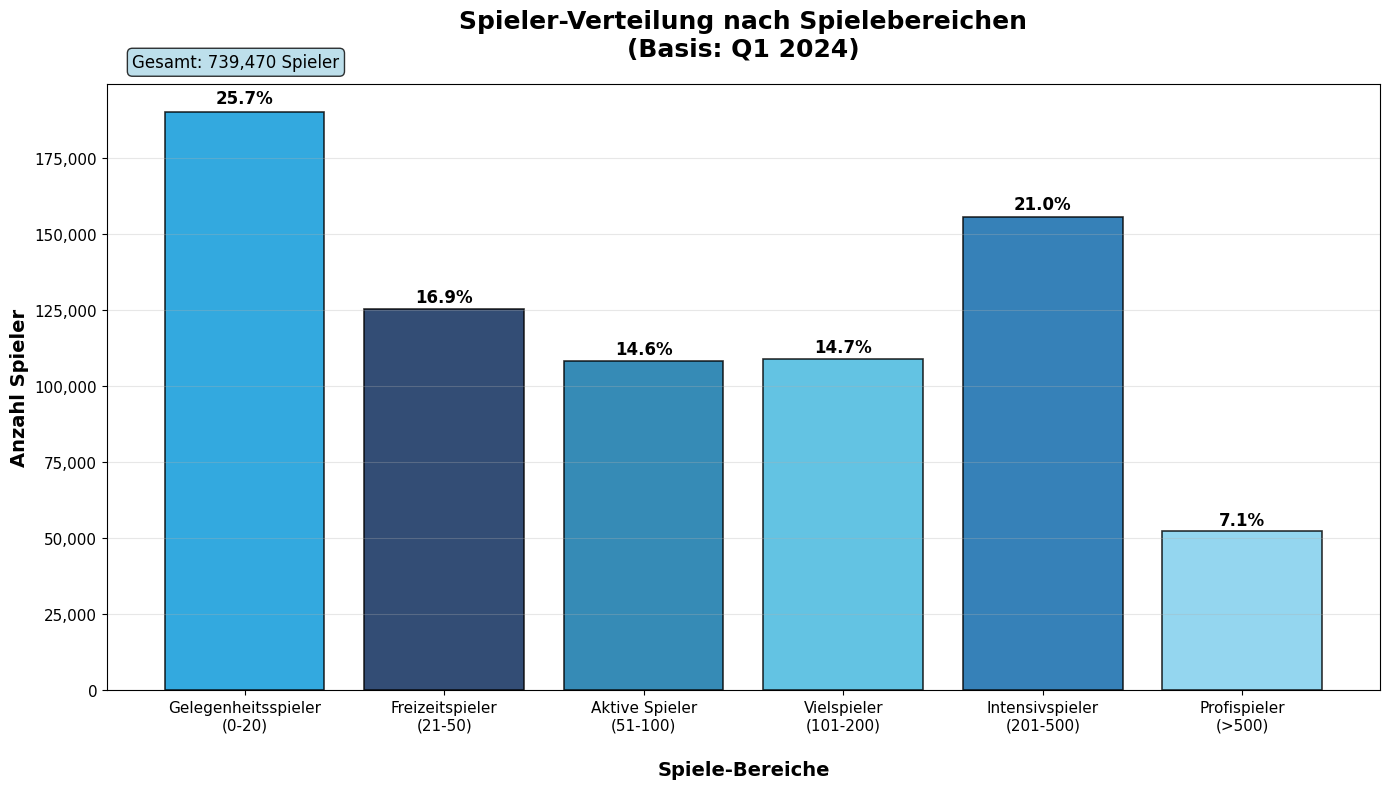

Alle Visualisierungen erstellt in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl


In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

def create_ttr_spielebereiche_boxplot(data, period_key, save_folder="/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl"):
    """
    Erstellt Boxplot für TTR-Veränderungen kategorisiert nach Spielebereichen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    period_key: String der den Zeitraum angibt (z.B. 'Q1_24_Q2_24')
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    # Spielebereiche-Kategorien (in gewünschter Reihenfolge)
    category_order = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erweitere Farben für alle Kategorien
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Zeitraum-Definitionen mit TTR-Veränderungen
    periods = {
        'Q1_24_Q2_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q1→Q2 2024',
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'spiele_basis_col': 'Anzahl_Einzel_Q1_2024'
        },
        'Q2_24_Q3_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q2→Q3 2024',
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'spiele_basis_col': 'Anzahl_Einzel_Q2_2024'
        },
        'Q3_24_Q4_24': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q3→Q4 2024',
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'spiele_basis_col': 'Anzahl_Einzel_Q3_2024'
        },
        'Q4_24_Q1_25': {
            'title': 'TTR-Veränderungen nach Spielebereichen Q4→Q1 2025',
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'spiele_basis_col': 'Anzahl_Einzel_Q4_2024'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    change_col = period_info['change_col']
    spiele_basis_col = period_info['spiele_basis_col']
    
    # Für Jahresvergleiche: Berechne TTR-Gesamtveränderung
    if period_key == 'Q1_24_Q1_25':
        # Berechne TTR-Differenz zwischen Q1 2024 und Q1 2025
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
            
    elif period_key == 'Q1_23_Q1_24':
        # Berechne TTR-Differenz zwischen Q1 2023 und Q1 2024
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    
    # Prüfe ob die benötigten Spalten existieren
    if change_col not in data.columns:
        print(f"Warnung: Spalte {change_col} nicht gefunden!")
        return
    if spiele_basis_col not in data.columns:
        print(f"Warnung: Spalte {spiele_basis_col} nicht gefunden!")
        return
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Erstelle Spielebereich-Spalte basierend auf der entsprechenden Quartals-Spieleanzahl
    data['spiele_kategorie'] = data[spiele_basis_col].apply(categorize_spiele)
    
    # Berechne echte Statistiken aus den Daten
    valid_data = data[change_col].dropna()
    total_players = len(valid_data)
    avg_change = valid_data.mean()
    
    plt.figure(figsize=(16, 10))
    
    # Filtere Daten nach Spielebereichen und sammle für Boxplot
    category_data = []
    box_labels = []
    sample_sizes = []
    
    for category in category_order:
        # Filtere nach Spielekategorie
        cat_data = data[data['spiele_kategorie'] == category]
        
        if len(cat_data) > 0:
            change_values = cat_data[change_col].dropna()
            if len(change_values) > 0:
                category_data.append(change_values)
                box_labels.append(category)
                sample_sizes.append(len(change_values))
    
    if not category_data:
        print(f"Keine Daten für {period_key} gefunden!")
        return
    
    # Erstelle Boxplot
    box_plot = plt.boxplot(category_data, 
                          labels=box_labels,
                          patch_artist=True,
                          notch=True,
                          showmeans=True,
                          meanprops=dict(marker='D', markerfacecolor='red', 
                                       markeredgecolor='red', markersize=8))
    
    # Färbe die Boxen
    for patch, category in zip(box_plot['boxes'], box_labels):
        patch.set_facecolor(color_dict[category])
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    # Styling der anderen Boxplot-Elemente
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(box_plot[element], color='black', linewidth=1.5)
    
    # Titel und Labels
    plt.title(period_info['title'], fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=40)
    
    # Statistik-Box
    stats_text = f"Gesamt: {total_players} Spieler\n"
    stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR"
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Achsen-Styling - X-Achse NICHT rotiert
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    
    # Füge Sample-Größen unter die Labels hinzu
    ax = plt.gca()
    for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
        ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
               f'n={n}', ha='center', va='top', fontsize=9, style='italic')
    
    plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Y-Achse erweitern um negative Werte sichtbar zu machen
    y_min, y_max = ax.get_ylim()
    if y_min >= -5:  # Falls Y-Achse bei 0 oder knapp darüber beginnt
        ax.set_ylim(bottom=min(-10, y_min - abs(y_max) * 0.1))
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, f"ttr_spielebereiche_{period_key.lower()}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Boxplot gespeichert: {save_path}")
    
    plt.show()


def create_spieler_verteilung_balkendiagramm(data, save_folder="visualisierungen"):
    """
    Erstellt Balkendiagramm für Spieler-Verteilung nach Spielebereichen (Q1 2024)
    
    Parameters:
    data: DataFrame mit Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spieler nach Spieleanzahl"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl <= 20:
            return 'Gelegenheitsspieler\n(0-20)'
        elif spiele_anzahl <= 50:
            return 'Freizeitspieler\n(21-50)'
        elif spiele_anzahl <= 100:
            return 'Aktive Spieler\n(51-100)'
        elif spiele_anzahl <= 200:
            return 'Vielspieler\n(101-200)'
        elif spiele_anzahl <= 500:
            return 'Intensivspieler\n(201-500)'
        else:
            return 'Profispieler\n(>500)'
    
    # Verwende Q1 2024 als Basis für die Kategorisierung
    if 'Anzahl_Einzel_Q1_2024' not in data.columns:
        print("Fehler: Spalte 'Anzahl_Einzel_Q1_2024' nicht gefunden!")
        return
    
    # Erstelle Spielekategorien
    data['spiele_kategorie'] = data['Anzahl_Einzel_Q1_2024'].apply(categorize_spiele)
    
    # Berechne die Verteilung
    kategorie_counts = data['spiele_kategorie'].value_counts()
    
    # Definiere die gewünschte Reihenfolge
    kategorie_reihenfolge = [
        'Gelegenheitsspieler\n(0-20)',
        'Freizeitspieler\n(21-50)', 
        'Aktive Spieler\n(51-100)',
        'Vielspieler\n(101-200)',
        'Intensivspieler\n(201-500)',
        'Profispieler\n(>500)'
    ]
    
    # Erstelle DataFrame in der richtigen Reihenfolge
    spieler_data = []
    for kategorie in kategorie_reihenfolge:
        anzahl = kategorie_counts.get(kategorie, 0)
        spieler_data.append({
            'Spielebereich': kategorie,
            'Anzahl': anzahl
        })
    
    df = pd.DataFrame(spieler_data)
    
    # Berechne Prozentanteile
    total_players = df['Anzahl'].sum()
    df['Prozent'] = round((df['Anzahl'] / total_players) * 100, 1)
    
    plt.figure(figsize=(14, 8))
    
    # Erstelle Balkendiagramm
    bars = plt.bar(df['Spielebereich'], df['Anzahl'], 
                   color=colors[:len(df)], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Füge Prozentangaben auf die Balken hinzu
    for bar, prozent in zip(bars, df['Prozent']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{prozent}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Titel und Labels
    plt.title('Spieler-Verteilung nach Spielebereichen\n(Basis: Q1 2024)', 
              fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('Anzahl Spieler', fontsize=14, fontweight='bold')
    plt.xlabel('Spiele-Bereiche', fontsize=14, fontweight='bold', labelpad=20)
    
    # Gesamtanzahl in Statistik-Box
    stats_text = f"Gesamt: {total_players:,} Spieler"
    
    plt.text(0.02, 1.05, stats_text, transform=plt.gca().transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Y-Achse formatieren (Tausendertrennzeichen)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    # Achsen-Styling
    plt.xticks(fontsize=11, rotation=0, ha='center')
    plt.yticks(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern im Ordner
    save_path = os.path.join(save_folder, "spieler_verteilung_spielebereiche_q1_2024.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Balkendiagramm gespeichert: {save_path}")
    
    plt.show()


# Hauptfunktion zum Erstellen aller Visualisierungen
def create_all_ttr_spielebereiche_visualisierungen(data, save_folder="visualisierungen"):
    """
    Erstellt alle TTR-Spielebereiche Visualisierungen
    
    Parameters:
    data: DataFrame mit den Spielerdaten
    save_folder: Ordner zum Speichern der Visualisierungen
    """
    
    print(f"Erstelle TTR-Spielebereiche Visualisierungen in Ordner: {save_folder}")
    
    # Alle Zeiträume
    periods = ['Q1_24_Q2_24', 'Q2_24_Q3_24', 'Q3_24_Q4_24', 'Q4_24_Q1_25', 'Q1_24_Q1_25', 'Q1_23_Q1_24']
    
    # Erstelle alle Boxplots
    for period in periods:
        create_ttr_spielebereiche_boxplot(data, period, save_folder)
    
    # Erstelle Balkendiagramm für Spieler-Verteilung
    create_spieler_verteilung_balkendiagramm(data, save_folder)
    
    print(f"Alle Visualisierungen erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_ohne_ausland  # <-- PFAD ZU DEINER DATEI
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Spieleanzahl"  # <-- HIER DEINEN PFAD EINTRAGEN   

    print("- TTR_Veränderung_Q1_Q2_2024, TTR_Veränderung_Q2_Q3_2024, etc.")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025 (für Jahresvergleiche)")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024, etc.")
    print(f"\nErstelle Visualisierungen in: {save_folder}")
    
    # Erstelle alle Visualisierungen
    create_all_ttr_spielebereiche_visualisierungen(data, save_folder)

# Große TTR-Veränderungen bezogen auf Punktebereiche
### Kennzahlen

In [56]:
def analyze_ttr_by_rating_ranges(df_ohne_ausland):
    """
    Analysiert TTR-Veränderungen nach Punktebereichen (TTR-Kategorien)
    """
    
    print("="*80)
    print("TTR-VERÄNDERUNGEN NACH PUNKTEBEREICHEN ANALYSE")
    print("="*80)
    
    # Definiere TTR-Veränderungsspalten
    ttr_changes = [
        'Q-TTR_dif_24_Q1-24_Q2',
        'Q-TTR_dif_24_Q2-24_Q3', 
        'Q-TTR_dif_24_Q3-24_Q4',
        'Q-TTR_dif_24_Q4-25_Q1'
    ]
    
    # Definiere TTR-Ausgangswerte (Basis für Kategorisierung)
    ttr_base_values = [
        'TTR_Q1_2024',
        'TTR_Q2_2024',
        'TTR_Q3_2024', 
        'TTR_Q4_2024'
    ]
    
    # Quartals-Paare für Analyse
    quarter_pairs = [
        ('Q-TTR_dif_24_Q1-24_Q2', 'TTR_Q1_2024', 'Q1→Q2 2024'),
        ('Q-TTR_dif_24_Q2-24_Q3', 'TTR_Q2_2024', 'Q2→Q3 2024'),
        ('Q-TTR_dif_24_Q3-24_Q4', 'TTR_Q3_2024', 'Q3→Q4 2024'),
        ('Q-TTR_dif_24_Q4-25_Q1', 'TTR_Q4_2024', 'Q4 2024→Q1 2025')
    ]
    
    # Definiere TTR-Punktebereiche (Kategorien)
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return 'Unbekannt'
        elif ttr_value < 1000:
            return 'Einsteiger (<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse (1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse (1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse (1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse (1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse (1800-1999)'
        else:
            return 'Elite (≥2000)'
    
    # Überprüfe verfügbare Spalten
    available_changes = [col for col in ttr_changes if col in df_ohne_ausland.columns]
    available_base = [col for col in ttr_base_values if col in df_ohne_ausland.columns]
    
    print(f"Verfügbare TTR-Veränderungsspalten: {len(available_changes)}/{len(ttr_changes)}")
    print(f"Verfügbare TTR-Basis-Spalten: {len(available_base)}/{len(ttr_base_values)}")
    
    if not available_changes:
        print("FEHLER: Keine TTR-Veränderungsspalten gefunden!")
        return None
    
    # 1. QUARTALSWEISE ANALYSE
    print("\n" + "="*60)
    print("QUARTALSWEISE ANALYSE NACH PUNKTEBEREICHEN")
    print("="*60)
    
    all_quarter_data = []
    
    for change_col, base_col, period in quarter_pairs:
        if change_col in df_ohne_ausland.columns and base_col in df_ohne_ausland.columns:
            print(f"\n--- {period.upper()} ---")
            
            # Bereite Daten vor
            mask = (df_ohne_ausland[change_col].notna() & 
                   df_ohne_ausland[base_col].notna())
            quarter_data = df_ohne_ausland.loc[mask, [change_col, base_col, 'InterneNr']].copy()
            
            if len(quarter_data) == 0:
                print("Keine Daten verfügbar")
                continue
            
            # Kategorisiere nach TTR-Bereich
            quarter_data['TTR_Kategorie'] = quarter_data[base_col].apply(categorize_ttr)
            quarter_data['Periode'] = period
            
            # Statistiken pro TTR-Kategorie
            category_stats = quarter_data.groupby('TTR_Kategorie')[change_col].agg([
                'count', 'mean', 'std', 'median', 'min', 'max'
            ]).round(1)
            
            category_stats.columns = ['Anzahl', 'Mittelwert', 'Std_Abw', 'Median', 'Min', 'Max']
            
            print("Statistiken nach TTR-Kategorien:")
            print(category_stats)
            
            # Zusätzliche Kennzahlen
            print(f"\nZusätzliche Kennzahlen für {period}:")
            total_players = len(quarter_data)
            
            # Erfolgsquoten und Extremwerte pro Kategorie
            for category in quarter_data['TTR_Kategorie'].unique():
                if category != 'Unbekannt':
                    cat_data = quarter_data[quarter_data['TTR_Kategorie'] == category]
                    if len(cat_data) > 0:
                        positive = len(cat_data[cat_data[change_col] > 0])
                        negative = len(cat_data[cat_data[change_col] < 0])
                        stable = len(cat_data[cat_data[change_col] == 0])
                        
                        big_gains = len(cat_data[cat_data[change_col] > 50])
                        big_losses = len(cat_data[cat_data[change_col] < -50])
                        
                        percentage = len(cat_data) / total_players * 100
                        
                        print(f"\n  {category}:")
                        print(f"    Anteil: {percentage:.1f}% ({len(cat_data)} Spieler)")
                        print(f"    Positiv: {positive} ({positive/len(cat_data)*100:.1f}%)")
                        print(f"    Negativ: {negative} ({negative/len(cat_data)*100:.1f}%)")
                        print(f"    Stabil: {stable} ({stable/len(cat_data)*100:.1f}%)")
                        print(f"    Große Gewinne (>50): {big_gains} ({big_gains/len(cat_data)*100:.1f}%)")
                        print(f"    Große Verluste (<-50): {big_losses} ({big_losses/len(cat_data)*100:.1f}%)")
            
            # Füge zur Gesamtanalyse hinzu
            quarter_data.columns = ['TTR_Diff', 'TTR_Base', 'InterneNr', 'TTR_Kategorie', 'Periode']
            all_quarter_data.append(quarter_data)
    
    # 2. GESAMTANALYSE ÜBER ALLE QUARTALE
    if all_quarter_data:
        print("\n" + "="*60)
        print("GESAMTANALYSE ÜBER ALLE QUARTALE")
        print("="*60)
        
        combined_data = pd.concat(all_quarter_data, ignore_index=True)
        
        # Gesamtstatistiken pro TTR-Kategorie
        overall_stats = combined_data.groupby('TTR_Kategorie')['TTR_Diff'].agg([
            'count', 'mean', 'std', 'median', 'min', 'max'
        ]).round(1)
        
        overall_stats.columns = ['Gesamt_Anzahl', 'Gesamt_Mittelwert', 'Gesamt_Std', 
                                'Gesamt_Median', 'Gesamt_Min', 'Gesamt_Max']
        
        print("GESAMTSTATISTIKEN PRO TTR-KATEGORIE:")
        print(overall_stats)
        
        # Durchschnittliche TTR-Ausgangswerte pro Kategorie
        print(f"\nDURCHSCHNITTLICHE TTR-AUSGANGSWERTE:")
        avg_base_ttr = combined_data.groupby('TTR_Kategorie')['TTR_Base'].mean().round(1)
        print(avg_base_ttr)
        
        # 3. ERFOLGSQUOTEN UND TRENDS
        print("\n" + "="*60)
        print("ERFOLGSQUOTEN UND TRENDS PRO TTR-KATEGORIE")
        print("="*60)
        
        success_analysis = []
        
        for category in combined_data['TTR_Kategorie'].unique():
            if category != 'Unbekannt':
                cat_data = combined_data[combined_data['TTR_Kategorie'] == category]
                
                if len(cat_data) > 0:
                    total = len(cat_data)
                    positive = len(cat_data[cat_data['TTR_Diff'] > 0])
                    negative = len(cat_data[cat_data['TTR_Diff'] < 0])
                    big_gains = len(cat_data[cat_data['TTR_Diff'] > 50])
                    big_losses = len(cat_data[cat_data['TTR_Diff'] < -50])
                    
                    success_analysis.append({
                        'TTR_Kategorie': category,
                        'Gesamt_Datenpunkte': total,
                        'Erfolgsquote_%': round(positive / total * 100, 1),
                        'Verlustquote_%': round(negative / total * 100, 1),
                        'Große_Gewinne_%': round(big_gains / total * 100, 1),
                        'Große_Verluste_%': round(big_losses / total * 100, 1),
                        'Avg_TTR_Diff': round(cat_data['TTR_Diff'].mean(), 1),
                        'Avg_Base_TTR': round(cat_data['TTR_Base'].mean(), 1)
                    })
        
        success_df = pd.DataFrame(success_analysis)
        success_df = success_df.sort_values('Avg_Base_TTR')
        
        print("ERFOLGSQUOTEN-TABELLE:")
        print(success_df.to_string(index=False))
        
        # 4. STATISTISCHE TESTS
        print("\n" + "="*60)
        print("STATISTISCHE TESTS")
        print("="*60)
        
        # ANOVA Test zwischen TTR-Kategorien
        category_groups = []
        category_names = []
        
        for category in combined_data['TTR_Kategorie'].unique():
            if category != 'Unbekannt':
                cat_data = combined_data[combined_data['TTR_Kategorie'] == category]['TTR_Diff']
                if len(cat_data) > 5:  # Mindestens 5 Datenpunkte
                    category_groups.append(cat_data.values)
                    category_names.append(category)
        
        if len(category_groups) > 2:
            f_stat, p_value = stats.f_oneway(*category_groups)
            print(f"ANOVA F-Test zwischen TTR-Kategorien:")
            print(f"  F-Statistik: {f_stat:.3f}")
            print(f"  p-Wert: {p_value:.3f}")
            
            if p_value < 0.001:
                print("  → HOCH SIGNIFIKANTE Unterschiede zwischen TTR-Kategorien! ***")
            elif p_value < 0.01:
                print("  → SIGNIFIKANTE Unterschiede zwischen TTR-Kategorien! **")
            elif p_value < 0.05:
                print("  → SIGNIFIKANTE Unterschiede zwischen TTR-Kategorien! *")
            else:
                print("  → Keine signifikanten Unterschiede zwischen TTR-Kategorien")
        
        # Korrelation zwischen Ausgangs-TTR und TTR-Veränderung
        print(f"\nKORRELATION AUSGANGS-TTR vs. TTR-VERÄNDERUNG:")
        
        # Nur Datenpunkte mit beiden Werten
        corr_data = combined_data.dropna(subset=['TTR_Base', 'TTR_Diff'])
        if len(corr_data) > 10:
            correlation, p_val = stats.pearsonr(corr_data['TTR_Base'], corr_data['TTR_Diff'])
            print(f"  Pearson-Korrelation: {correlation:.3f}")
            print(f"  p-Wert: {p_val:.3f}")
            
            if abs(correlation) > 0.3:
                strength = "stark" if abs(correlation) > 0.5 else "moderat"
                direction = "negative" if correlation < 0 else "positive"
                print(f"  → {strength.upper()} {direction.upper()} Korrelation!")
            else:
                print("  → SCHWACHE Korrelation")
        
        return combined_data, success_df
    
    return None, None

def create_summary_table(combined_data, success_df):
    """
    Erstellt eine übersichtliche Zusammenfassungstabelle
    """
    
    if combined_data is None or success_df is None:
        return None
    
    print("\n" + "="*80)
    print("ZUSAMMENFASSUNGSTABELLE - TTR-VERÄNDERUNGEN NACH PUNKTEBEREICHEN")
    print("="*80)
    
    # Erweiterte Statistiken
    summary_stats = []
    
    for category in success_df['TTR_Kategorie']:
        cat_data = combined_data[combined_data['TTR_Kategorie'] == category]
        
        if len(cat_data) > 0:
            # Quartile berechnen
            q25 = cat_data['TTR_Diff'].quantile(0.25)
            q75 = cat_data['TTR_Diff'].quantile(0.75)
            iqr = q75 - q25
            
            summary_stats.append({
                'TTR_Kategorie': category,
                'Datenpunkte': len(cat_data),
                'Ø_Ausgangs_TTR': round(cat_data['TTR_Base'].mean(), 0),
                'Ø_TTR_Veränderung': round(cat_data['TTR_Diff'].mean(), 1),
                'Median_Veränderung': round(cat_data['TTR_Diff'].median(), 1),
                'Std_Abweichung': round(cat_data['TTR_Diff'].std(), 1),
                'Q25': round(q25, 1),
                'Q75': round(q75, 1),
                'IQR': round(iqr, 1),
                'Min': round(cat_data['TTR_Diff'].min(), 1),
                'Max': round(cat_data['TTR_Diff'].max(), 1),
                'Erfolgsquote_%': round((cat_data['TTR_Diff'] > 0).sum() / len(cat_data) * 100, 1)
            })
    
    summary_table = pd.DataFrame(summary_stats)
    summary_table = summary_table.sort_values('Ø_Ausgangs_TTR')
    
    print("DETAILLIERTE ZUSAMMENFASSUNG:")
    print(summary_table.to_string(index=False))
    
    return summary_table

# Hauptfunktion
def main_rating_range_analysis(df_ohne_ausland):
    """
    Hauptfunktion für die Analyse nach TTR-Punktebereichen
    """
    
    print("Starte TTR-Analyse nach Punktebereichen...")
    
    # Führe die Hauptanalyse durch
    combined_data, success_df = analyze_ttr_by_rating_ranges(df_ohne_ausland)
    
    # Erstelle Zusammenfassungstabelle
    if combined_data is not None:
        summary_table = create_summary_table(combined_data, success_df)
    else:
        summary_table = None
    
    print("\n" + "="*80)
    print("ANALYSE NACH PUNKTEBEREICHEN ABGESCHLOSSEN")
    print("="*80)
    
    return combined_data, success_df, summary_table

# Verwendung:
combined_data, success_df, summary_table = main_rating_range_analysis(df_ohne_ausland)

Starte TTR-Analyse nach Punktebereichen...
TTR-VERÄNDERUNGEN NACH PUNKTEBEREICHEN ANALYSE
Verfügbare TTR-Veränderungsspalten: 4/4
Verfügbare TTR-Basis-Spalten: 4/4

QUARTALSWEISE ANALYSE NACH PUNKTEBEREICHEN

--- Q1→Q2 2024 ---
Statistiken nach TTR-Kategorien:
                             Anzahl  Mittelwert  Std_Abw  Median    Min    Max
TTR_Kategorie                                                                 
Einsteiger (<1000)           290501         0.5     13.2     0.0 -181.0  255.0
Elite (≥2000)                  1814        -1.9     22.5     0.0 -165.0  107.0
Leistungsklasse (1600-1799)   21335        -1.6     22.0     0.0 -192.0  158.0
Mittlere Klasse (1200-1399)  122284        -0.6     17.5     0.0 -216.0  228.0
Obere Klasse (1400-1599)      60670        -1.2     20.6     0.0 -221.0  221.0
Spitzenklasse (1800-1999)      5320        -2.0     22.8     0.0 -178.0  137.0
Untere Klasse (1000-1199)    237529        -0.1     13.1     0.0 -232.0  279.0

Zusätzliche Kennzahlen für 

### Visualisierungen für Veränderung in Quartalen und Jahresvergleich

### Einzelne Plots - Top 1

Starte Erstellung individueller TTR-Boxplot-Visualisierungen...
Speicherort: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1
Format: png, DPI: 300
Speichere Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1
✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Q1_Q2_2024.png


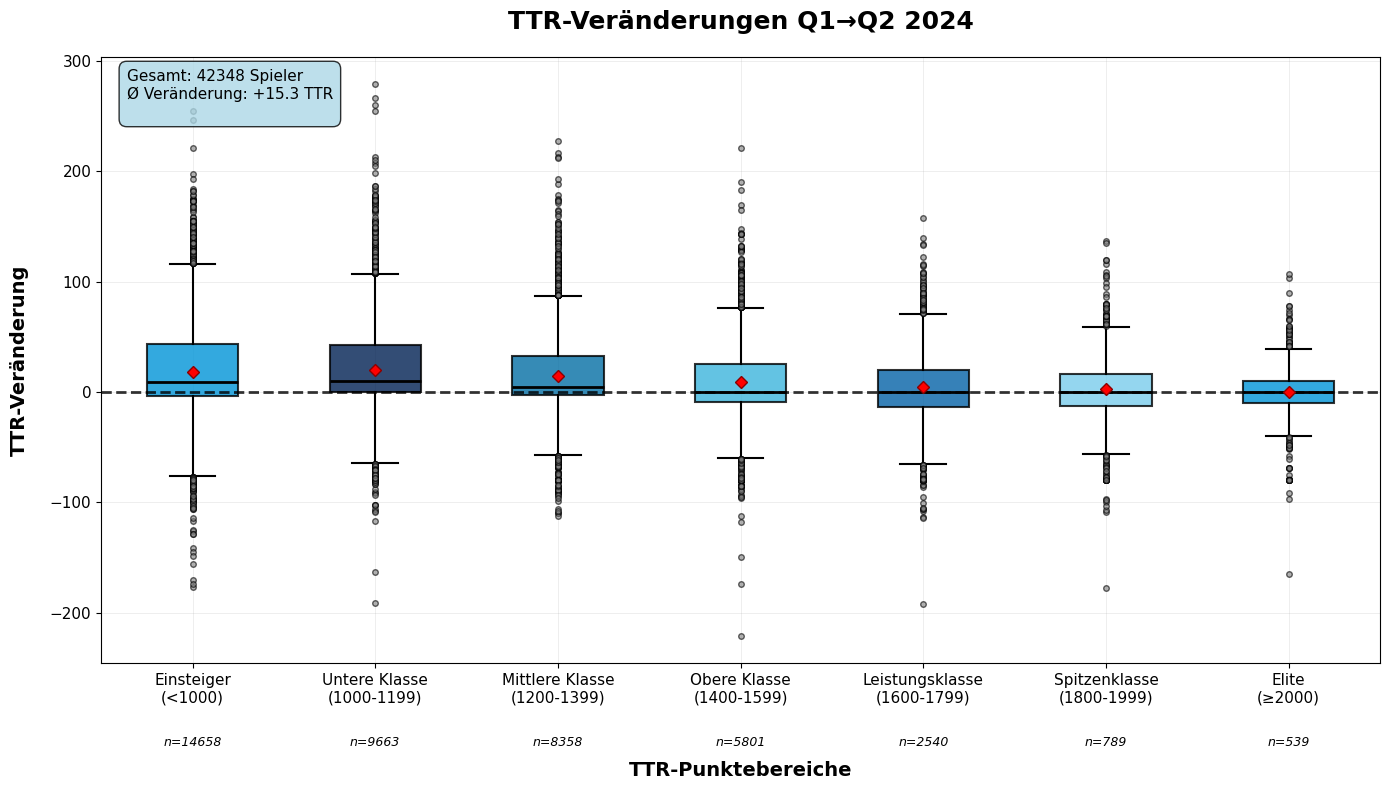

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Q2_Q3_2024.png


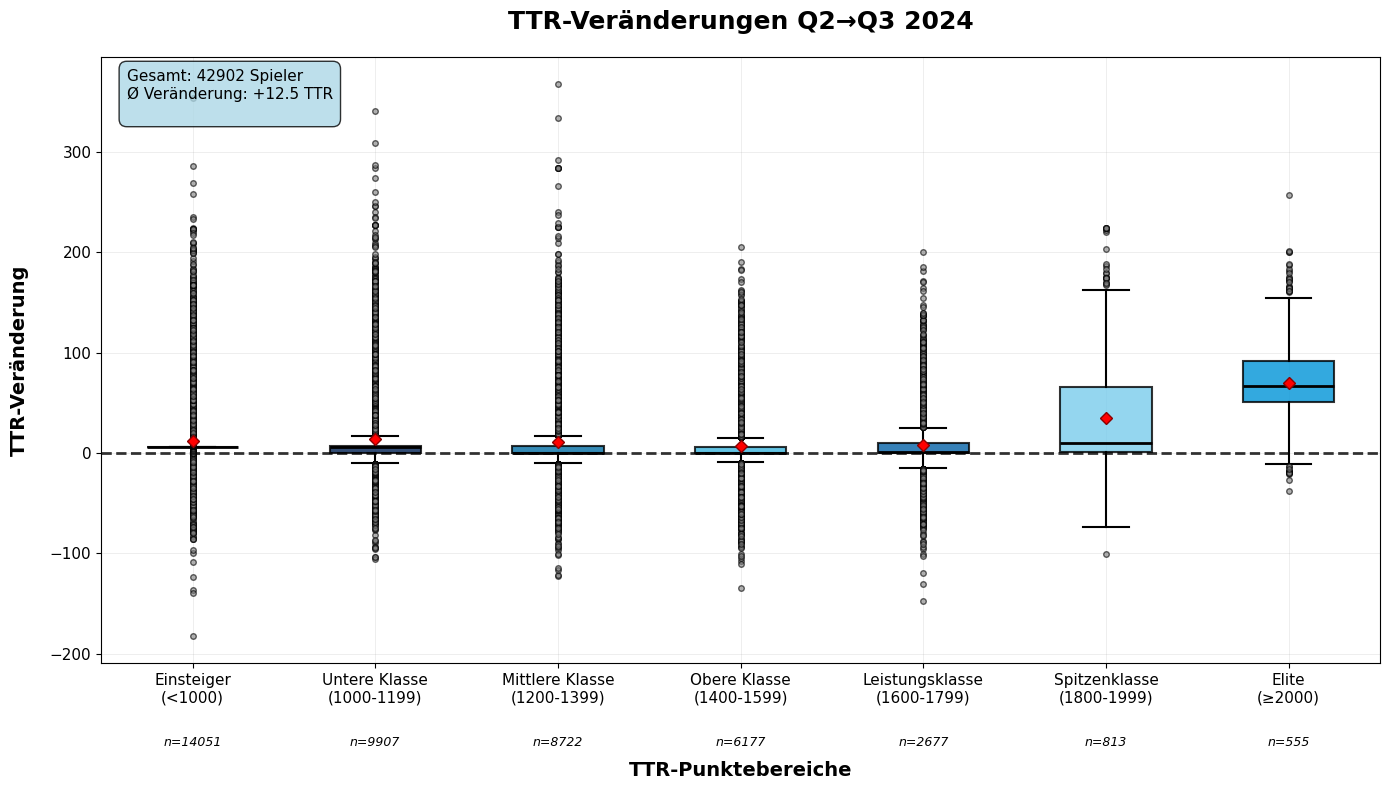

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Q3_Q4_2024.png


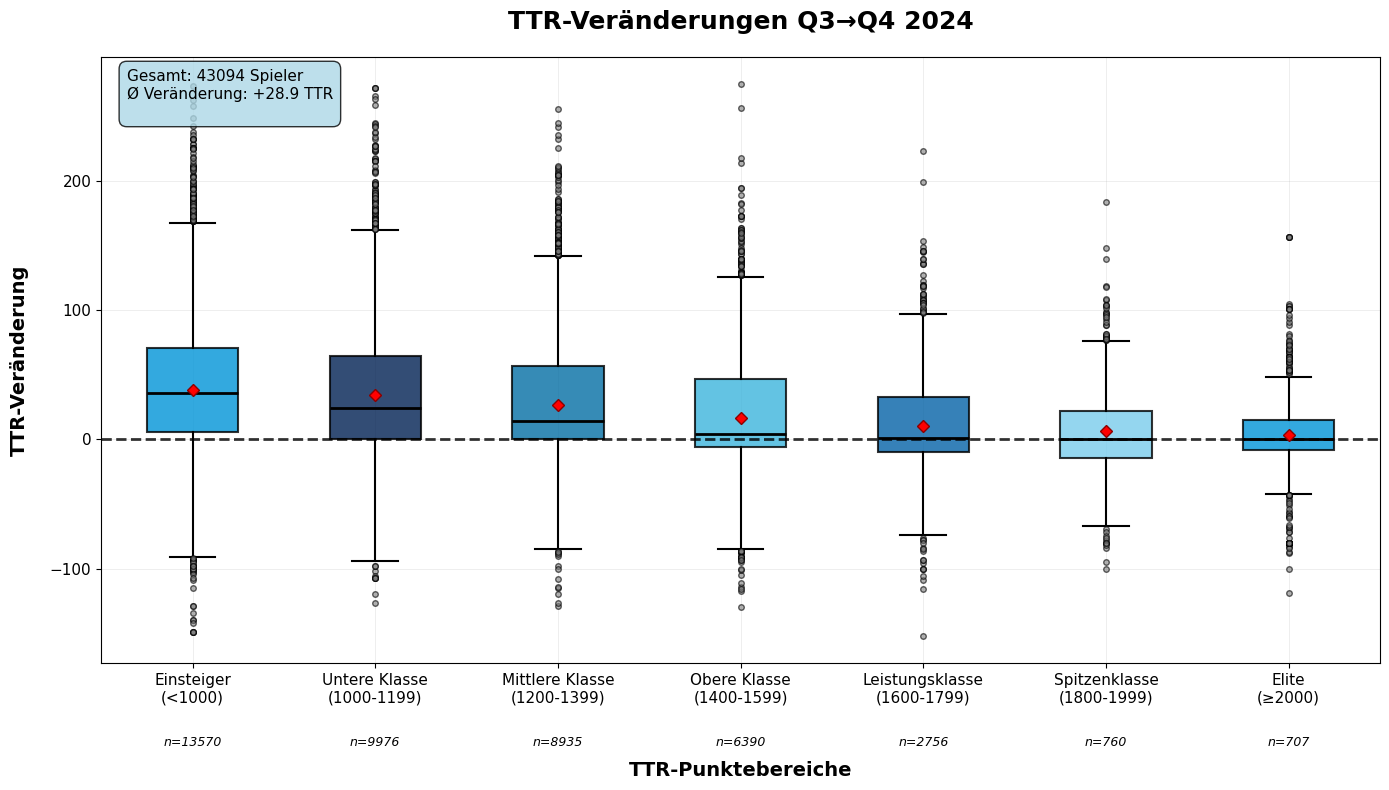

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Q4_2024_Q1_2025.png


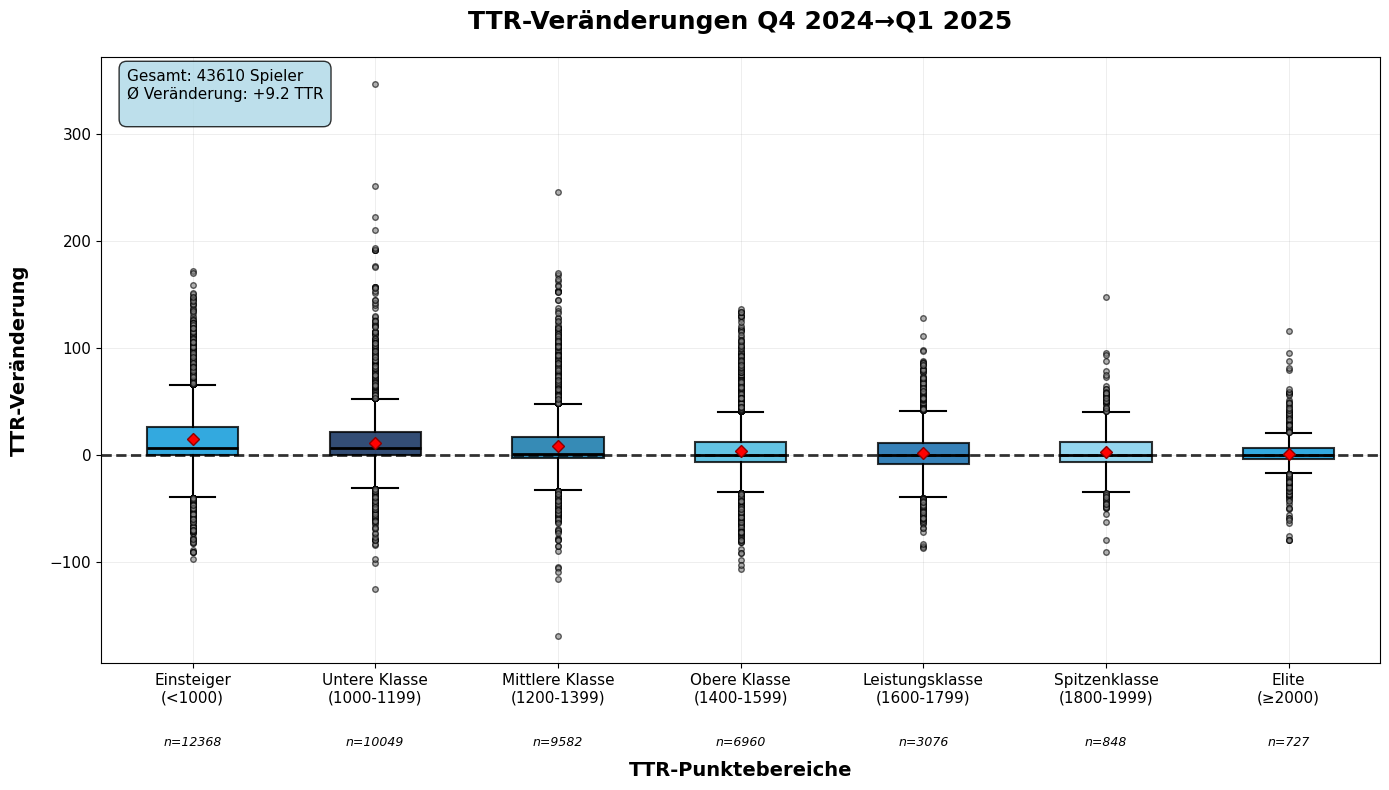

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Jahr_2024_2025.png


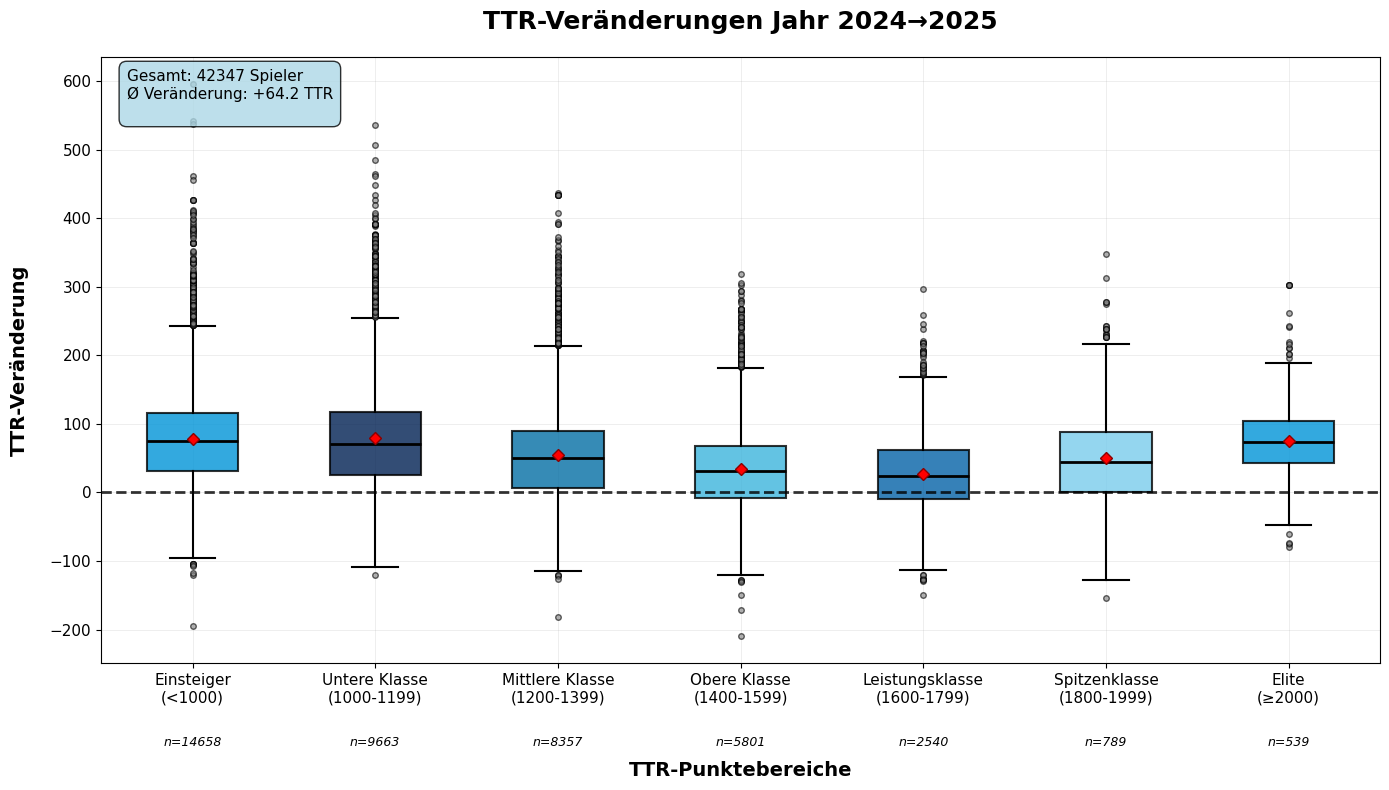

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1/TTR_Veraenderungen_Jahr_2023_2024.png


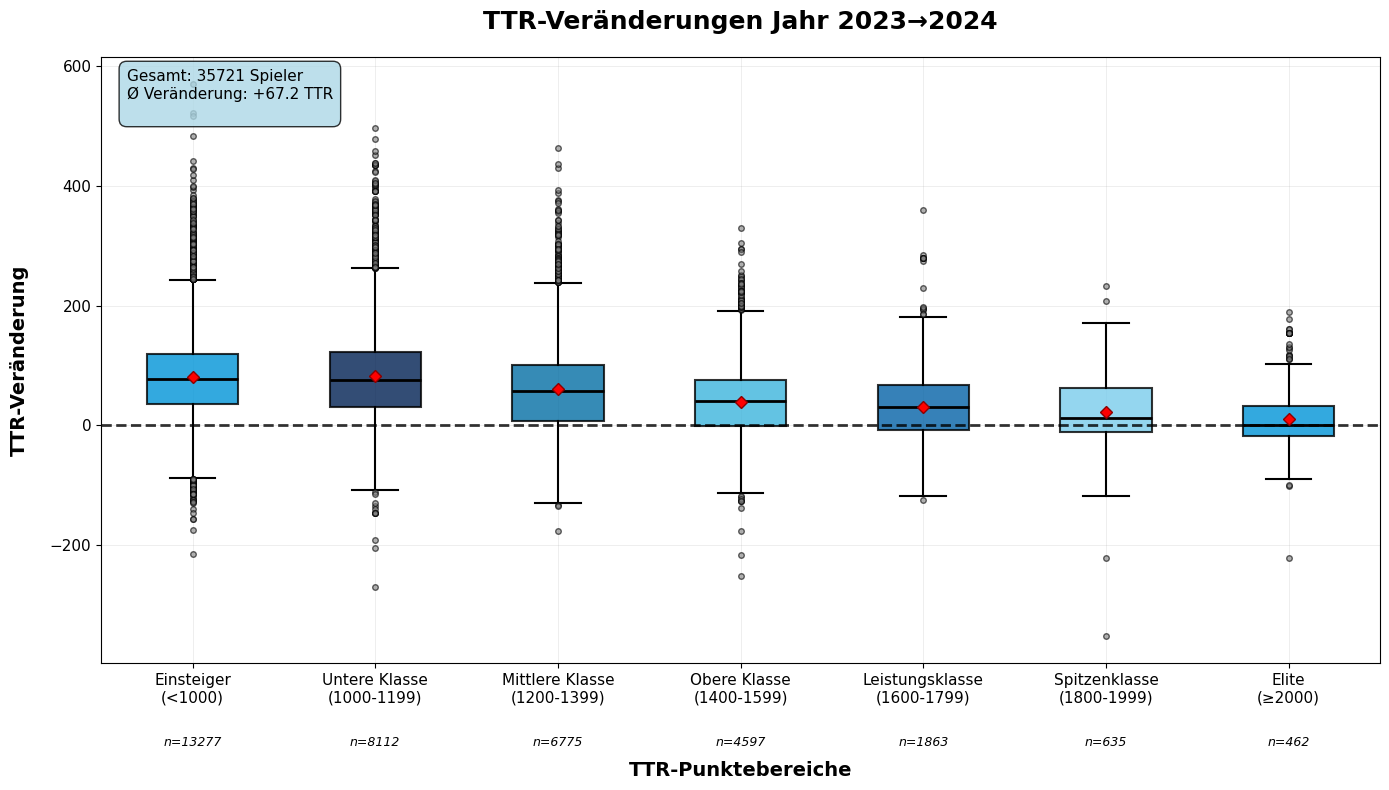

KeyError: 'Median_Veraenderung'

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def create_individual_boxplot_visualizations(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt einzelne Boxplot-Visualisierungen für jeden Quartalswechsel und speichert sie
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Ordner, wo die Plots gespeichert werden sollen
    dpi: Auflösung der gespeicherten Bilder
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    # Erstelle Speicher-Ordner falls nicht vorhanden
    save_dir = Path("/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Speichere Visualisierungen in: {save_dir}")
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None  # Wird gefiltert
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Definiere alle Perioden
    periods = [
        {
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Q1→Q2 2024',
            'filename': 'TTR_Veraenderungen_Q1_Q2_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'base_col': 'TTR_Q2_2024',
            'title': 'TTR-Veränderungen Q2→Q3 2024',
            'filename': 'TTR_Veraenderungen_Q2_Q3_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'base_col': 'TTR_Q3_2024',
            'title': 'TTR-Veränderungen Q3→Q4 2024',
            'filename': 'TTR_Veraenderungen_Q3_Q4_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'base_col': 'TTR_Q4_2024',
            'title': 'TTR-Veränderungen Q4 2024→Q1 2025',
            'filename': 'TTR_Veraenderungen_Q4_2024_Q1_2025'
        }
    ]
    
    # Jahresvergleich 2024-2025
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append({
            'change_col': 'TTR_Jahr_2024_2025',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Jahr 2024→2025',
            'filename': 'TTR_Veraenderungen_Jahr_2024_2025'
        })
    
    # Jahresvergleich 2023-2024
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append({
            'change_col': 'TTR_Jahr_2023_2024',
            'base_col': 'TTR_Q1_2023',
            'title': 'TTR-Veränderungen Jahr 2023→2024',
            'filename': 'TTR_Veraenderungen_Jahr_2023_2024'
        })
    
    # Kategorien-Reihenfolge und Farben
    category_order = [
        'Einsteiger\n(<1000)',
        'Untere Klasse\n(1000-1199)', 
        'Mittlere Klasse\n(1200-1399)',
        'Obere Klasse\n(1400-1599)',
        'Leistungsklasse\n(1600-1799)',
        'Spitzenklasse\n(1800-1999)',
        'Elite\n(≥2000)'
    ]
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    # Erweitere für alle 7 Kategorien (falls nicht genug Farben vorhanden, wiederhole)
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Sammle Informationen für Zusammenfassung
    summary_info = []
    
    # Erstelle Plots für jede Periode
    for period_info in periods:
        change_col = period_info['change_col']
        base_col = period_info['base_col']
        title = period_info['title']
        filename = period_info['filename']
        
        # Überprüfe ob Spalten vorhanden sind
        if change_col not in df_ohne_ausland.columns or base_col not in df_ohne_ausland.columns:
            print(f"Warnung: Spalten für {title} nicht gefunden - überspringe...")
            continue
        
        # Bereite Daten vor
        mask = (df_ohne_ausland[change_col].notna() & 
                df_ohne_ausland[base_col].notna())
        data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
        
        if len(data) == 0:
            print(f"Keine Daten für {title} - überspringe...")
            continue
        
        # Kategorisiere TTR
        data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
        data = data.dropna(subset=['TTR_Kategorie'])
        
        if len(data) == 0:
            print(f"Keine gültigen TTR-Kategorien für {title} - überspringe...")
            continue
        
        # Erstelle Plot
        plt.figure(figsize=(14, 8))
        
        # Bereite Boxplot-Daten vor
        box_data = []
        box_labels = []
        box_colors = []
        sample_sizes = []
        
        for category in category_order:
            cat_data = data[data['TTR_Kategorie'] == category][change_col]
            if len(cat_data) > 0:
                box_data.append(cat_data.values)
                box_labels.append(category)
                box_colors.append(color_dict[category])
                sample_sizes.append(len(cat_data))
        
        if not box_data:
            print(f"Keine Daten für Boxplots in {title} - überspringe...")
            plt.close()
            continue
        
        # Erstelle Boxplot
        bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True,
                        showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'red', 
                                                 'markeredgecolor': 'darkred', 'markersize': 6},
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.5},
                        capprops={'linewidth': 1.5},
                        flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'alpha': 0.6})
        
        # Farben setzen
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_linewidth(1.5)
        
        # Styling
        plt.title(title, fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        # Grid und Nulllinie
        plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        
        # Achsen-Styling - X-Achse NICHT rotiert
        plt.xticks(fontsize=11, rotation=0, ha='center')
        plt.yticks(fontsize=11)
        
        # Füge Statistiken als Text hinzu
        stats_text = f"Gesamt: {len(data)} Spieler\n"
        avg_change = data[change_col].mean()
        stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR\n"

        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                fontsize=11, verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
        
        # Füge Sample-Größen unter die Labels hinzu (mit Zahlen in der Beschriftung)
        ax = plt.gca()
        for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
            # Ersetzt die Kategorie-Namen durch Zahlen 1-7
            category_number = category_order.index(label) + 1
            ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
                   f'n={n}', ha='center', va='top', fontsize=9, style='italic')
                
        
        plt.tight_layout()
        
        # Speichere Plot
        save_file = save_dir / f"{filename}.{format}"
        plt.savefig(save_file, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        
        print(f"✓ Gespeichert: {save_file}")
        
        # Sammle Info für Zusammenfassung
        summary_info.append({
            'Periode': title,
            'Datei': f"{filename}.{format}",
            'Anzahl_Spieler': len(data),
            'Anzahl_Kategorien': len(box_data),
            'Avg_Veraenderung': round(avg_change, 1)
        })
        
        plt.show()
        plt.close()
    
    # Erstelle Zusammenfassungs-Bericht
    create_summary_report(summary_info, save_dir, format)
    
    print(f"\n✅ Alle Visualisierungen erfolgreich erstellt und gespeichert in: {save_dir}")
    print(f"📁 Anzahl erstellter Plots: {len(summary_info)}")
    
    return summary_info

def create_summary_report(summary_info, save_dir, format):
    """
    Erstellt einen Zusammenfassungs-Bericht als Textdatei
    """
    
    if not summary_info:
        return
    
    report_file = save_dir / "Zusammenfassung_TTR_Visualisierungen.txt"
    
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ZUSAMMENFASSUNG - TTR-VERÄNDERUNGS-VISUALISIERUNGEN\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Erstellungsdatum: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Speicherort: {save_dir}\n")
        f.write(f"Dateiformat: {format}\n")
        f.write(f"Anzahl Visualisierungen: {len(summary_info)}\n\n")
        
        f.write("ÜBERSICHT ERSTELLTER VISUALISIERUNGEN:\n")
        f.write("-" * 80 + "\n")
        
        for i, info in enumerate(summary_info, 1):
            f.write(f"{i}. {info['Periode']}\n")
            f.write(f"   Datei: {info['Datei']}\n")
            f.write(f"   Anzahl Spieler: {info['Anzahl_Spieler']}\n")
            f.write(f"   TTR-Kategorien: {info['Anzahl_Kategorien']}\n")
            f.write(f"   Ø TTR-Veränderung: {info['Avg_Veraenderung']:+.1f}\n")
            f.write(f"   Median TTR-Veränderung: {info['Median_Veraenderung']:+.1f}\n")
            f.write("\n")
        
        f.write("VISUALISIERUNGS-SPEZIFIKATIONEN:\n")
        f.write("-" * 80 + "\n")
        f.write("• X-Achse: TTR-Punktebereiche (7 Kategorien)\n")
        f.write("• Y-Achse: TTR-Veränderungen\n")
        f.write("• Darstellung: Boxplots mit Median, Quartilen, Ausreißern\n")
        f.write("• Zusätzliche Elemente: Mittelwerte (rote Rauten), Sample-Größen\n")
        f.write("• Nulllinie: Gestrichelte schwarze Linie bei y=0\n")
        f.write("• Statistiken: Textbox mit Gesamtanzahl und Durchschnittswerten\n\n")
        
        f.write("TTR-KATEGORIEN:\n")
        f.write("-" * 80 + "\n")
        f.write("1. Einsteiger (<1000 TTR)\n")
        f.write("2. Untere Klasse (1000-1199 TTR)\n")
        f.write("3. Mittlere Klasse (1200-1399 TTR)\n")
        f.write("4. Obere Klasse (1400-1599 TTR)\n")
        f.write("5. Leistungsklasse (1600-1799 TTR)\n")
        f.write("6. Spitzenklasse (1800-1999 TTR)\n")
        f.write("7. Elite (≥2000 TTR)\n\n")
        
    print(f"📄 Zusammenfassungs-Bericht erstellt: {report_file}")

def create_comparison_overview(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt eine Übersichts-Visualisierung mit allen Perioden zum Vergleich
    """
    
    save_dir = Path(save_path)
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Sammle alle Daten
    all_periods_data = []
    
    periods = [
        ('Q-TTR_dif_24_Q1-24_Q2', 'TTR_Q1_2024', 'Q1→Q2 2024'),
        ('Q-TTR_dif_24_Q2-24_Q3', 'TTR_Q2_2024', 'Q2→Q3 2024'),
        ('Q-TTR_dif_24_Q3-24_Q4', 'TTR_Q3_2024', 'Q3→Q4 2024'),
        ('Q-TTR_dif_24_Q4-25_Q1', 'TTR_Q4_2024', 'Q4 2024→Q1 2025')
    ]
    
    # Jahresvergleiche hinzufügen
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append(('TTR_Jahr_2024_2025', 'TTR_Q1_2024', 'Jahr 2024→2025'))
    
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append(('TTR_Jahr_2023_2024', 'TTR_Q1_2023', 'Jahr 2023→2024'))
    
    for change_col, base_col, period_name in periods:
        if change_col in df_ohne_ausland.columns and base_col in df_ohne_ausland.columns:
            mask = df_ohne_ausland[change_col].notna() & df_ohne_ausland[base_col].notna()
            data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
            
            if len(data) > 0:
                data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
                data = data.dropna(subset=['TTR_Kategorie'])
                data['Periode'] = period_name
                data.columns = ['TTR_Diff', 'TTR_Base', 'TTR_Kategorie', 'Periode']
                all_periods_data.append(data)
    
    if all_periods_data:
        combined_data = pd.concat(all_periods_data, ignore_index=True)
        
        # Erstelle Vergleichs-Plot
        plt.figure(figsize=(16, 10))
        
        sns.boxplot(data=combined_data, x='TTR_Kategorie', y='TTR_Diff', hue='Periode',
                   palette='Set2')
        
        plt.title('TTR-Veränderungen im Vergleich - Alle Perioden', 
                 fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        plt.xticks(rotation=0, ha='center')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        plt.legend(title='Periode', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        
        # Speichere Vergleichsplot
        comparison_file = save_dir / f"TTR_Veraenderungen_Vergleich_Alle_Perioden.{format}"
        plt.savefig(comparison_file, dpi=dpi, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        
        print(f"📊 Vergleichsvisualisierung gespeichert: {comparison_file}")
        plt.show()
        plt.close()

# Hauptfunktion
def main_create_individual_plots(df_top_positiv, save_path, 
                                include_comparison=True, dpi=300, format='png'):
    """
    Hauptfunktion zum Erstellen aller individuellen Plots
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Speicher-Ordner
    include_comparison: True für zusätzliche Vergleichsvisualisierung
    dpi: Bildauflösung (300 für hohe Qualität)
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    print("Starte Erstellung individueller TTR-Boxplot-Visualisierungen...")
    print(f"Speicherort: {save_path}")
    print(f"Format: {format}, DPI: {dpi}")
    
    # Erstelle individuelle Plots
    summary_info = create_individual_boxplot_visualizations(
        df_top_positiv, save_path, dpi, format
    )
    
    # Erstelle Vergleichsvisualisierung
    if include_comparison and summary_info:
        create_comparison_overview(df_top_positiv, save_path, dpi, format)
    
    print("\n🎉 Alle Visualisierungen erfolgreich erstellt!")
    
    return summary_info

# Verwendung:
save_directory = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top1"  # Passe den Pfad an
summary = main_create_individual_plots(df_top_positiv, save_directory, 
                                       include_comparison=True, dpi=300, format='png')

### Einzelne Plots - Top 5

Starte Erstellung individueller TTR-Boxplot-Visualisierungen...
Speicherort: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5
Format: png, DPI: 300
Speichere Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5
✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Q1_Q2_2024.png


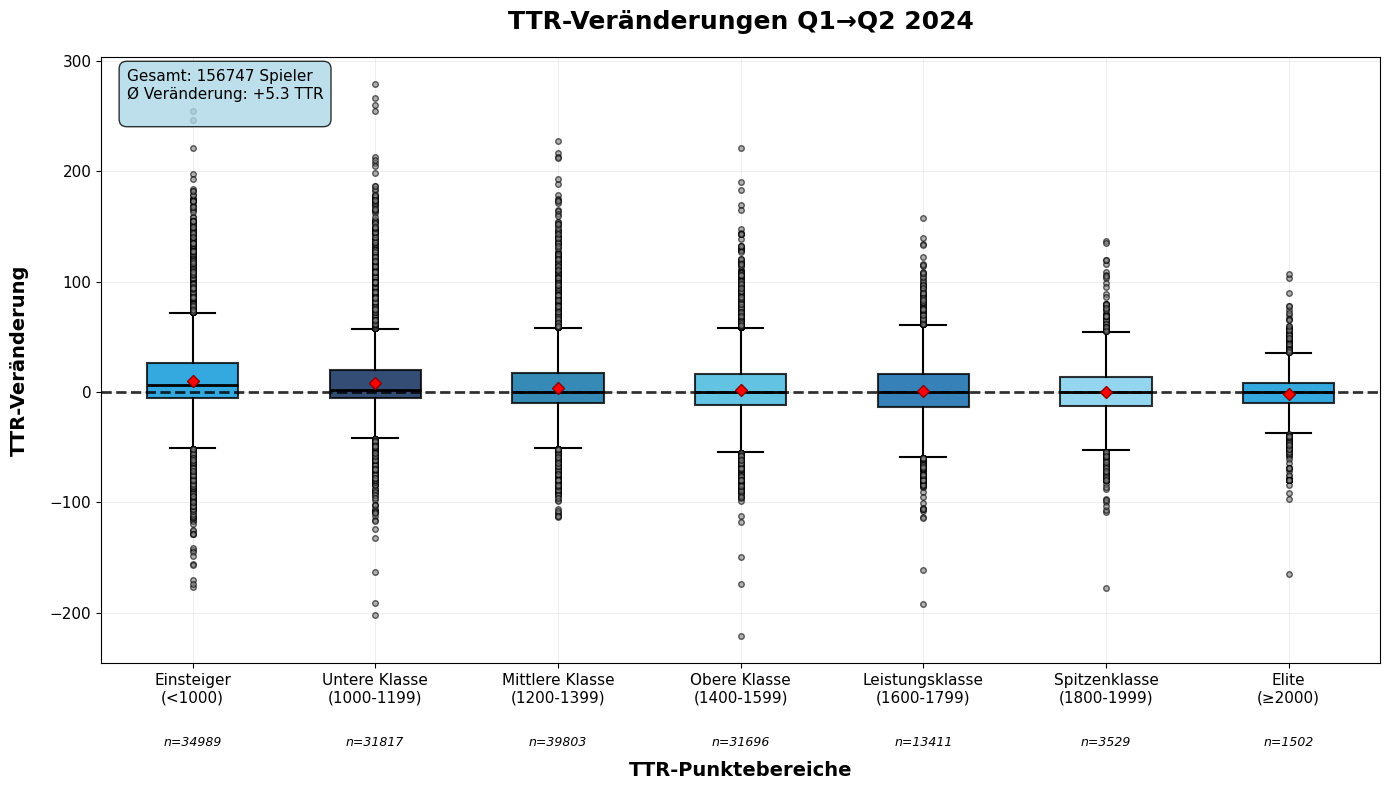

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Q2_Q3_2024.png


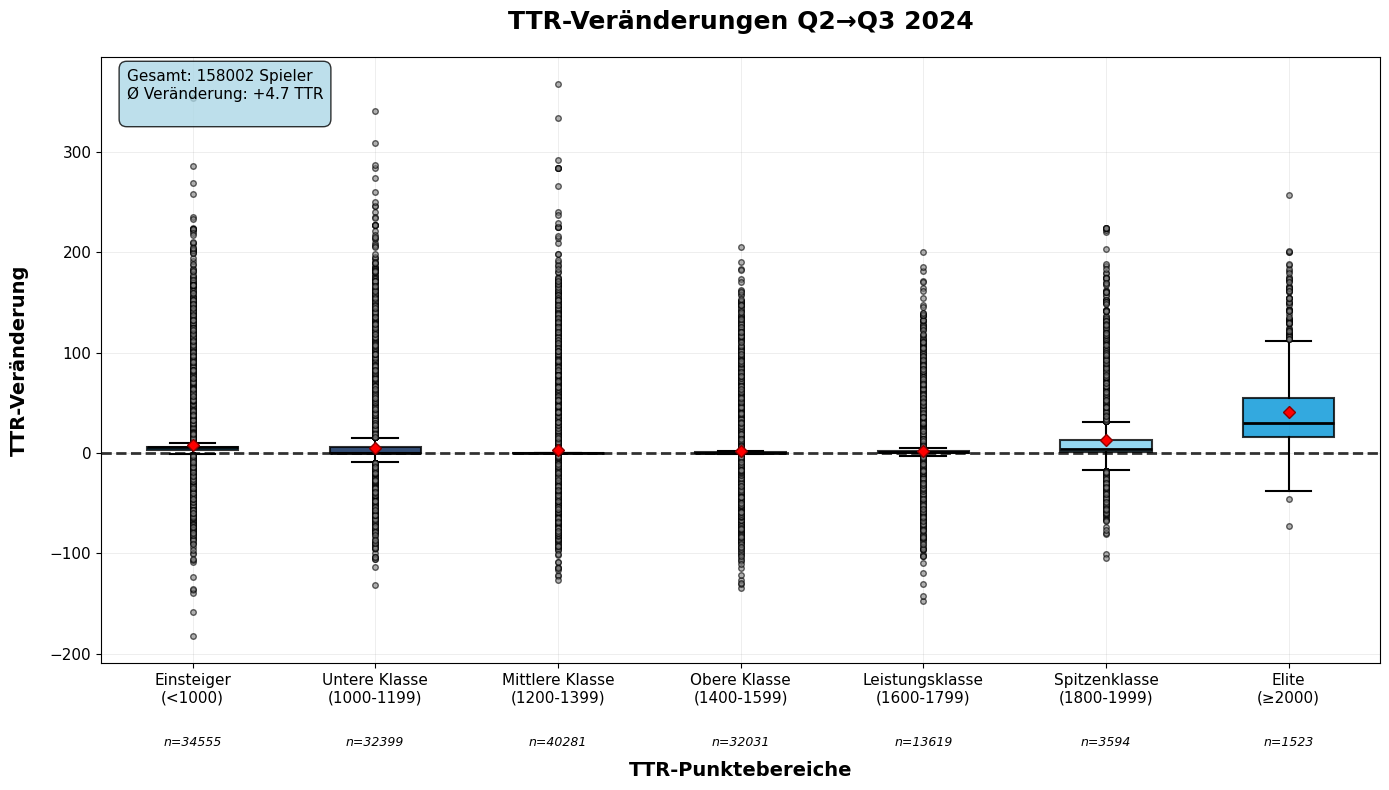

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Q3_Q4_2024.png


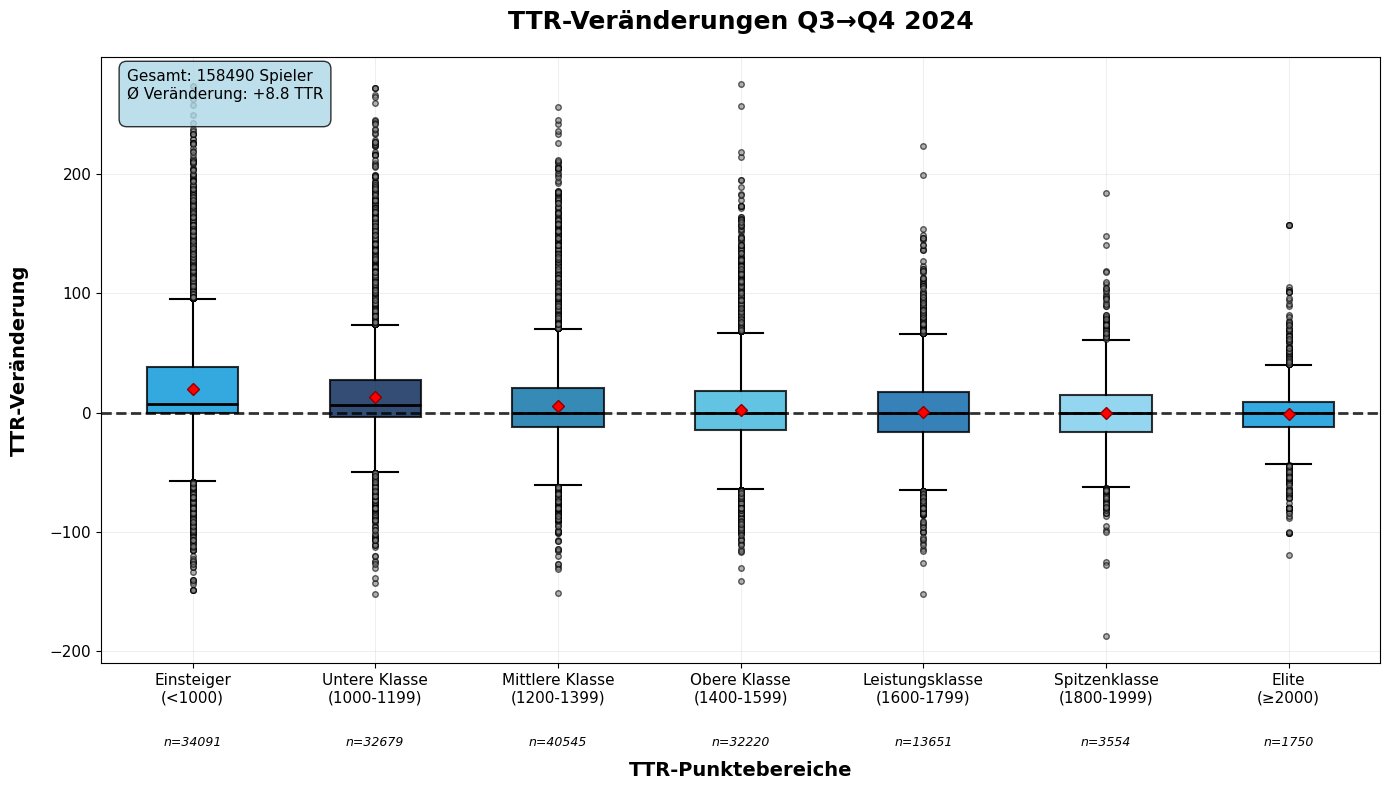

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Q4_2024_Q1_2025.png


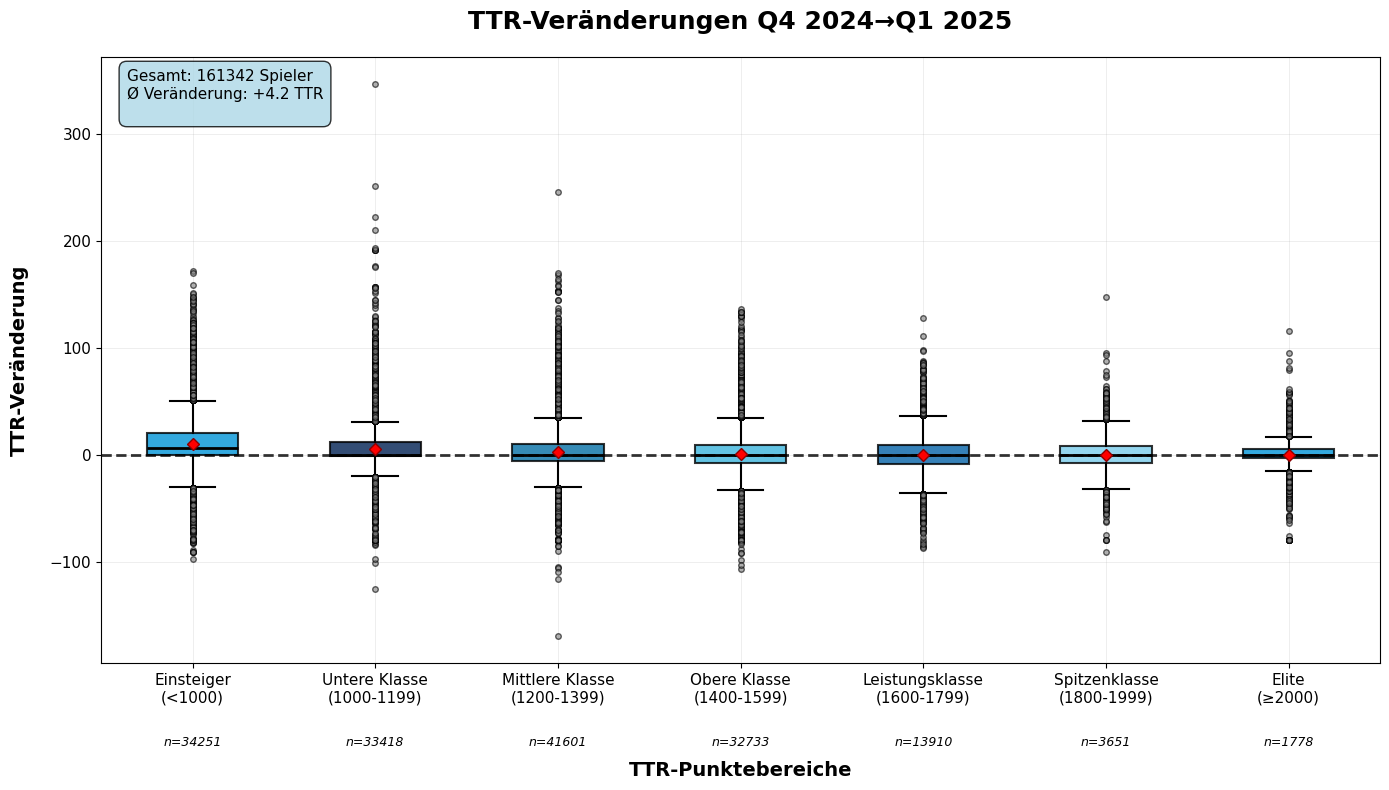

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Jahr_2024_2025.png


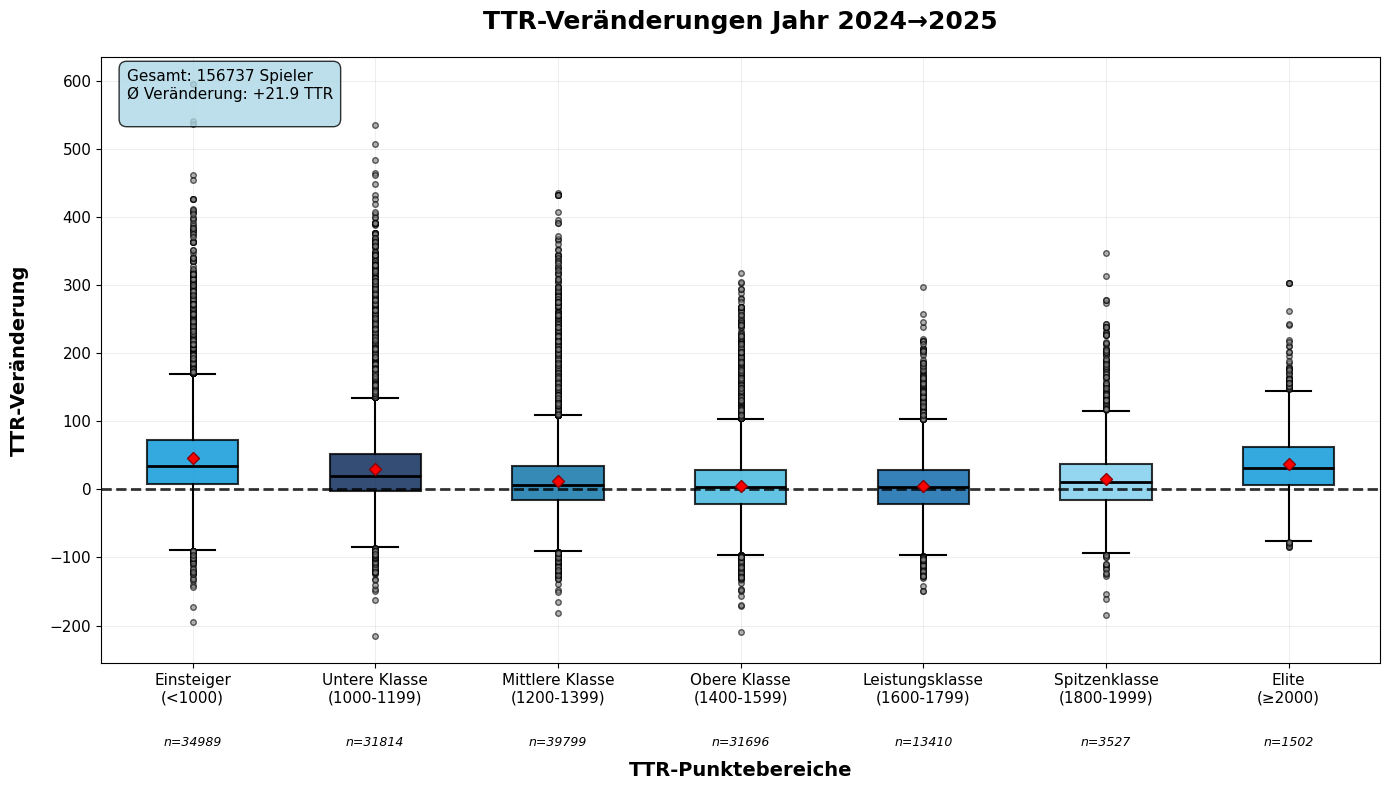

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5/TTR_Veraenderungen_Jahr_2023_2024.png


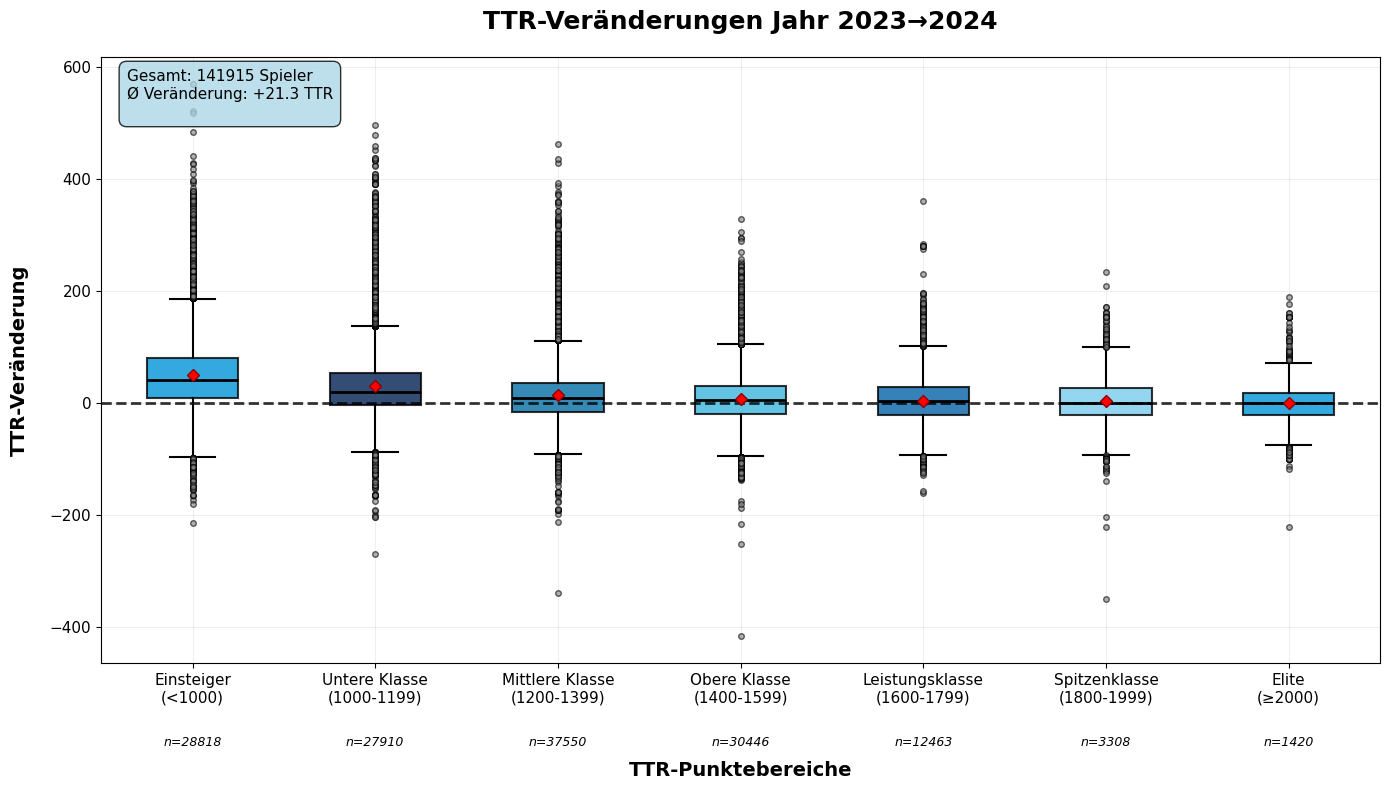

KeyError: 'Median_Veraenderung'

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def create_individual_boxplot_visualizations(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt einzelne Boxplot-Visualisierungen für jeden Quartalswechsel und speichert sie
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Ordner, wo die Plots gespeichert werden sollen
    dpi: Auflösung der gespeicherten Bilder
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    # Erstelle Speicher-Ordner falls nicht vorhanden
    save_dir = Path("/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Speichere Visualisierungen in: {save_dir}")
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None  # Wird gefiltert
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Definiere alle Perioden
    periods = [
        {
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Q1→Q2 2024',
            'filename': 'TTR_Veraenderungen_Q1_Q2_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'base_col': 'TTR_Q2_2024',
            'title': 'TTR-Veränderungen Q2→Q3 2024',
            'filename': 'TTR_Veraenderungen_Q2_Q3_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'base_col': 'TTR_Q3_2024',
            'title': 'TTR-Veränderungen Q3→Q4 2024',
            'filename': 'TTR_Veraenderungen_Q3_Q4_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'base_col': 'TTR_Q4_2024',
            'title': 'TTR-Veränderungen Q4 2024→Q1 2025',
            'filename': 'TTR_Veraenderungen_Q4_2024_Q1_2025'
        }
    ]
    
    # Jahresvergleich 2024-2025
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append({
            'change_col': 'TTR_Jahr_2024_2025',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Jahr 2024→2025',
            'filename': 'TTR_Veraenderungen_Jahr_2024_2025'
        })
    
    # Jahresvergleich 2023-2024
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append({
            'change_col': 'TTR_Jahr_2023_2024',
            'base_col': 'TTR_Q1_2023',
            'title': 'TTR-Veränderungen Jahr 2023→2024',
            'filename': 'TTR_Veraenderungen_Jahr_2023_2024'
        })
    
    # Kategorien-Reihenfolge und Farben
    category_order = [
        'Einsteiger\n(<1000)',
        'Untere Klasse\n(1000-1199)', 
        'Mittlere Klasse\n(1200-1399)',
        'Obere Klasse\n(1400-1599)',
        'Leistungsklasse\n(1600-1799)',
        'Spitzenklasse\n(1800-1999)',
        'Elite\n(≥2000)'
    ]
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    # Erweitere für alle 7 Kategorien (falls nicht genug Farben vorhanden, wiederhole)
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Sammle Informationen für Zusammenfassung
    summary_info = []
    
    # Erstelle Plots für jede Periode
    for period_info in periods:
        change_col = period_info['change_col']
        base_col = period_info['base_col']
        title = period_info['title']
        filename = period_info['filename']
        
        # Überprüfe ob Spalten vorhanden sind
        if change_col not in df_ohne_ausland.columns or base_col not in df_ohne_ausland.columns:
            print(f"Warnung: Spalten für {title} nicht gefunden - überspringe...")
            continue
        
        # Bereite Daten vor
        mask = (df_ohne_ausland[change_col].notna() & 
                df_ohne_ausland[base_col].notna())
        data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
        
        if len(data) == 0:
            print(f"Keine Daten für {title} - überspringe...")
            continue
        
        # Kategorisiere TTR
        data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
        data = data.dropna(subset=['TTR_Kategorie'])
        
        if len(data) == 0:
            print(f"Keine gültigen TTR-Kategorien für {title} - überspringe...")
            continue
        
        # Erstelle Plot
        plt.figure(figsize=(14, 8))
        
        # Bereite Boxplot-Daten vor
        box_data = []
        box_labels = []
        box_colors = []
        sample_sizes = []
        
        for category in category_order:
            cat_data = data[data['TTR_Kategorie'] == category][change_col]
            if len(cat_data) > 0:
                box_data.append(cat_data.values)
                box_labels.append(category)
                box_colors.append(color_dict[category])
                sample_sizes.append(len(cat_data))
        
        if not box_data:
            print(f"Keine Daten für Boxplots in {title} - überspringe...")
            plt.close()
            continue
        
        # Erstelle Boxplot
        bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True,
                        showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'red', 
                                                 'markeredgecolor': 'darkred', 'markersize': 6},
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.5},
                        capprops={'linewidth': 1.5},
                        flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'alpha': 0.6})
        
        # Farben setzen
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_linewidth(1.5)
        
        # Styling
        plt.title(title, fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        # Grid und Nulllinie
        plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        
        # Achsen-Styling - X-Achse NICHT rotiert
        plt.xticks(fontsize=11, rotation=0, ha='center')
        plt.yticks(fontsize=11)
        
        # Füge Statistiken als Text hinzu
        stats_text = f"Gesamt: {len(data)} Spieler\n"
        avg_change = data[change_col].mean()
        stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR\n"

        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                fontsize=11, verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
        
        # Füge Sample-Größen unter die Labels hinzu (mit Zahlen in der Beschriftung)
        ax = plt.gca()
        for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
            # Ersetzt die Kategorie-Namen durch Zahlen 1-7
            category_number = category_order.index(label) + 1
            ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
                   f'n={n}', ha='center', va='top', fontsize=9, style='italic')
                
        
        plt.tight_layout()
        
        # Speichere Plot
        save_file = save_dir / f"{filename}.{format}"
        plt.savefig(save_file, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        
        print(f"✓ Gespeichert: {save_file}")
        
        # Sammle Info für Zusammenfassung
        summary_info.append({
            'Periode': title,
            'Datei': f"{filename}.{format}",
            'Anzahl_Spieler': len(data),
            'Anzahl_Kategorien': len(box_data),
            'Avg_Veraenderung': round(avg_change, 1)
        })
        
        plt.show()
        plt.close()
    
    # Erstelle Zusammenfassungs-Bericht
    create_summary_report(summary_info, save_dir, format)
    
    print(f"\n✅ Alle Visualisierungen erfolgreich erstellt und gespeichert in: {save_dir}")
    print(f"📁 Anzahl erstellter Plots: {len(summary_info)}")
    
    return summary_info

def create_summary_report(summary_info, save_dir, format):
    """
    Erstellt einen Zusammenfassungs-Bericht als Textdatei
    """
    
    if not summary_info:
        return
    
    report_file = save_dir / "Zusammenfassung_TTR_Visualisierungen.txt"
    
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ZUSAMMENFASSUNG - TTR-VERÄNDERUNGS-VISUALISIERUNGEN\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Erstellungsdatum: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Speicherort: {save_dir}\n")
        f.write(f"Dateiformat: {format}\n")
        f.write(f"Anzahl Visualisierungen: {len(summary_info)}\n\n")
        
        f.write("ÜBERSICHT ERSTELLTER VISUALISIERUNGEN:\n")
        f.write("-" * 80 + "\n")
        
        for i, info in enumerate(summary_info, 1):
            f.write(f"{i}. {info['Periode']}\n")
            f.write(f"   Datei: {info['Datei']}\n")
            f.write(f"   Anzahl Spieler: {info['Anzahl_Spieler']}\n")
            f.write(f"   TTR-Kategorien: {info['Anzahl_Kategorien']}\n")
            f.write(f"   Ø TTR-Veränderung: {info['Avg_Veraenderung']:+.1f}\n")
            f.write(f"   Median TTR-Veränderung: {info['Median_Veraenderung']:+.1f}\n")
            f.write("\n")
        
        f.write("VISUALISIERUNGS-SPEZIFIKATIONEN:\n")
        f.write("-" * 80 + "\n")
        f.write("• X-Achse: TTR-Punktebereiche (7 Kategorien)\n")
        f.write("• Y-Achse: TTR-Veränderungen\n")
        f.write("• Darstellung: Boxplots mit Median, Quartilen, Ausreißern\n")
        f.write("• Zusätzliche Elemente: Mittelwerte (rote Rauten), Sample-Größen\n")
        f.write("• Nulllinie: Gestrichelte schwarze Linie bei y=0\n")
        f.write("• Statistiken: Textbox mit Gesamtanzahl und Durchschnittswerten\n\n")
        
        f.write("TTR-KATEGORIEN:\n")
        f.write("-" * 80 + "\n")
        f.write("1. Einsteiger (<1000 TTR)\n")
        f.write("2. Untere Klasse (1000-1199 TTR)\n")
        f.write("3. Mittlere Klasse (1200-1399 TTR)\n")
        f.write("4. Obere Klasse (1400-1599 TTR)\n")
        f.write("5. Leistungsklasse (1600-1799 TTR)\n")
        f.write("6. Spitzenklasse (1800-1999 TTR)\n")
        f.write("7. Elite (≥2000 TTR)\n\n")
        
    print(f"📄 Zusammenfassungs-Bericht erstellt: {report_file}")

def create_comparison_overview(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt eine Übersichts-Visualisierung mit allen Perioden zum Vergleich
    """
    
    save_dir = Path(save_path)
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Sammle alle Daten
    all_periods_data = []
    
    periods = [
        ('Q-TTR_dif_24_Q1-24_Q2', 'TTR_Q1_2024', 'Q1→Q2 2024'),
        ('Q-TTR_dif_24_Q2-24_Q3', 'TTR_Q2_2024', 'Q2→Q3 2024'),
        ('Q-TTR_dif_24_Q3-24_Q4', 'TTR_Q3_2024', 'Q3→Q4 2024'),
        ('Q-TTR_dif_24_Q4-25_Q1', 'TTR_Q4_2024', 'Q4 2024→Q1 2025')
    ]
    
    # Jahresvergleiche hinzufügen
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append(('TTR_Jahr_2024_2025', 'TTR_Q1_2024', 'Jahr 2024→2025'))
    
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append(('TTR_Jahr_2023_2024', 'TTR_Q1_2023', 'Jahr 2023→2024'))
    
    for change_col, base_col, period_name in periods:
        if change_col in df_ohne_ausland.columns and base_col in df_ohne_ausland.columns:
            mask = df_ohne_ausland[change_col].notna() & df_ohne_ausland[base_col].notna()
            data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
            
            if len(data) > 0:
                data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
                data = data.dropna(subset=['TTR_Kategorie'])
                data['Periode'] = period_name
                data.columns = ['TTR_Diff', 'TTR_Base', 'TTR_Kategorie', 'Periode']
                all_periods_data.append(data)
    
    if all_periods_data:
        combined_data = pd.concat(all_periods_data, ignore_index=True)
        
        # Erstelle Vergleichs-Plot
        plt.figure(figsize=(16, 10))
        
        sns.boxplot(data=combined_data, x='TTR_Kategorie', y='TTR_Diff', hue='Periode',
                   palette='Set2')
        
        plt.title('TTR-Veränderungen im Vergleich - Alle Perioden', 
                 fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        plt.xticks(rotation=0, ha='center')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        plt.legend(title='Periode', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        
        # Speichere Vergleichsplot
        comparison_file = save_dir / f"TTR_Veraenderungen_Vergleich_Alle_Perioden.{format}"
        plt.savefig(comparison_file, dpi=dpi, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        
        print(f"📊 Vergleichsvisualisierung gespeichert: {comparison_file}")
        plt.show()
        plt.close()

# Hauptfunktion
def main_create_individual_plots(df_top_5_positiv, save_path, 
                                include_comparison=True, dpi=300, format='png'):
    """
    Hauptfunktion zum Erstellen aller individuellen Plots
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Speicher-Ordner
    include_comparison: True für zusätzliche Vergleichsvisualisierung
    dpi: Bildauflösung (300 für hohe Qualität)
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    print("Starte Erstellung individueller TTR-Boxplot-Visualisierungen...")
    print(f"Speicherort: {save_path}")
    print(f"Format: {format}, DPI: {dpi}")
    
    # Erstelle individuelle Plots
    summary_info = create_individual_boxplot_visualizations(
        df_top_5_positiv, save_path, dpi, format
    )
    
    # Erstelle Vergleichsvisualisierung
    if include_comparison and summary_info:
        create_comparison_overview(df_top_5_positiv, save_path, dpi, format)
    
    print("\n🎉 Alle Visualisierungen erfolgreich erstellt!")
    
    return summary_info

# Verwendung:
save_directory = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Punktezahl_Top5"  # Passe den Pfad an
summary = main_create_individual_plots(df_top_5_positiv, save_directory, 
                                       include_comparison=True, dpi=300, format='png')

### Einzelne Plots - Ohne Ausländer

Starte Erstellung individueller TTR-Boxplot-Visualisierungen...
Speicherort: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai
Format: png, DPI: 300
Speichere Visualisierungen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai
✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Q1_Q2_2024.png


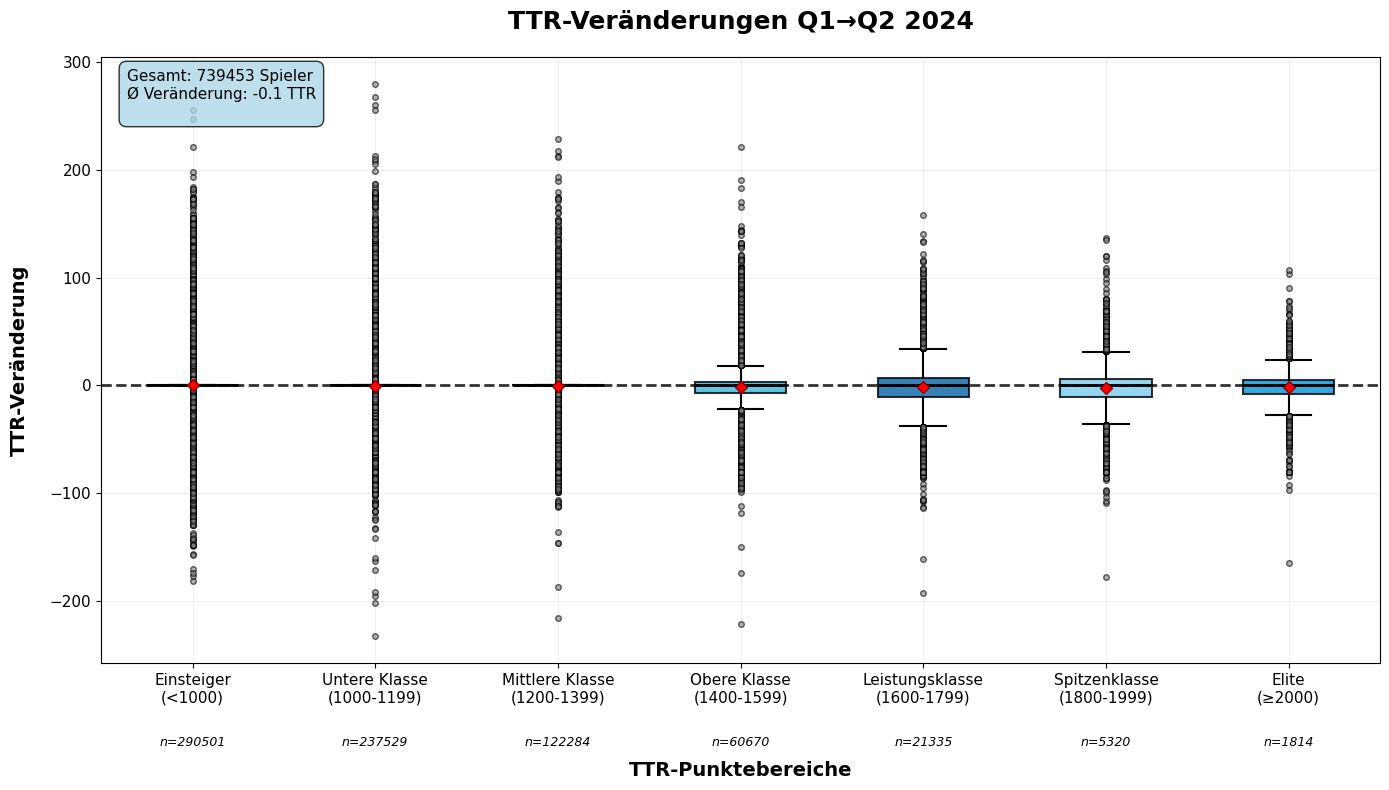

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Q2_Q3_2024.png


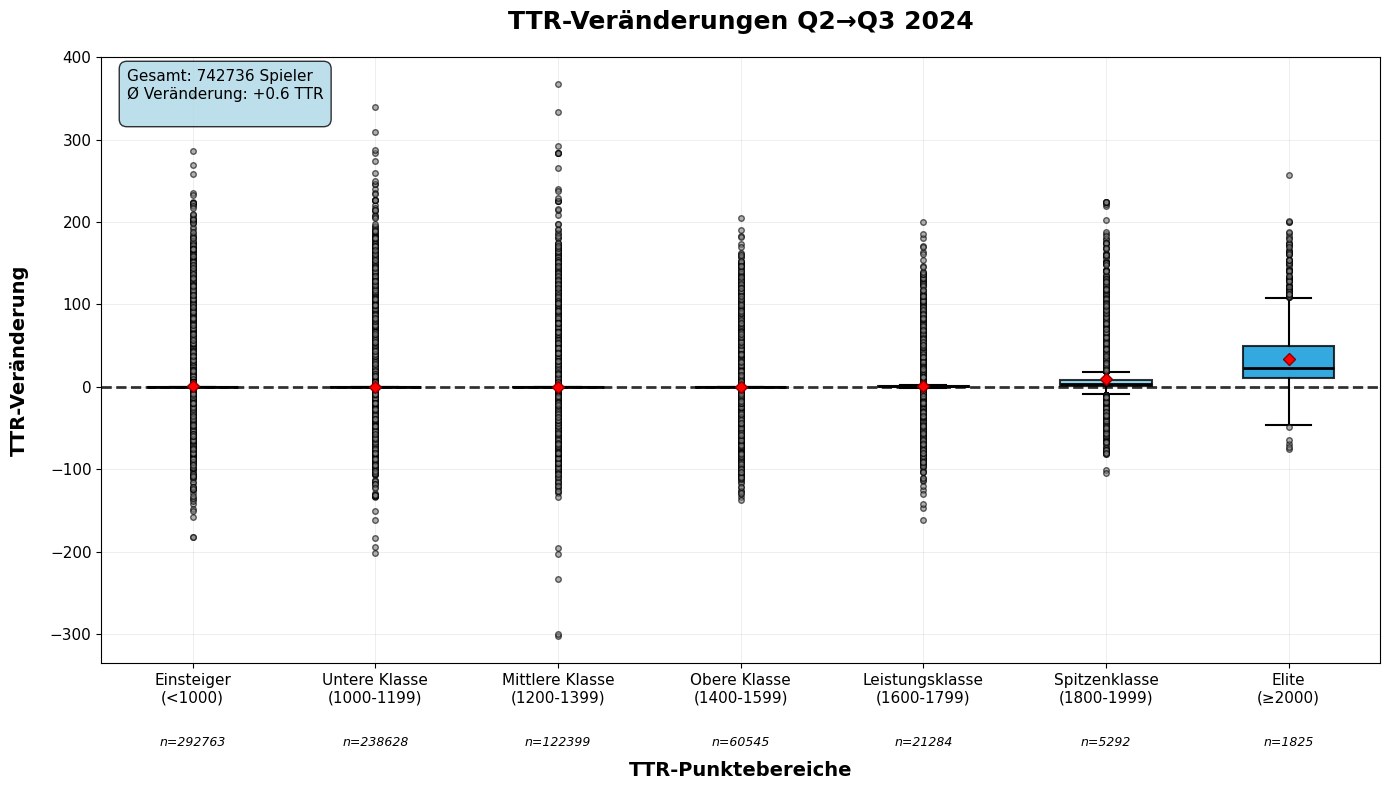

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Q3_Q4_2024.png


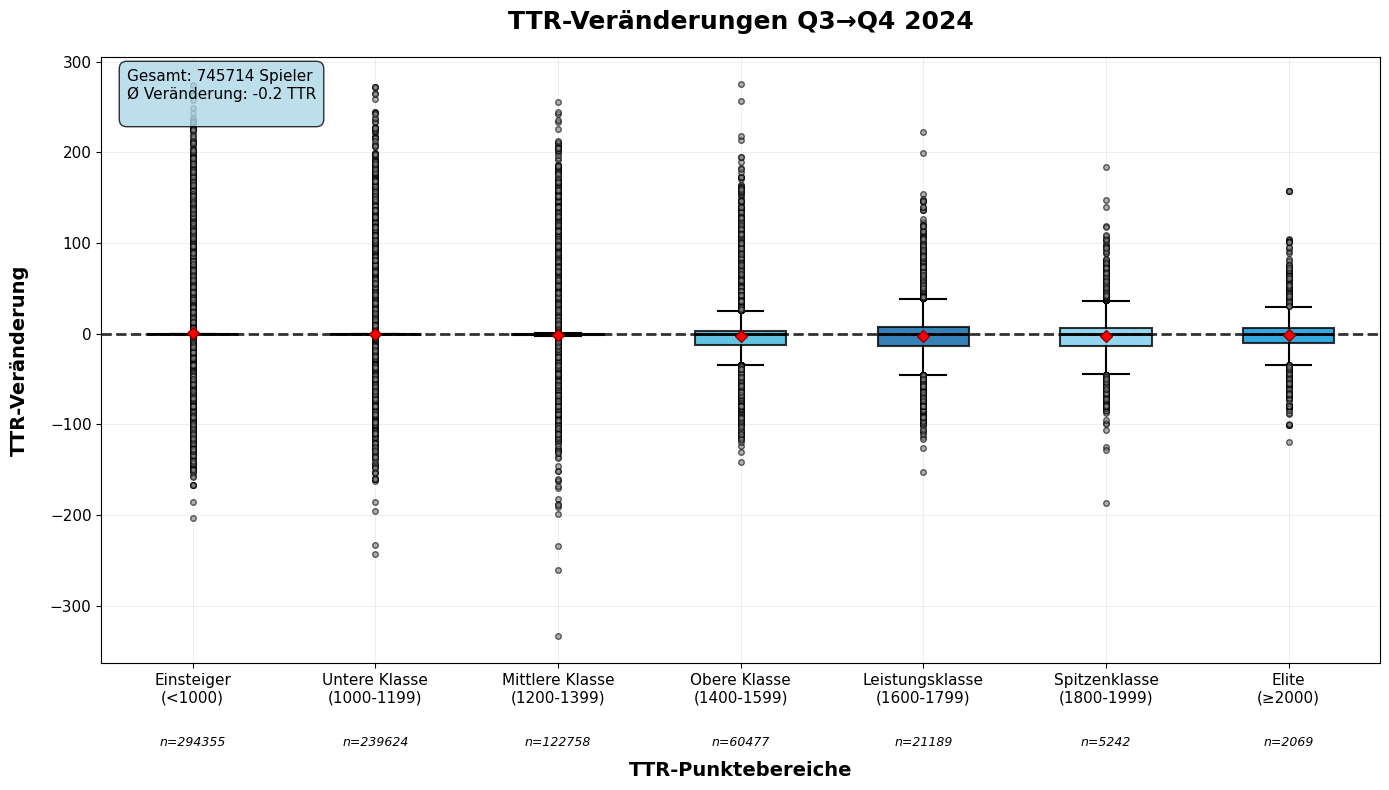

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Q4_2024_Q1_2025.png


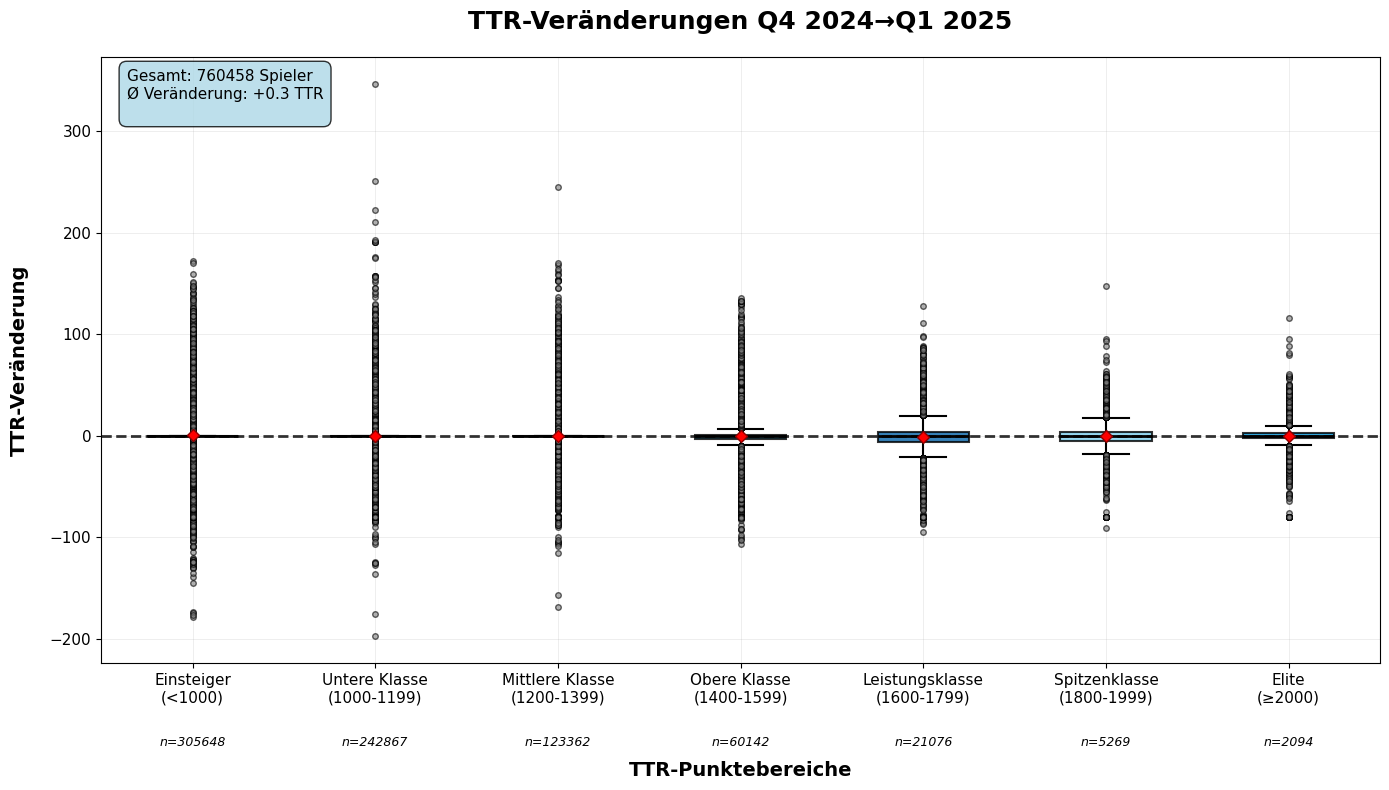

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Jahr_2024_2025.png


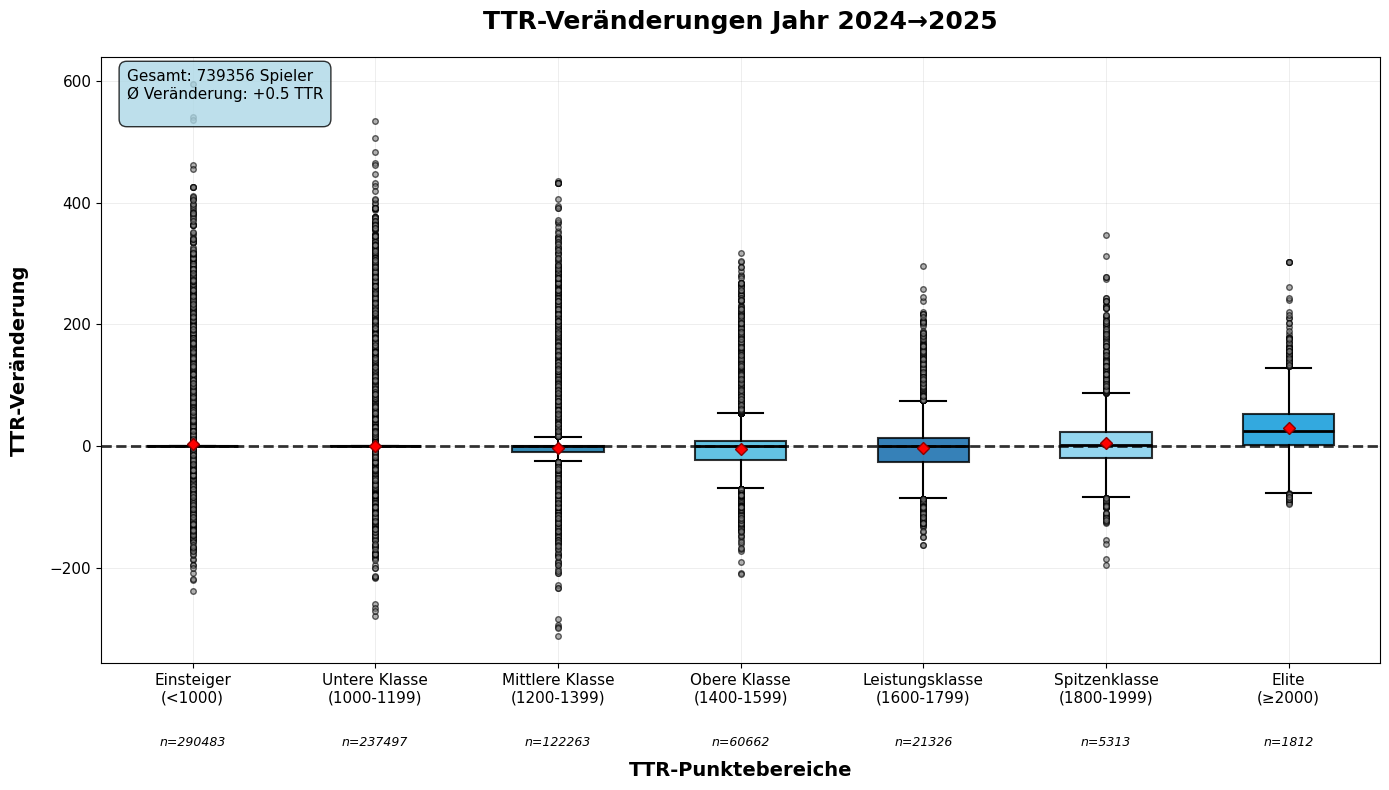

✓ Gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai/TTR_Veraenderungen_Jahr_2023_2024.png


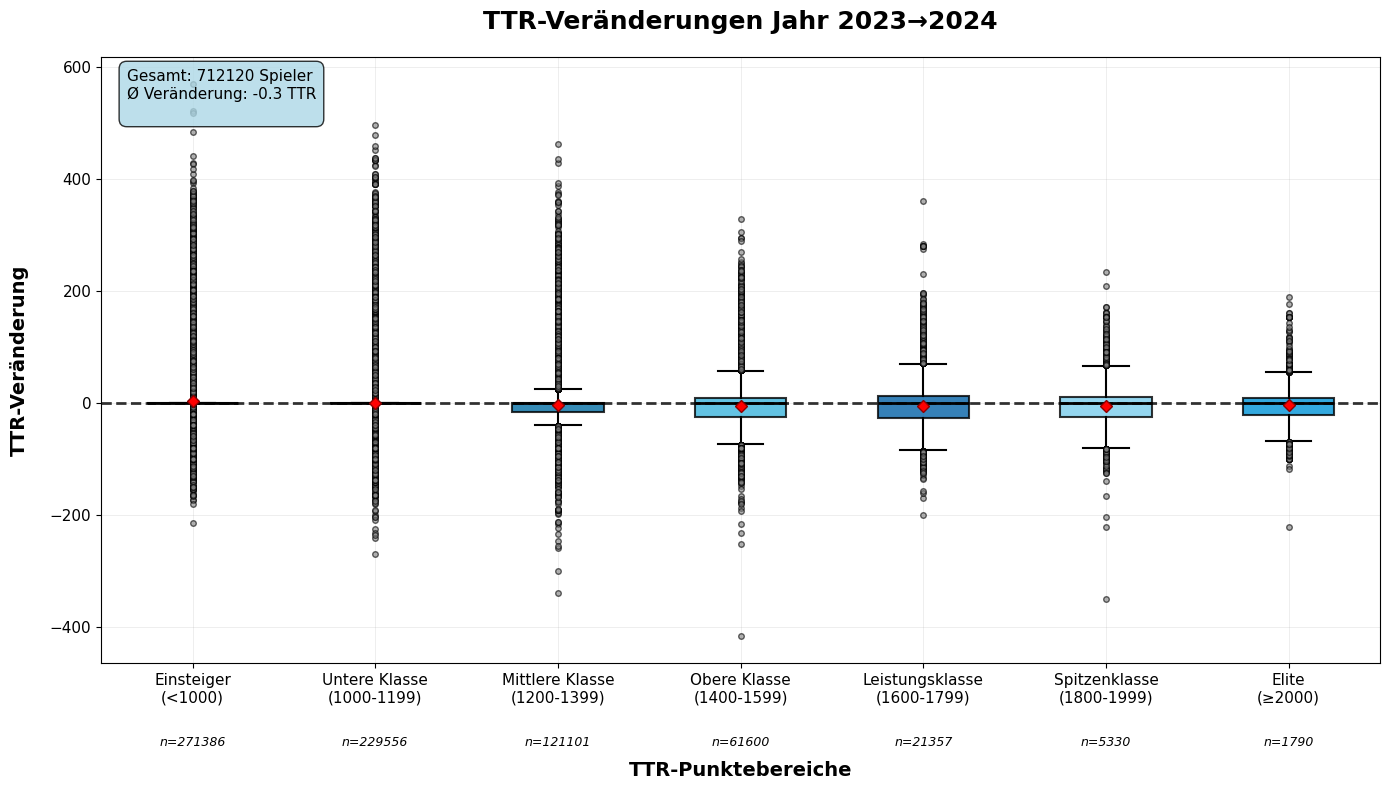

KeyError: 'Median_Veraenderung'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def create_individual_boxplot_visualizations(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt einzelne Boxplot-Visualisierungen für jeden Quartalswechsel und speichert sie
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Ordner, wo die Plots gespeichert werden sollen
    dpi: Auflösung der gespeicherten Bilder
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    # Erstelle Speicher-Ordner falls nicht vorhanden
    save_dir = Path("/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Speichere Visualisierungen in: {save_dir}")
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None  # Wird gefiltert
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Definiere alle Perioden
    periods = [
        {
            'change_col': 'Q-TTR_dif_24_Q1-24_Q2',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Q1→Q2 2024',
            'filename': 'TTR_Veraenderungen_Q1_Q2_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q2-24_Q3',
            'base_col': 'TTR_Q2_2024',
            'title': 'TTR-Veränderungen Q2→Q3 2024',
            'filename': 'TTR_Veraenderungen_Q2_Q3_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q3-24_Q4',
            'base_col': 'TTR_Q3_2024',
            'title': 'TTR-Veränderungen Q3→Q4 2024',
            'filename': 'TTR_Veraenderungen_Q3_Q4_2024'
        },
        {
            'change_col': 'Q-TTR_dif_24_Q4-25_Q1',
            'base_col': 'TTR_Q4_2024',
            'title': 'TTR-Veränderungen Q4 2024→Q1 2025',
            'filename': 'TTR_Veraenderungen_Q4_2024_Q1_2025'
        }
    ]
    
    # Jahresvergleich 2024-2025
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append({
            'change_col': 'TTR_Jahr_2024_2025',
            'base_col': 'TTR_Q1_2024',
            'title': 'TTR-Veränderungen Jahr 2024→2025',
            'filename': 'TTR_Veraenderungen_Jahr_2024_2025'
        })
    
    # Jahresvergleich 2023-2024
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append({
            'change_col': 'TTR_Jahr_2023_2024',
            'base_col': 'TTR_Q1_2023',
            'title': 'TTR-Veränderungen Jahr 2023→2024',
            'filename': 'TTR_Veraenderungen_Jahr_2023_2024'
        })
    
    # Kategorien-Reihenfolge und Farben
    category_order = [
        'Einsteiger\n(<1000)',
        'Untere Klasse\n(1000-1199)', 
        'Mittlere Klasse\n(1200-1399)',
        'Obere Klasse\n(1400-1599)',
        'Leistungsklasse\n(1600-1799)',
        'Spitzenklasse\n(1800-1999)',
        'Elite\n(≥2000)'
    ]
    
    # Farbpalette basierend auf den bereitgestellten Hex-Codes
    colors = ['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec']
    # Erweitere für alle 7 Kategorien (falls nicht genug Farben vorhanden, wiederhole)
    while len(colors) < len(category_order):
        colors.extend(['#0094d8', '#002052', '#046ea4', '#3cb4dc', '#0462a6', '#79ccec'])
    color_dict = dict(zip(category_order, colors[:len(category_order)]))
    
    # Sammle Informationen für Zusammenfassung
    summary_info = []
    
    # Erstelle Plots für jede Periode
    for period_info in periods:
        change_col = period_info['change_col']
        base_col = period_info['base_col']
        title = period_info['title']
        filename = period_info['filename']
        
        # Überprüfe ob Spalten vorhanden sind
        if change_col not in df_ohne_ausland.columns or base_col not in df_ohne_ausland.columns:
            print(f"Warnung: Spalten für {title} nicht gefunden - überspringe...")
            continue
        
        # Bereite Daten vor
        mask = (df_ohne_ausland[change_col].notna() & 
                df_ohne_ausland[base_col].notna())
        data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
        
        if len(data) == 0:
            print(f"Keine Daten für {title} - überspringe...")
            continue
        
        # Kategorisiere TTR
        data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
        data = data.dropna(subset=['TTR_Kategorie'])
        
        if len(data) == 0:
            print(f"Keine gültigen TTR-Kategorien für {title} - überspringe...")
            continue
        
        # Erstelle Plot
        plt.figure(figsize=(14, 8))
        
        # Bereite Boxplot-Daten vor
        box_data = []
        box_labels = []
        box_colors = []
        sample_sizes = []
        
        for category in category_order:
            cat_data = data[data['TTR_Kategorie'] == category][change_col]
            if len(cat_data) > 0:
                box_data.append(cat_data.values)
                box_labels.append(category)
                box_colors.append(color_dict[category])
                sample_sizes.append(len(cat_data))
        
        if not box_data:
            print(f"Keine Daten für Boxplots in {title} - überspringe...")
            plt.close()
            continue
        
        # Erstelle Boxplot
        bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True,
                        showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'red', 
                                                 'markeredgecolor': 'darkred', 'markersize': 6},
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.5},
                        capprops={'linewidth': 1.5},
                        flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'alpha': 0.6})
        
        # Farben setzen
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
            patch.set_linewidth(1.5)
        
        # Styling
        plt.title(title, fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        # Grid und Nulllinie
        plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        
        # Achsen-Styling - X-Achse NICHT rotiert
        plt.xticks(fontsize=11, rotation=0, ha='center')
        plt.yticks(fontsize=11)
        
        # Füge Statistiken als Text hinzu
        stats_text = f"Gesamt: {len(data)} Spieler\n"
        avg_change = data[change_col].mean()
        stats_text += f"Ø Veränderung: {avg_change:+.1f} TTR\n"

        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                fontsize=11, verticalalignment='top', 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
        
        # Füge Sample-Größen unter die Labels hinzu (mit Zahlen in der Beschriftung)
        ax = plt.gca()
        for i, (label, n) in enumerate(zip(box_labels, sample_sizes)):
            # Ersetzt die Kategorie-Namen durch Zahlen 1-7
            category_number = category_order.index(label) + 1
            ax.text(i+1, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12,
                   f'n={n}', ha='center', va='top', fontsize=9, style='italic')
                
        
        plt.tight_layout()
        
        # Speichere Plot
        save_file = save_dir / f"{filename}.{format}"
        plt.savefig(save_file, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        
        print(f"✓ Gespeichert: {save_file}")
        
        # Sammle Info für Zusammenfassung
        summary_info.append({
            'Periode': title,
            'Datei': f"{filename}.{format}",
            'Anzahl_Spieler': len(data),
            'Anzahl_Kategorien': len(box_data),
            'Avg_Veraenderung': round(avg_change, 1)
        })
        
        plt.show()
        plt.close()
    
    # Erstelle Zusammenfassungs-Bericht
    create_summary_report(summary_info, save_dir, format)
    
    print(f"\n✅ Alle Visualisierungen erfolgreich erstellt und gespeichert in: {save_dir}")
    print(f"📁 Anzahl erstellter Plots: {len(summary_info)}")
    
    return summary_info

def create_summary_report(summary_info, save_dir, format):
    """
    Erstellt einen Zusammenfassungs-Bericht als Textdatei
    """
    
    if not summary_info:
        return
    
    report_file = save_dir / "Zusammenfassung_TTR_Visualisierungen.txt"
    
    with open(report_file, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ZUSAMMENFASSUNG - TTR-VERÄNDERUNGS-VISUALISIERUNGEN\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Erstellungsdatum: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Speicherort: {save_dir}\n")
        f.write(f"Dateiformat: {format}\n")
        f.write(f"Anzahl Visualisierungen: {len(summary_info)}\n\n")
        
        f.write("ÜBERSICHT ERSTELLTER VISUALISIERUNGEN:\n")
        f.write("-" * 80 + "\n")
        
        for i, info in enumerate(summary_info, 1):
            f.write(f"{i}. {info['Periode']}\n")
            f.write(f"   Datei: {info['Datei']}\n")
            f.write(f"   Anzahl Spieler: {info['Anzahl_Spieler']}\n")
            f.write(f"   TTR-Kategorien: {info['Anzahl_Kategorien']}\n")
            f.write(f"   Ø TTR-Veränderung: {info['Avg_Veraenderung']:+.1f}\n")
            f.write(f"   Median TTR-Veränderung: {info['Median_Veraenderung']:+.1f}\n")
            f.write("\n")
        
        f.write("VISUALISIERUNGS-SPEZIFIKATIONEN:\n")
        f.write("-" * 80 + "\n")
        f.write("• X-Achse: TTR-Punktebereiche (7 Kategorien)\n")
        f.write("• Y-Achse: TTR-Veränderungen\n")
        f.write("• Darstellung: Boxplots mit Median, Quartilen, Ausreißern\n")
        f.write("• Zusätzliche Elemente: Mittelwerte (rote Rauten), Sample-Größen\n")
        f.write("• Nulllinie: Gestrichelte schwarze Linie bei y=0\n")
        f.write("• Statistiken: Textbox mit Gesamtanzahl und Durchschnittswerten\n\n")
        
        f.write("TTR-KATEGORIEN:\n")
        f.write("-" * 80 + "\n")
        f.write("1. Einsteiger (<1000 TTR)\n")
        f.write("2. Untere Klasse (1000-1199 TTR)\n")
        f.write("3. Mittlere Klasse (1200-1399 TTR)\n")
        f.write("4. Obere Klasse (1400-1599 TTR)\n")
        f.write("5. Leistungsklasse (1600-1799 TTR)\n")
        f.write("6. Spitzenklasse (1800-1999 TTR)\n")
        f.write("7. Elite (≥2000 TTR)\n\n")
        
    print(f"📄 Zusammenfassungs-Bericht erstellt: {report_file}")

def create_comparison_overview(df_ohne_ausland, save_path, dpi=300, format='png'):
    """
    Erstellt eine Übersichts-Visualisierung mit allen Perioden zum Vergleich
    """
    
    save_dir = Path(save_path)
    
    # TTR-Kategorisierung
    def categorize_ttr(ttr_value):
        if pd.isna(ttr_value):
            return None
        elif ttr_value < 1000:
            return 'Einsteiger\n(<1000)'
        elif ttr_value < 1200:
            return 'Untere Klasse\n(1000-1199)'
        elif ttr_value < 1400:
            return 'Mittlere Klasse\n(1200-1399)'
        elif ttr_value < 1600:
            return 'Obere Klasse\n(1400-1599)'
        elif ttr_value < 1800:
            return 'Leistungsklasse\n(1600-1799)'
        elif ttr_value < 2000:
            return 'Spitzenklasse\n(1800-1999)'
        else:
            return 'Elite\n(≥2000)'
    
    # Sammle alle Daten
    all_periods_data = []
    
    periods = [
        ('Q-TTR_dif_24_Q1-24_Q2', 'TTR_Q1_2024', 'Q1→Q2 2024'),
        ('Q-TTR_dif_24_Q2-24_Q3', 'TTR_Q2_2024', 'Q2→Q3 2024'),
        ('Q-TTR_dif_24_Q3-24_Q4', 'TTR_Q3_2024', 'Q3→Q4 2024'),
        ('Q-TTR_dif_24_Q4-25_Q1', 'TTR_Q4_2024', 'Q4 2024→Q1 2025')
    ]
    
    # Jahresvergleiche hinzufügen
    if 'TTR_Q1_2024' in df_ohne_ausland.columns and 'TTR_Q1_2025' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2024_2025'] = df_ohne_ausland['TTR_Q1_2025'] - df_ohne_ausland['TTR_Q1_2024']
        periods.append(('TTR_Jahr_2024_2025', 'TTR_Q1_2024', 'Jahr 2024→2025'))
    
    if 'TTR_Q1_2023' in df_ohne_ausland.columns and 'TTR_Q1_2024' in df_ohne_ausland.columns:
        df_ohne_ausland['TTR_Jahr_2023_2024'] = df_ohne_ausland['TTR_Q1_2024'] - df_ohne_ausland['TTR_Q1_2023']
        periods.append(('TTR_Jahr_2023_2024', 'TTR_Q1_2023', 'Jahr 2023→2024'))
    
    for change_col, base_col, period_name in periods:
        if change_col in df_ohne_ausland.columns and base_col in df_ohne_ausland.columns:
            mask = df_ohne_ausland[change_col].notna() & df_ohne_ausland[base_col].notna()
            data = df_ohne_ausland.loc[mask, [change_col, base_col]].copy()
            
            if len(data) > 0:
                data['TTR_Kategorie'] = data[base_col].apply(categorize_ttr)
                data = data.dropna(subset=['TTR_Kategorie'])
                data['Periode'] = period_name
                data.columns = ['TTR_Diff', 'TTR_Base', 'TTR_Kategorie', 'Periode']
                all_periods_data.append(data)
    
    if all_periods_data:
        combined_data = pd.concat(all_periods_data, ignore_index=True)
        
        # Erstelle Vergleichs-Plot
        plt.figure(figsize=(16, 10))
        
        sns.boxplot(data=combined_data, x='TTR_Kategorie', y='TTR_Diff', hue='Periode',
                   palette='Set2')
        
        plt.title('TTR-Veränderungen im Vergleich - Alle Perioden', 
                 fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('TTR-Punktebereiche', fontsize=14, fontweight='bold', labelpad=40)
        plt.ylabel('TTR-Veränderung', fontsize=14, fontweight='bold', labelpad=15)
        plt.subplots_adjust(bottom=0.15)  # Mehr Platz unten für Labels
        
        plt.xticks(rotation=0, ha='center')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.8, linewidth=2)
        plt.legend(title='Periode', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        
        # Speichere Vergleichsplot
        comparison_file = save_dir / f"TTR_Veraenderungen_Vergleich_Alle_Perioden.{format}"
        plt.savefig(comparison_file, dpi=dpi, bbox_inches='tight',
                   facecolor='white', edgecolor='none')
        
        print(f"📊 Vergleichsvisualisierung gespeichert: {comparison_file}")
        plt.show()
        plt.close()

# Hauptfunktion
def main_create_individual_plots(df_ohne_ausland, save_path, 
                                include_comparison=True, dpi=300, format='png'):
    """
    Hauptfunktion zum Erstellen aller individuellen Plots
    
    Parameters:
    df_ohne_ausland: DataFrame mit den Daten
    save_path: Pfad zum Speicher-Ordner
    include_comparison: True für zusätzliche Vergleichsvisualisierung
    dpi: Bildauflösung (300 für hohe Qualität)
    format: Dateiformat ('png', 'pdf', 'svg', 'jpg')
    """
    
    print("Starte Erstellung individueller TTR-Boxplot-Visualisierungen...")
    print(f"Speicherort: {save_path}")
    print(f"Format: {format}, DPI: {dpi}")
    
    # Erstelle individuelle Plots
    summary_info = create_individual_boxplot_visualizations(
        df_ohne_ausland, save_path, dpi, format
    )
    
    # Erstelle Vergleichsvisualisierung
    if include_comparison and summary_info:
        create_comparison_overview(df_ohne_ausland, save_path, dpi, format)
    
    print("\n🎉 Alle Visualisierungen erfolgreich erstellt!")
    
    return summary_info

# Verwendung:
save_directory = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai"  # Passe den Pfad an
summary = main_create_individual_plots(df_ohne_ausland, save_directory, 
                                       include_comparison=True, dpi=300, format='png')

# Kombination der beiden Parameter

## Kombination der beiden Parameter - ohne Ausländer

Benötigte Spalten:
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024

Erstelle Heatmaps in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer
Erstelle TTR-Heatmaps in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer
Heatmap gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer/heatmap_ttr_points_games_23_24.png


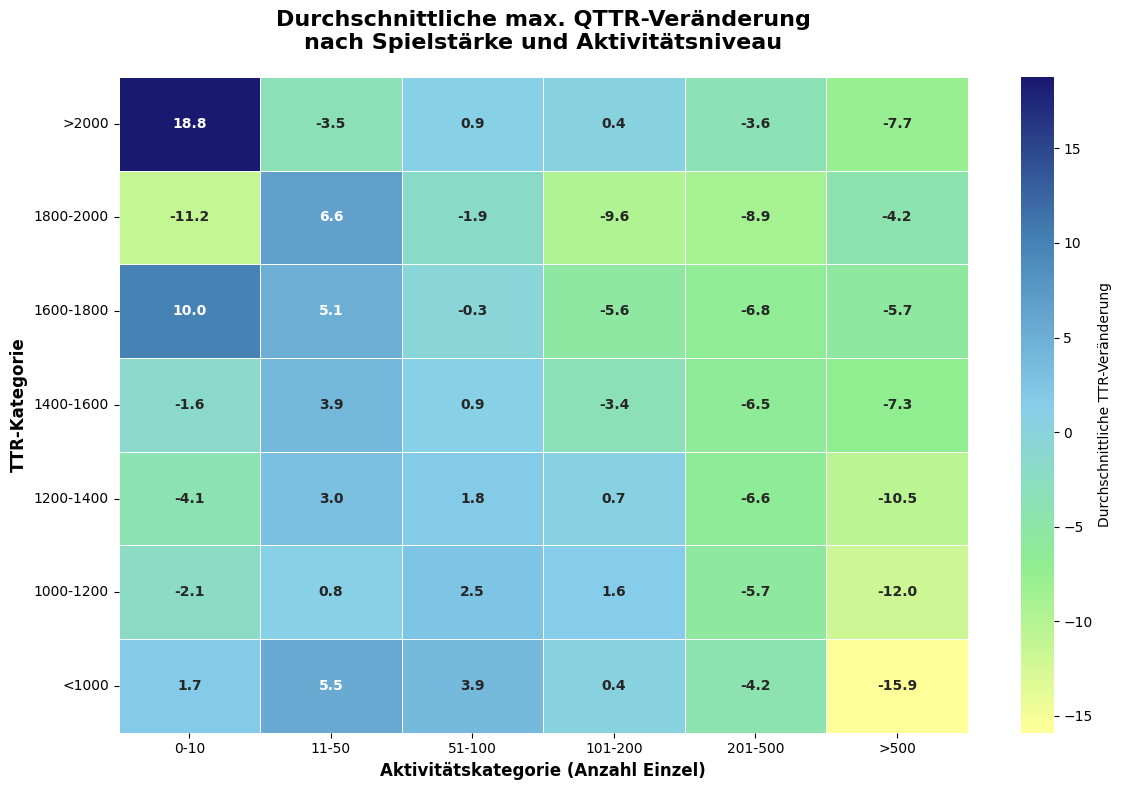

Regressionsanalyse gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer/regression_analysis_23_24.png


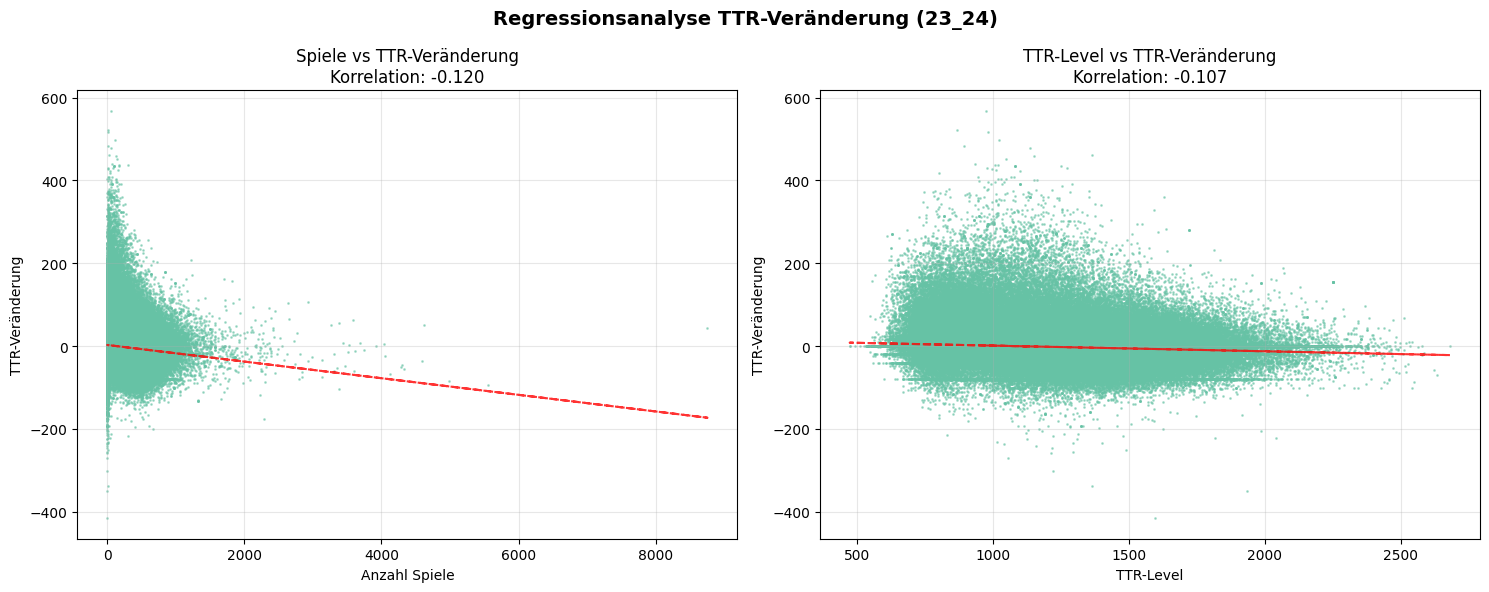


📊 Regressionsstatistiken für 23_24:
Korrelation Spiele ↔ TTR-Veränderung: -0.1199
Korrelation TTR-Level ↔ TTR-Veränderung: -0.1071
Anzahl Datenpunkte: 712,120
Heatmap gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer/heatmap_ttr_points_games_24_25.png


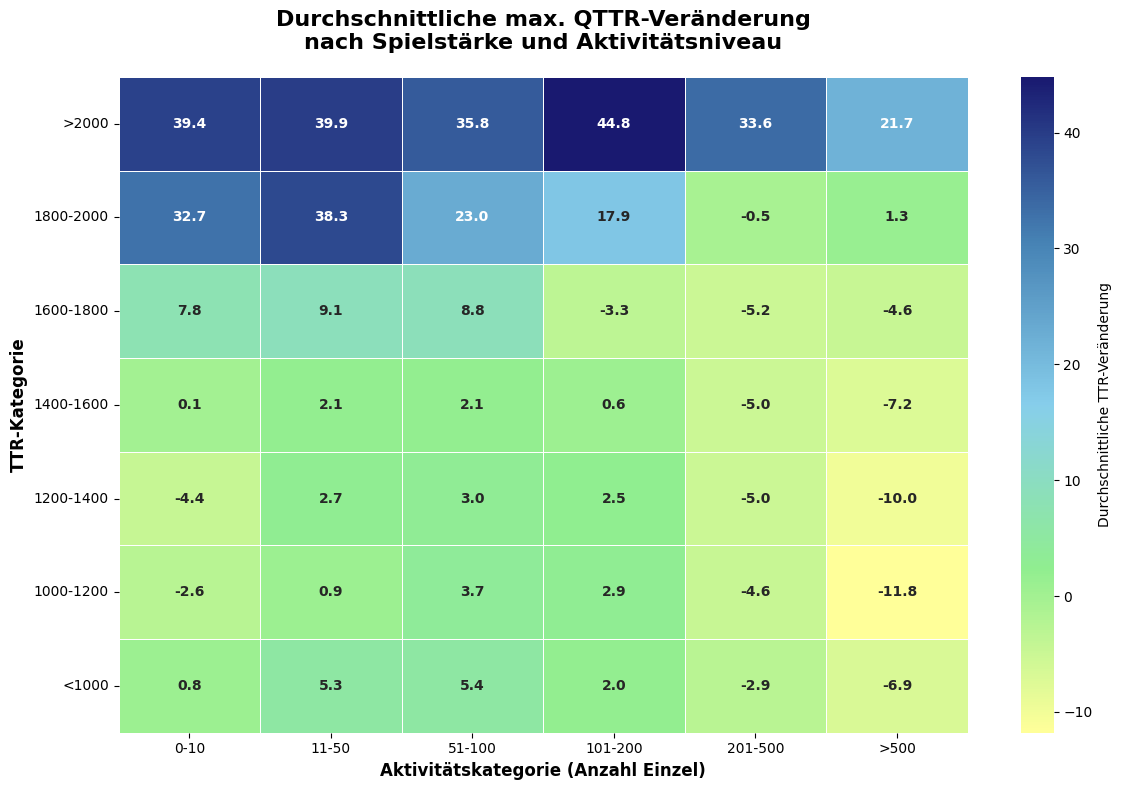

Regressionsanalyse gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer/regression_analysis_24_25.png


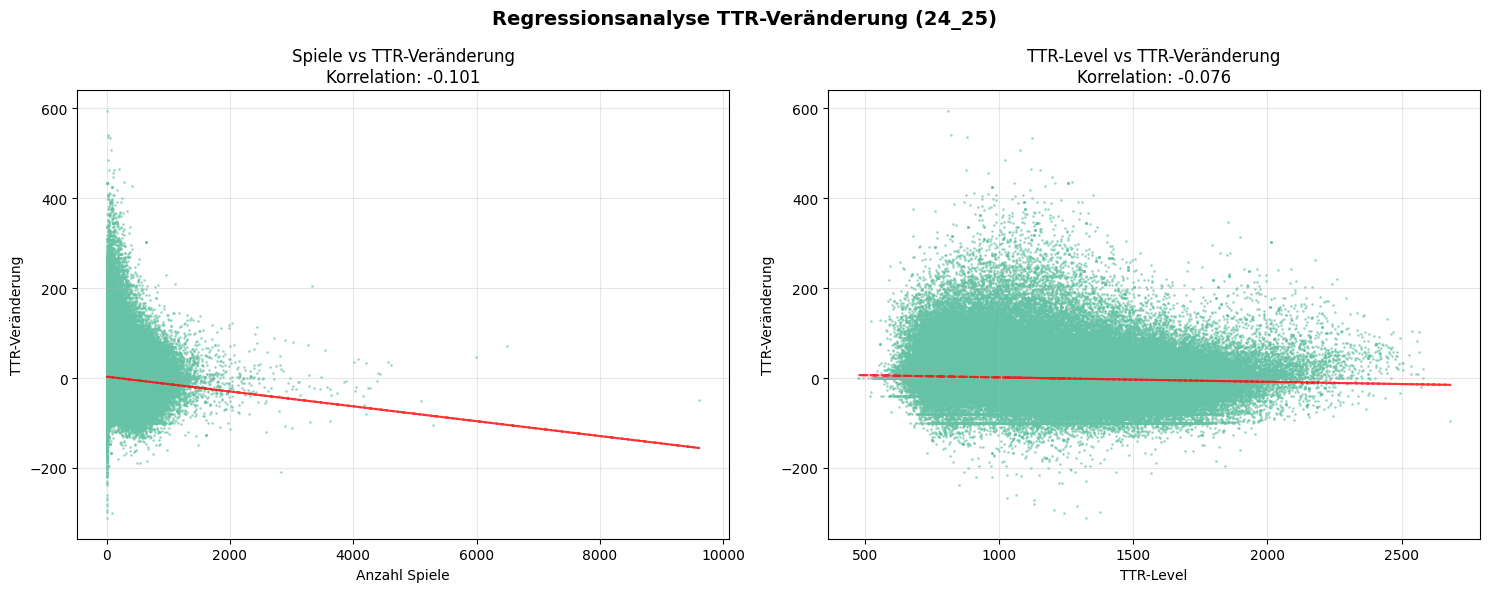


📊 Regressionsstatistiken für 24_25:
Korrelation Spiele ↔ TTR-Veränderung: -0.1014
Korrelation TTR-Level ↔ TTR-Veränderung: -0.0761
Anzahl Datenpunkte: 739,356
Alle Heatmaps erstellt in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer


In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import os

def create_ttr_heatmap_points_games(data, period_key, save_folder="visualisierungen"):
    """
    Erstellt Heatmap für TTR-Veränderungen nach Punktebereich und Spielehäufigkeit
    
    Parameters:
    data: DataFrame mit Spielerdaten
    period_key: '23_24' oder '24_25' für Jahresvergleiche
    save_folder: Ordner zum Speichern
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Zeitraum-Definitionen
    periods = {
        '23_24': {
            'title': 'Durchschnittliche max. QTTR-Veränderung\nnach Spielstärke und Aktivitätsniveau',
            'change_col': 'jahres_ttr_change_23_24',
            'spiele_col': 'Anzahl_Einzel_Q1_2023',
            'ttr_col': 'TTR_Q1_2023',
            'subtitle': 'Jahr 2023→2024'
        },
        '24_25': {
            'title': 'Durchschnittliche max. QTTR-Veränderung\nnach Spielstärke und Aktivitätsniveau', 
            'change_col': 'jahres_ttr_change_24_25',
            'spiele_col': 'Anzahl_Einzel_Q1_2024',
            'ttr_col': 'TTR_Q1_2024',
            'subtitle': 'Jahr 2024→2025'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    
    # Berechne TTR-Jahresveränderung falls nötig
    if period_key == '23_24':
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    elif period_key == '24_25':
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
    
    # Prüfe Spalten
    required_cols = [period_info['change_col'], period_info['spiele_col'], period_info['ttr_col']]
    for col in required_cols:
        if col not in data.columns:
            print(f"Warnung: Spalte {col} nicht gefunden!")
            return
    
    def categorize_ttr(ttr_value):
        """Kategorisiert TTR in Bereiche"""
        if pd.isna(ttr_value):
            return None
        elif ttr_value > 2000:
            return '>2000'
        elif ttr_value >= 1800:
            return '1800-2000'
        elif ttr_value >= 1600:
            return '1600-1800'
        elif ttr_value >= 1400:
            return '1400-1600'
        elif ttr_value >= 1200:
            return '1200-1400'
        elif ttr_value >= 1000:
            return '1000-1200'
        else:
            return '<1000'
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spiele in Bereiche"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl > 500:
            return '>500'
        elif spiele_anzahl >= 201:
            return '201-500'
        elif spiele_anzahl >= 101:
            return '101-200'
        elif spiele_anzahl >= 51:
            return '51-100'
        elif spiele_anzahl >= 11:
            return '11-50'
        else:
            return '0-10'
    
    # Erstelle Kategorien
    data['ttr_kategorie'] = data[period_info['ttr_col']].apply(categorize_ttr)
    data['spiele_kategorie'] = data[period_info['spiele_col']].apply(categorize_spiele)
    
    # Definiere Reihenfolgen
    ttr_order = ['>2000', '1800-2000', '1600-1800', '1400-1600', '1200-1400', '1000-1200', '<1000']
    spiele_order = ['0-10', '11-50', '51-100', '101-200', '201-500', '>500']
    
    # Filtere valide Daten
    valid_data = data[
        (data['ttr_kategorie'].notna()) & 
        (data['spiele_kategorie'].notna()) & 
        (data[period_info['change_col']].notna())
    ].copy()
    
    # Berechne durchschnittliche TTR-Veränderung für jede Kombination
    heatmap_data = valid_data.groupby(['ttr_kategorie', 'spiele_kategorie'])[period_info['change_col']].mean().unstack()
    
    # Reindexiere für richtige Reihenfolge
    heatmap_data = heatmap_data.reindex(index=ttr_order, columns=spiele_order)
    
    # Erstelle Heatmap
    plt.figure(figsize=(12, 8))
    
    # Verwende eine angepasste Farbpalette (Grün-Gelb-Blau)
    colors = ['#ffff99', '#90ee90', '#87ceeb', '#4682b4', '#191970']
    cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("custom", colors, N=256)
    
    # Erstelle Heatmap mit Annotationen
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='.1f',
                cmap=cmap,
                cbar_kws={'label': 'Durchschnittliche TTR-Veränderung'},
                linewidths=0.5,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    
    # Titel und Labels
    plt.title(period_info['title'], fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Aktivitätskategorie (Anzahl Einzel)', fontsize=12, fontweight='bold')
    plt.ylabel('TTR-Kategorie', fontsize=12, fontweight='bold')
    
    # Rotiere X-Achsen-Labels
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern
    save_path = os.path.join(save_folder, f"heatmap_ttr_points_games_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap gespeichert: {save_path}")
    
    plt.show()
    
    # Erstelle zusätzlich Regressionsanalyse
    create_regression_analysis(valid_data, period_info, period_key, save_folder)


def create_regression_analysis(data, period_info, period_key, save_folder):
    """
    Erstellt Regressionsanalyse für TTR-Veränderung vs. Spiele und TTR-Level
    """
    
    # Bereite numerische Daten vor
    spiele_col = period_info['spiele_col']
    ttr_col = period_info['ttr_col'] 
    change_col = period_info['change_col']
    
    # Entferne NaN-Werte
    reg_data = data[[spiele_col, ttr_col, change_col]].dropna()
    
    if len(reg_data) < 10:
        print("Zu wenige Daten für Regression!")
        return
    
    # Multiple lineare Regression
    X = reg_data[[spiele_col, ttr_col]]
    y = reg_data[change_col]
    
    # Berechne Korrelationen
    corr_spiele = reg_data[spiele_col].corr(reg_data[change_col])
    corr_ttr = reg_data[ttr_col].corr(reg_data[change_col])
    
    # Erstelle Scatter Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Spiele vs TTR-Veränderung
    ax1.scatter(reg_data[spiele_col], reg_data[change_col], alpha=0.5, s=1)
    z1 = np.polyfit(reg_data[spiele_col], reg_data[change_col], 1)
    p1 = np.poly1d(z1)
    ax1.plot(reg_data[spiele_col], p1(reg_data[spiele_col]), "r--", alpha=0.8)
    ax1.set_xlabel('Anzahl Spiele')
    ax1.set_ylabel('TTR-Veränderung')
    ax1.set_title(f'Spiele vs TTR-Veränderung\nKorrelation: {corr_spiele:.3f}')
    ax1.grid(True, alpha=0.3)
    
    # TTR vs TTR-Veränderung  
    ax2.scatter(reg_data[ttr_col], reg_data[change_col], alpha=0.5, s=1)
    z2 = np.polyfit(reg_data[ttr_col], reg_data[change_col], 1)
    p2 = np.poly1d(z2)
    ax2.plot(reg_data[ttr_col], p2(reg_data[ttr_col]), "r--", alpha=0.8)
    ax2.set_xlabel('TTR-Level')
    ax2.set_ylabel('TTR-Veränderung')
    ax2.set_title(f'TTR-Level vs TTR-Veränderung\nKorrelation: {corr_ttr:.3f}')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Regressionsanalyse TTR-Veränderung ({period_key})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Speichern
    save_path = os.path.join(save_folder, f"regression_analysis_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Regressionsanalyse gespeichert: {save_path}")
    
    plt.show()
    
    # Ausgabe Statistiken
    print(f"\n📊 Regressionsstatistiken für {period_key}:")
    print(f"Korrelation Spiele ↔ TTR-Veränderung: {corr_spiele:.4f}")
    print(f"Korrelation TTR-Level ↔ TTR-Veränderung: {corr_ttr:.4f}")
    print(f"Anzahl Datenpunkte: {len(reg_data):,}")


def create_all_heatmaps(data, save_folder="visualisierungen"):
    """
    Erstellt alle Heatmaps für beide Jahresvergleiche
    """
    
    print(f"Erstelle TTR-Heatmaps in Ordner: {save_folder}")
    
    # Erstelle Heatmaps für beide Zeiträume
    for period in ['23_24', '24_25']:
        create_ttr_heatmap_points_games(data, period, save_folder)
    
    print(f"Alle Heatmaps erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_ohne_ausland  # <-- DEINE DATENVARIABLE
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne Ausländer"
    
    print("Benötigte Spalten:")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024")
    print(f"\nErstelle Heatmaps in: {save_folder}")
    
    # Erstelle alle Heatmaps
    create_all_heatmaps(data, save_folder)

## Regression beide Parameter - ohne Ausländer

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import os

def create_comprehensive_regression_analysis(data, period_key, save_folder="/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5"):
    """
    Erstellt eine umfassende, präsentationsfähige Regressionsanalyse
    
    Parameters:
    data: DataFrame mit Spielerdaten
    period_key: '23_24' oder '24_25' für Jahresvergleiche
    save_folder: Ordner zum Speichern
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Zeitraum-Definitionen
    periods = {
        '23_24': {
            'title': 'Regressionsanalyse: TTR-Veränderung Jahr 2023→2024',
            'change_col': 'jahres_ttr_change_23_24',
            'spiele_col': 'Anzahl_Einzel_Q1_2023',
            'ttr_col': 'TTR_Q1_2023',
            'period_name': '2023→2024'
        },
        '24_25': {
            'title': 'Regressionsanalyse: TTR-Veränderung Jahr 2024→2025',
            'change_col': 'jahres_ttr_change_24_25',
            'spiele_col': 'Anzahl_Einzel_Q1_2024',
            'ttr_col': 'TTR_Q1_2024',
            'period_name': '2024→2025'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    
    # Berechne TTR-Jahresveränderung falls nötig
    if period_key == '23_24':
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    elif period_key == '24_25':
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
    
    # Bereite Daten vor
    spiele_col = period_info['spiele_col']
    ttr_col = period_info['ttr_col'] 
    change_col = period_info['change_col']
    
    # Filtere valide Daten
    reg_data = data[[spiele_col, ttr_col, change_col]].dropna().copy()
    
    if len(reg_data) < 100:
        print("Zu wenige Daten für aussagekräftige Regression!")
        return
    
    # Entferne extreme Outliers (99.5% Quantil)
    for col in [spiele_col, ttr_col, change_col]:
        q995 = reg_data[col].quantile(0.995)
        q005 = reg_data[col].quantile(0.005)
        reg_data = reg_data[(reg_data[col] >= q005) & (reg_data[col] <= q995)]
    
    print(f"📊 Regressionsanalyse für {period_info['period_name']}")
    print(f"Datenpunkte: {len(reg_data):,}")
    
    # === 1. HAUPTANALYSE: 4-Panel Figure ===
    fig = plt.figure(figsize=(20, 12))
    
    # Panel 1: Spiele vs TTR-Veränderung
    ax1 = plt.subplot(2, 3, 1)
    create_regression_plot(reg_data[spiele_col], reg_data[change_col], ax1,
                          'Anzahl Spiele', 'TTR-Veränderung', 
                          'Spieleaktivität vs. TTR-Entwicklung')
    
    # Panel 2: TTR-Level vs TTR-Veränderung
    ax2 = plt.subplot(2, 3, 2)
    create_regression_plot(reg_data[ttr_col], reg_data[change_col], ax2,
                          'TTR-Level', 'TTR-Veränderung',
                          'Spielstärke vs. TTR-Entwicklung')
    
    # Panel 3: Multiple Regression Visualisierung
    ax3 = plt.subplot(2, 3, 3)
    create_multiple_regression_plot(reg_data, spiele_col, ttr_col, change_col, ax3)
    
    # Panel 4: Residuenanalyse
    ax4 = plt.subplot(2, 3, 4)
    create_residual_analysis(reg_data, spiele_col, ttr_col, change_col, ax4)
    
    # Panel 5: Kategorische Analyse
    ax5 = plt.subplot(2, 3, 5)
    create_categorical_analysis(reg_data, spiele_col, ttr_col, change_col, ax5)
    
    # Panel 6: Statistik-Summary
    ax6 = plt.subplot(2, 3, 6)
    create_statistics_summary(reg_data, spiele_col, ttr_col, change_col, ax6, period_info['period_name'])
    
    plt.suptitle(period_info['title'], fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Speichern
    save_path = os.path.join(save_folder, f"comprehensive_regression_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Umfassende Regressionsanalyse gespeichert: {save_path}")
    plt.show()
    
    # === 2. DETAILLIERTE STATISTIKEN ===
    create_detailed_statistics_report(reg_data, spiele_col, ttr_col, change_col, 
                                    period_info['period_name'], save_folder, period_key)


def create_regression_plot(x, y, ax, xlabel, ylabel, title):
    """Erstellt einen einzelnen Regression Plot"""
    
    # Scatter Plot mit Transparenz
    ax.scatter(x, y, alpha=0.4, s=8, color='steelblue', edgecolors='none')
    
    # Regressionslinie
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "red", linewidth=2, alpha=0.8)
    
    # Konfidenzintervall
    def add_confidence_interval(x_vals, y_vals, ax):
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
        
        x_sorted = np.sort(x_vals)
        y_pred = slope * x_sorted + intercept
        
        # Berechne Standardfehler der Vorhersage
        n = len(x_vals)
        x_mean = np.mean(x_vals)
        ssx = np.sum((x_vals - x_mean) ** 2)
        s_err = np.sqrt(np.sum((y_vals - (slope * x_vals + intercept)) ** 2) / (n - 2))
        
        # 95% Konfidenzintervall
        t_val = 1.96  # Approximation für große Stichproben
        margin = t_val * s_err * np.sqrt(1/n + (x_sorted - x_mean)**2 / ssx)
        
        ax.fill_between(x_sorted, y_pred - margin, y_pred + margin, 
                       alpha=0.2, color='red', label='95% Konfidenzintervall')
    
    try:
        add_confidence_interval(x, y, ax)
    except:
        pass  # Falls Konfidenzintervall nicht berechnet werden kann
    
    # Statistiken
    correlation = np.corrcoef(x, y)[0,1]
    slope = z[0]
    
    # Labels und Titel
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    
    # Statistik-Text
    ax.text(0.05, 0.95, f'r = {correlation:.3f}\nSteigung = {slope:.3f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_multiple_regression_plot(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt Multiple Regression Visualisierung"""
    
    # Multiple lineare Regression
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    
    # Predicted vs Actual
    ax.scatter(y, y_pred, alpha=0.5, s=8, color='darkgreen')
    
    # Perfekte Linie
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'red', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Tatsächliche TTR-Veränderung', fontweight='bold')
    ax.set_ylabel('Vorhergesagte TTR-Veränderung', fontweight='bold')
    ax.set_title('Multiple Regression\n(Spiele + TTR-Level)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # R² anzeigen
    ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=12,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_residual_analysis(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt Residuenanalyse"""
    
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # Residuen vs Fitted Values
    ax.scatter(y_pred, residuals, alpha=0.5, s=8, color='purple')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    
    ax.set_xlabel('Vorhergesagte Werte', fontweight='bold')
    ax.set_ylabel('Residuen', fontweight='bold')
    ax.set_title('Residuenanalyse\n(Homoskedastizität)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Standardabweichung der Residuen
    std_residuals = np.std(residuals)
    ax.text(0.05, 0.95, f'Std. Residuen = {std_residuals:.2f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_categorical_analysis(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt kategorische Analyse"""
    
    # Erstelle Kategorien
    data_copy = data.copy()
    
    def categorize_players(row):
        spiele = row[spiele_col]
        ttr = row[ttr_col]
        
        if spiele <= 50 and ttr <= 1400:
            return 'Gelegenheit\n≤1400 TTR'
        elif spiele <= 50 and ttr > 1400:
            return 'Gelegenheit\n>1400 TTR'
        elif spiele <= 200 and ttr <= 1400:
            return 'Aktiv\n≤1400 TTR'
        elif spiele <= 200 and ttr > 1400:
            return 'Aktiv\n>1400 TTR'
        elif ttr <= 1400:
            return 'Intensiv\n≤1400 TTR'
        else:
            return 'Intensiv\n>1400 TTR'
    
    data_copy['kategorie'] = data_copy.apply(categorize_players, axis=1)
    
    # Boxplot
    categories = data_copy['kategorie'].unique()
    box_data = [data_copy[data_copy['kategorie'] == cat][change_col] for cat in categories]
    
    bp = ax.boxplot(box_data, labels=categories, patch_artist=True)
    
    # Färbe Boxen
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('TTR-Veränderung', fontweight='bold')
    ax.set_title('TTR-Veränderung nach\nSpieler-Kategorien', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


def create_statistics_summary(data, spiele_col, ttr_col, change_col, ax, period_name):
    """Erstellt Statistik-Zusammenfassung"""
    
    ax.axis('off')  # Keine Achsen
    
    # Berechne umfassende Statistiken
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    # Einfache Korrelationen
    corr_spiele = data[spiele_col].corr(data[change_col])
    corr_ttr = data[ttr_col].corr(data[change_col])
    
    # Multiple Regression
    model = LinearRegression()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))
    mse = mean_squared_error(y, model.predict(X))
    
    # Koeffizienten
    coef_spiele = model.coef_[0]
    coef_ttr = model.coef_[1]
    intercept = model.intercept_
    
    # Deskriptive Statistiken
    n_players = len(data)
    mean_change = data[change_col].mean()
    std_change = data[change_col].std()
    
    # Text zusammenstellen
    stats_text = f"""
    REGRESSIONSSTATISTIKEN {period_name}
    
    📊 Datenübersicht:
    • Anzahl Spieler: {n_players:,}
    • Ø TTR-Veränderung: {mean_change:+.1f} ± {std_change:.1f}
    
    🔗 Korrelationen:
    • Spiele ↔ TTR-Veränderung: {corr_spiele:.3f}
    • TTR-Level ↔ TTR-Veränderung: {corr_ttr:.3f}
    
    📈 Multiple Regression:
    • R² (Bestimmtheitsmaß): {r2:.3f}
    • RMSE: {np.sqrt(mse):.2f}
    
    🧮 Regressionsgleichung:
    TTR-Änderung = {intercept:.2f} 
                   {coef_spiele:+.4f} × Spiele
                   {coef_ttr:+.4f} × TTR-Level
    
    💡 Interpretation:
    • +1 Spiel → {coef_spiele:+.3f} TTR-Punkte
    • +100 TTR → {coef_ttr*100:+.1f} TTR-Punkte zusätzlich
    """
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.1))


def create_detailed_statistics_report(data, spiele_col, ttr_col, change_col, period_name, save_folder, period_key):
    """Erstellt detaillierten Statistikbericht"""
    
    # Berechne erweiterte Statistiken
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Weitere Metriken
    from scipy.stats import pearsonr
    
    # Partial correlations (vereinfacht)
    corr_matrix = data[[spiele_col, ttr_col, change_col]].corr()
    
    # Erstelle Report
    report = f"""
    ═══════════════════════════════════════════════════════════
                    DETAILLIERTE REGRESSIONSANALYSE
                            {period_name}
    ═══════════════════════════════════════════════════════════
    
    📊 DATENÜBERSICHT:
    ▪ Gesamte Stichprobe: {len(data):,} Spieler
    ▪ TTR-Veränderung: μ = {y.mean():+.2f}, σ = {y.std():.2f}
    ▪ Spieleanzahl: μ = {data[spiele_col].mean():.1f}, σ = {data[spiele_col].std():.1f}
    ▪ TTR-Level: μ = {data[ttr_col].mean():.0f}, σ = {data[ttr_col].std():.0f}
    
    🔗 KORRELATIONSMATRIX:
    ▪ Spiele ↔ TTR-Veränderung: r = {corr_matrix.loc[spiele_col, change_col]:.4f}
    ▪ TTR ↔ TTR-Veränderung: r = {corr_matrix.loc[ttr_col, change_col]:.4f}
    ▪ Spiele ↔ TTR-Level: r = {corr_matrix.loc[spiele_col, ttr_col]:.4f}
    
    📈 MULTIPLE REGRESSION:
    ▪ R² = {r2_score(y, y_pred):.4f} ({r2_score(y, y_pred)*100:.1f}% erklärte Varianz)
    ▪ Adj. R² ≈ {1 - (1-r2_score(y, y_pred))*(len(y)-1)/(len(y)-X.shape[1]-1):.4f}
    ▪ RMSE = {np.sqrt(mean_squared_error(y, y_pred)):.3f}
    ▪ F-Statistik: {((r2_score(y, y_pred)/(1-r2_score(y, y_pred))) * ((len(y)-X.shape[1]-1)/X.shape[1])):.2f}
    
    🧮 REGRESSIONSKOEFFIZIENTEN:
    ▪ Konstante (Intercept): {model.intercept_:.4f}
    ▪ Spiele-Koeffizient: {model.coef_[0]:.6f}
    ▪ TTR-Koeffizient: {model.coef_[1]:.6f}
    
    💡 PRAKTISCHE INTERPRETATION:
    ▪ Pro zusätzlichem Spiel: {model.coef_[0]:+.4f} TTR-Punkte Veränderung
    ▪ Pro 100 TTR-Punkte höher: {model.coef_[1]*100:+.2f} TTR-Punkte Veränderung
    ▪ Ein Spieler mit 1400 TTR und 100 Spielen: {model.intercept_ + model.coef_[0]*100 + model.coef_[1]*1400:+.1f} TTR Veränderung
    
    📊 MODELLGÜTE:
    ▪ Modell erklärt {r2_score(y, y_pred)*100:.1f}% der Varianz in TTR-Veränderungen
    ▪ Verbleibende Standardabweichung: {np.sqrt(mean_squared_error(y, y_pred)):.2f} TTR-Punkte
    
    ═══════════════════════════════════════════════════════════
    """
    
    # Speichere Report
    report_path = os.path.join(save_folder, f"regression_report_{period_key}.txt")
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
    
    print(f"📄 Detaillierter Report gespeichert: {report_path}")
    print(report)


def create_all_comprehensive_regressions(data, save_folder="visualisierungen"):
    """
    Erstellt alle umfassenden Regressionsanalysen
    """
    
    print(f"Erstelle umfassende Regressionsanalysen in Ordner: {save_folder}")
    
    # Erstelle für beide Zeiträume
    for period in ['23_24', '24_25']:
        create_comprehensive_regression_analysis(data, period, save_folder)
    
    print(f"Alle Regressionsanalysen erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_ohne_ausland  # <-- DEINE DATENVARIABLE
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_ohne_Ausländer"
    
    print("Benötigte Spalten:")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024")
    print(f"\nErstelle umfassende Regressionsanalysen in: {save_folder}")
    
    # Erstelle alle Analysen
    create_all_comprehensive_regressions(data, save_folder)

## Kombination der beiden Parameter - Top 5

Benötigte Spalten:
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024

Erstelle Heatmaps in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5
Erstelle TTR-Heatmaps in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5
Heatmap gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/heatmap_ttr_points_games_23_24.png


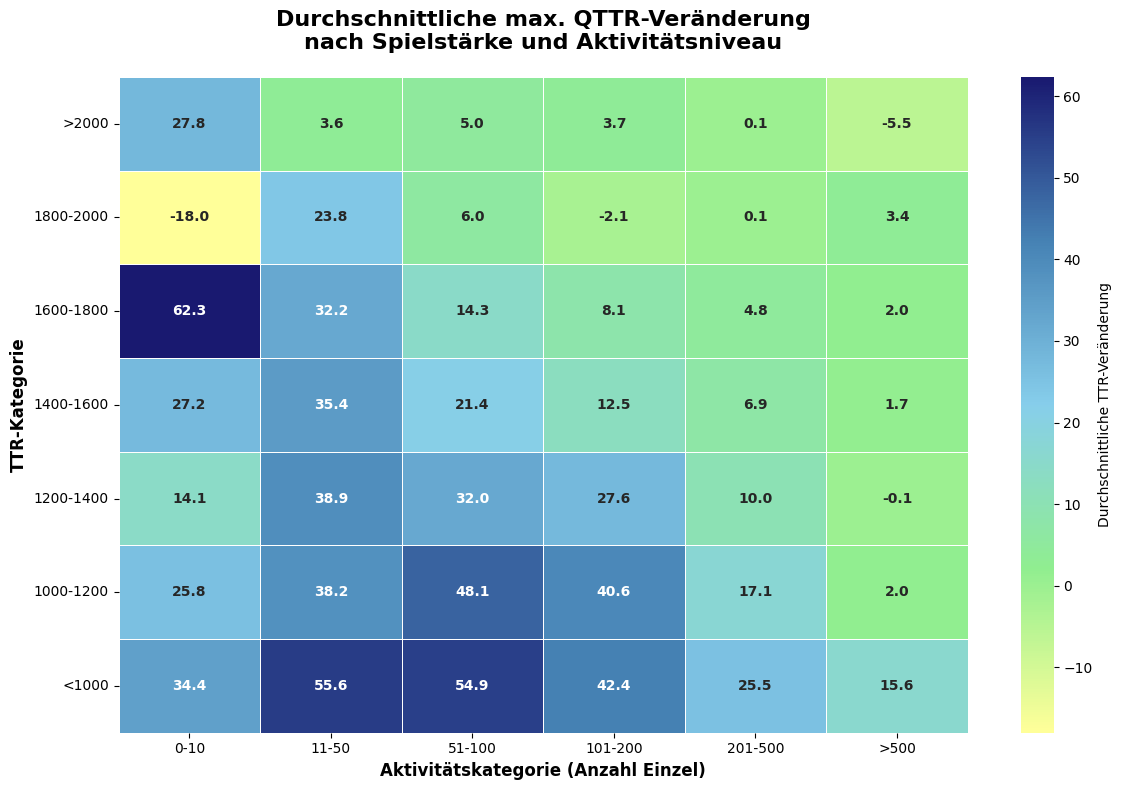

Regressionsanalyse gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/regression_analysis_23_24.png


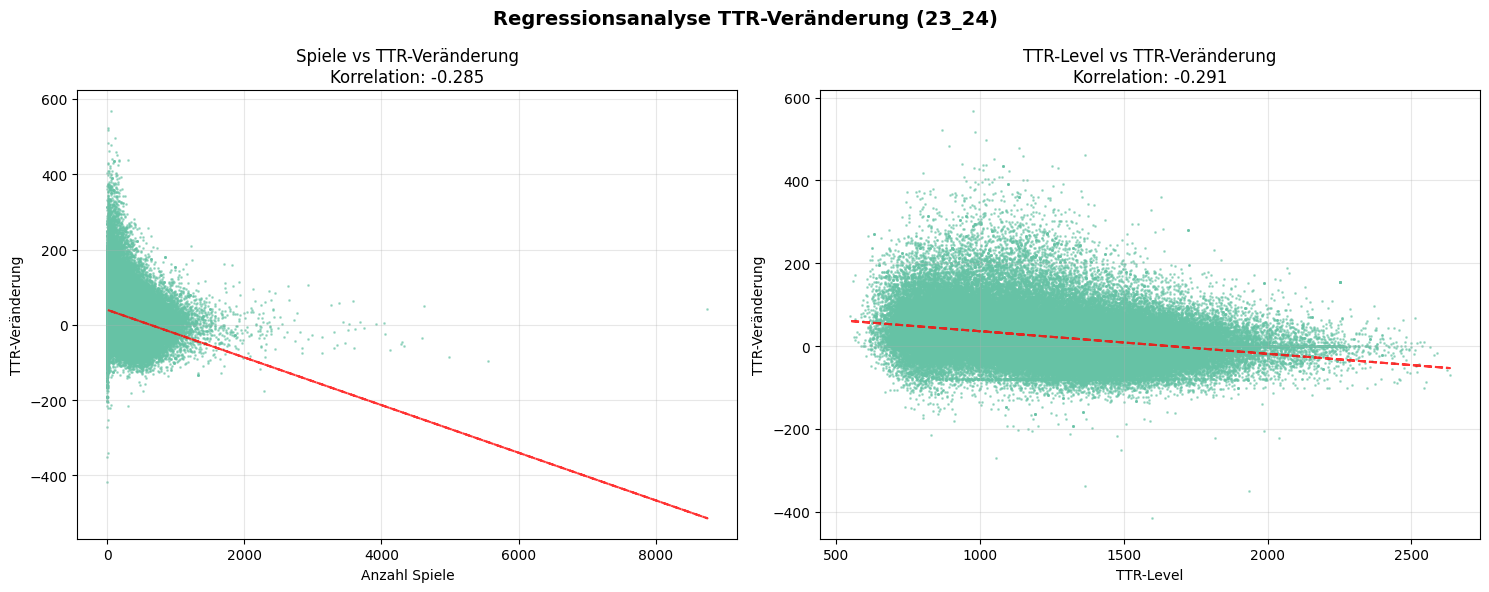


📊 Regressionsstatistiken für 23_24:
Korrelation Spiele ↔ TTR-Veränderung: -0.2852
Korrelation TTR-Level ↔ TTR-Veränderung: -0.2909
Anzahl Datenpunkte: 141,915
Heatmap gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/heatmap_ttr_points_games_24_25.png


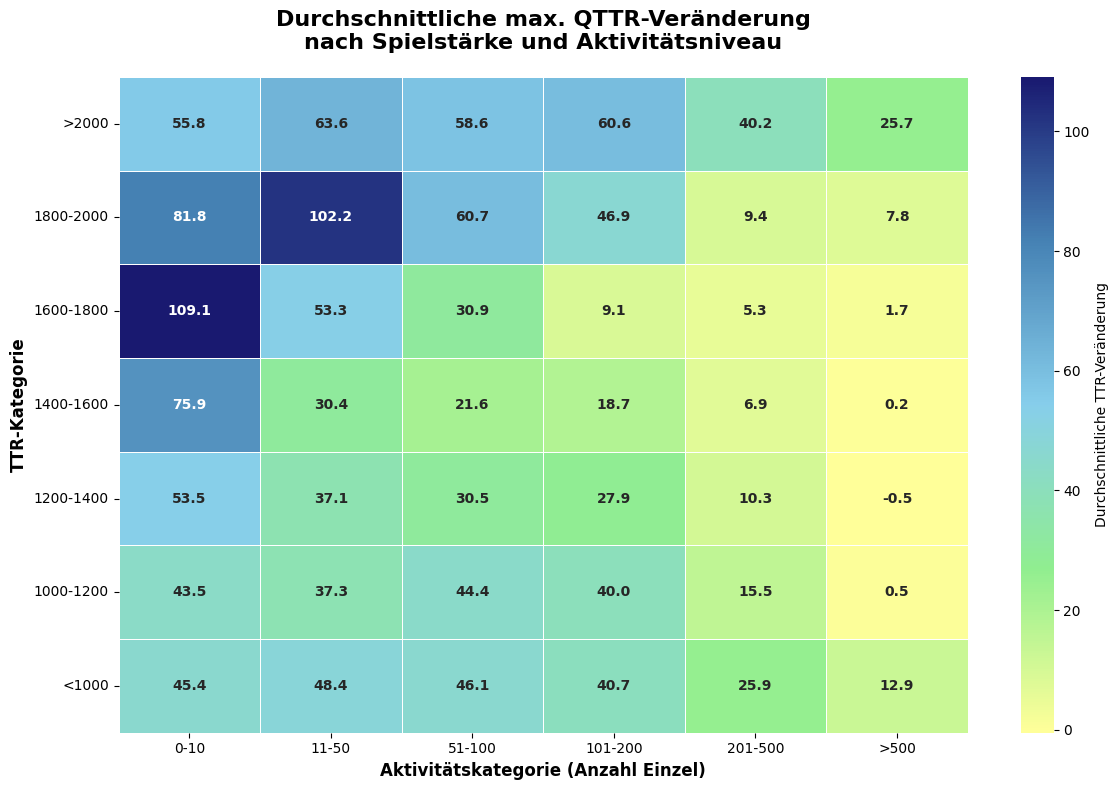

Regressionsanalyse gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/regression_analysis_24_25.png


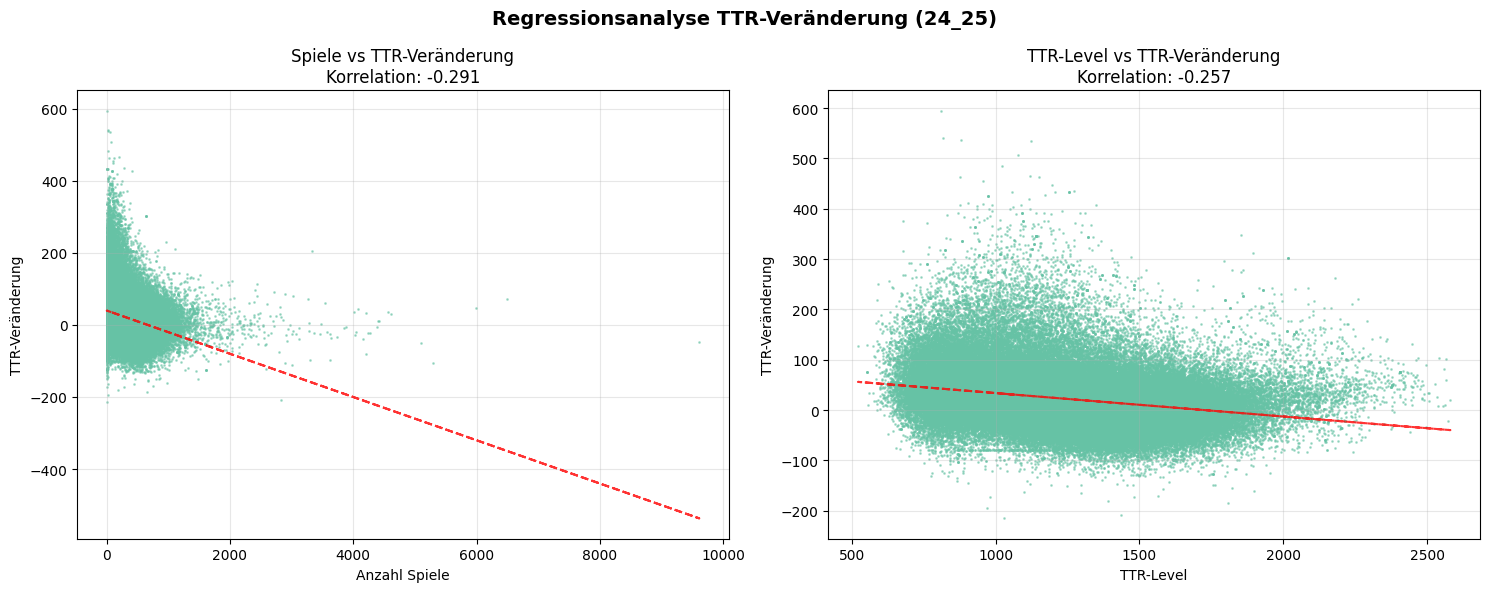


📊 Regressionsstatistiken für 24_25:
Korrelation Spiele ↔ TTR-Veränderung: -0.2913
Korrelation TTR-Level ↔ TTR-Veränderung: -0.2570
Anzahl Datenpunkte: 156,737
Alle Heatmaps erstellt in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5


In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import os

def create_ttr_heatmap_points_games(data, period_key, save_folder="visualisierungen"):
    """
    Erstellt Heatmap für TTR-Veränderungen nach Punktebereich und Spielehäufigkeit
    
    Parameters:
    data: DataFrame mit Spielerdaten
    period_key: '23_24' oder '24_25' für Jahresvergleiche
    save_folder: Ordner zum Speichern
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Zeitraum-Definitionen
    periods = {
        '23_24': {
            'title': 'Durchschnittliche max. QTTR-Veränderung\nnach Spielstärke und Aktivitätsniveau',
            'change_col': 'jahres_ttr_change_23_24',
            'spiele_col': 'Anzahl_Einzel_Q1_2023',
            'ttr_col': 'TTR_Q1_2023',
            'subtitle': 'Jahr 2023→2024'
        },
        '24_25': {
            'title': 'Durchschnittliche max. QTTR-Veränderung\nnach Spielstärke und Aktivitätsniveau', 
            'change_col': 'jahres_ttr_change_24_25',
            'spiele_col': 'Anzahl_Einzel_Q1_2024',
            'ttr_col': 'TTR_Q1_2024',
            'subtitle': 'Jahr 2024→2025'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    
    # Berechne TTR-Jahresveränderung falls nötig
    if period_key == '23_24':
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    elif period_key == '24_25':
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
    
    # Prüfe Spalten
    required_cols = [period_info['change_col'], period_info['spiele_col'], period_info['ttr_col']]
    for col in required_cols:
        if col not in data.columns:
            print(f"Warnung: Spalte {col} nicht gefunden!")
            return
    
    def categorize_ttr(ttr_value):
        """Kategorisiert TTR in Bereiche"""
        if pd.isna(ttr_value):
            return None
        elif ttr_value > 2000:
            return '>2000'
        elif ttr_value >= 1800:
            return '1800-2000'
        elif ttr_value >= 1600:
            return '1600-1800'
        elif ttr_value >= 1400:
            return '1400-1600'
        elif ttr_value >= 1200:
            return '1200-1400'
        elif ttr_value >= 1000:
            return '1000-1200'
        else:
            return '<1000'
    
    def categorize_spiele(spiele_anzahl):
        """Kategorisiert Spiele in Bereiche"""
        if pd.isna(spiele_anzahl):
            return None
        elif spiele_anzahl > 500:
            return '>500'
        elif spiele_anzahl >= 201:
            return '201-500'
        elif spiele_anzahl >= 101:
            return '101-200'
        elif spiele_anzahl >= 51:
            return '51-100'
        elif spiele_anzahl >= 11:
            return '11-50'
        else:
            return '0-10'
    
    # Erstelle Kategorien
    data['ttr_kategorie'] = data[period_info['ttr_col']].apply(categorize_ttr)
    data['spiele_kategorie'] = data[period_info['spiele_col']].apply(categorize_spiele)
    
    # Definiere Reihenfolgen
    ttr_order = ['>2000', '1800-2000', '1600-1800', '1400-1600', '1200-1400', '1000-1200', '<1000']
    spiele_order = ['0-10', '11-50', '51-100', '101-200', '201-500', '>500']
    
    # Filtere valide Daten
    valid_data = data[
        (data['ttr_kategorie'].notna()) & 
        (data['spiele_kategorie'].notna()) & 
        (data[period_info['change_col']].notna())
    ].copy()
    
    # Berechne durchschnittliche TTR-Veränderung für jede Kombination
    heatmap_data = valid_data.groupby(['ttr_kategorie', 'spiele_kategorie'])[period_info['change_col']].mean().unstack()
    
    # Reindexiere für richtige Reihenfolge
    heatmap_data = heatmap_data.reindex(index=ttr_order, columns=spiele_order)
    
    # Erstelle Heatmap
    plt.figure(figsize=(12, 8))
    
    # Verwende eine angepasste Farbpalette (Grün-Gelb-Blau)
    colors = ['#ffff99', '#90ee90', '#87ceeb', '#4682b4', '#191970']
    cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("custom", colors, N=256)
    
    # Erstelle Heatmap mit Annotationen
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='.1f',
                cmap=cmap,
                cbar_kws={'label': 'Durchschnittliche TTR-Veränderung'},
                linewidths=0.5,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    
    # Titel und Labels
    plt.title(period_info['title'], fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Aktivitätskategorie (Anzahl Einzel)', fontsize=12, fontweight='bold')
    plt.ylabel('TTR-Kategorie', fontsize=12, fontweight='bold')
    
    # Rotiere X-Achsen-Labels
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    
    # Layout optimieren
    plt.tight_layout()
    
    # Speichern
    save_path = os.path.join(save_folder, f"heatmap_ttr_points_games_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap gespeichert: {save_path}")
    
    plt.show()
    
    # Erstelle zusätzlich Regressionsanalyse
    create_regression_analysis(valid_data, period_info, period_key, save_folder)


def create_regression_analysis(data, period_info, period_key, save_folder):
    """
    Erstellt Regressionsanalyse für TTR-Veränderung vs. Spiele und TTR-Level
    """
    
    # Bereite numerische Daten vor
    spiele_col = period_info['spiele_col']
    ttr_col = period_info['ttr_col'] 
    change_col = period_info['change_col']
    
    # Entferne NaN-Werte
    reg_data = data[[spiele_col, ttr_col, change_col]].dropna()
    
    if len(reg_data) < 10:
        print("Zu wenige Daten für Regression!")
        return
    
    # Multiple lineare Regression
    X = reg_data[[spiele_col, ttr_col]]
    y = reg_data[change_col]
    
    # Berechne Korrelationen
    corr_spiele = reg_data[spiele_col].corr(reg_data[change_col])
    corr_ttr = reg_data[ttr_col].corr(reg_data[change_col])
    
    # Erstelle Scatter Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Spiele vs TTR-Veränderung
    ax1.scatter(reg_data[spiele_col], reg_data[change_col], alpha=0.5, s=1)
    z1 = np.polyfit(reg_data[spiele_col], reg_data[change_col], 1)
    p1 = np.poly1d(z1)
    ax1.plot(reg_data[spiele_col], p1(reg_data[spiele_col]), "r--", alpha=0.8)
    ax1.set_xlabel('Anzahl Spiele')
    ax1.set_ylabel('TTR-Veränderung')
    ax1.set_title(f'Spiele vs TTR-Veränderung\nKorrelation: {corr_spiele:.3f}')
    ax1.grid(True, alpha=0.3)
    
    # TTR vs TTR-Veränderung  
    ax2.scatter(reg_data[ttr_col], reg_data[change_col], alpha=0.5, s=1)
    z2 = np.polyfit(reg_data[ttr_col], reg_data[change_col], 1)
    p2 = np.poly1d(z2)
    ax2.plot(reg_data[ttr_col], p2(reg_data[ttr_col]), "r--", alpha=0.8)
    ax2.set_xlabel('TTR-Level')
    ax2.set_ylabel('TTR-Veränderung')
    ax2.set_title(f'TTR-Level vs TTR-Veränderung\nKorrelation: {corr_ttr:.3f}')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Regressionsanalyse TTR-Veränderung ({period_key})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Speichern
    save_path = os.path.join(save_folder, f"regression_analysis_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Regressionsanalyse gespeichert: {save_path}")
    
    plt.show()
    
    # Ausgabe Statistiken
    print(f"\n📊 Regressionsstatistiken für {period_key}:")
    print(f"Korrelation Spiele ↔ TTR-Veränderung: {corr_spiele:.4f}")
    print(f"Korrelation TTR-Level ↔ TTR-Veränderung: {corr_ttr:.4f}")
    print(f"Anzahl Datenpunkte: {len(reg_data):,}")


def create_all_heatmaps(data, save_folder="visualisierungen"):
    """
    Erstellt alle Heatmaps für beide Jahresvergleiche
    """
    
    print(f"Erstelle TTR-Heatmaps in Ordner: {save_folder}")
    
    # Erstelle Heatmaps für beide Zeiträume
    for period in ['23_24', '24_25']:
        create_ttr_heatmap_points_games(data, period, save_folder)
    
    print(f"Alle Heatmaps erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_top_5_positiv  # <-- DEINE DATENVARIABLE
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5"
    
    print("Benötigte Spalten:")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024")
    print(f"\nErstelle Heatmaps in: {save_folder}")
    
    # Erstelle alle Heatmaps
    create_all_heatmaps(data, save_folder)

## Regression beide Parameter - Top 5

Benötigte Spalten:
- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025
- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024

Erstelle umfassende Regressionsanalysen in: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5
Erstelle umfassende Regressionsanalysen in Ordner: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5
📊 Regressionsanalyse für 2023→2024
Datenpunkte: 138,160
Umfassende Regressionsanalyse gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/comprehensive_regression_23_24.png


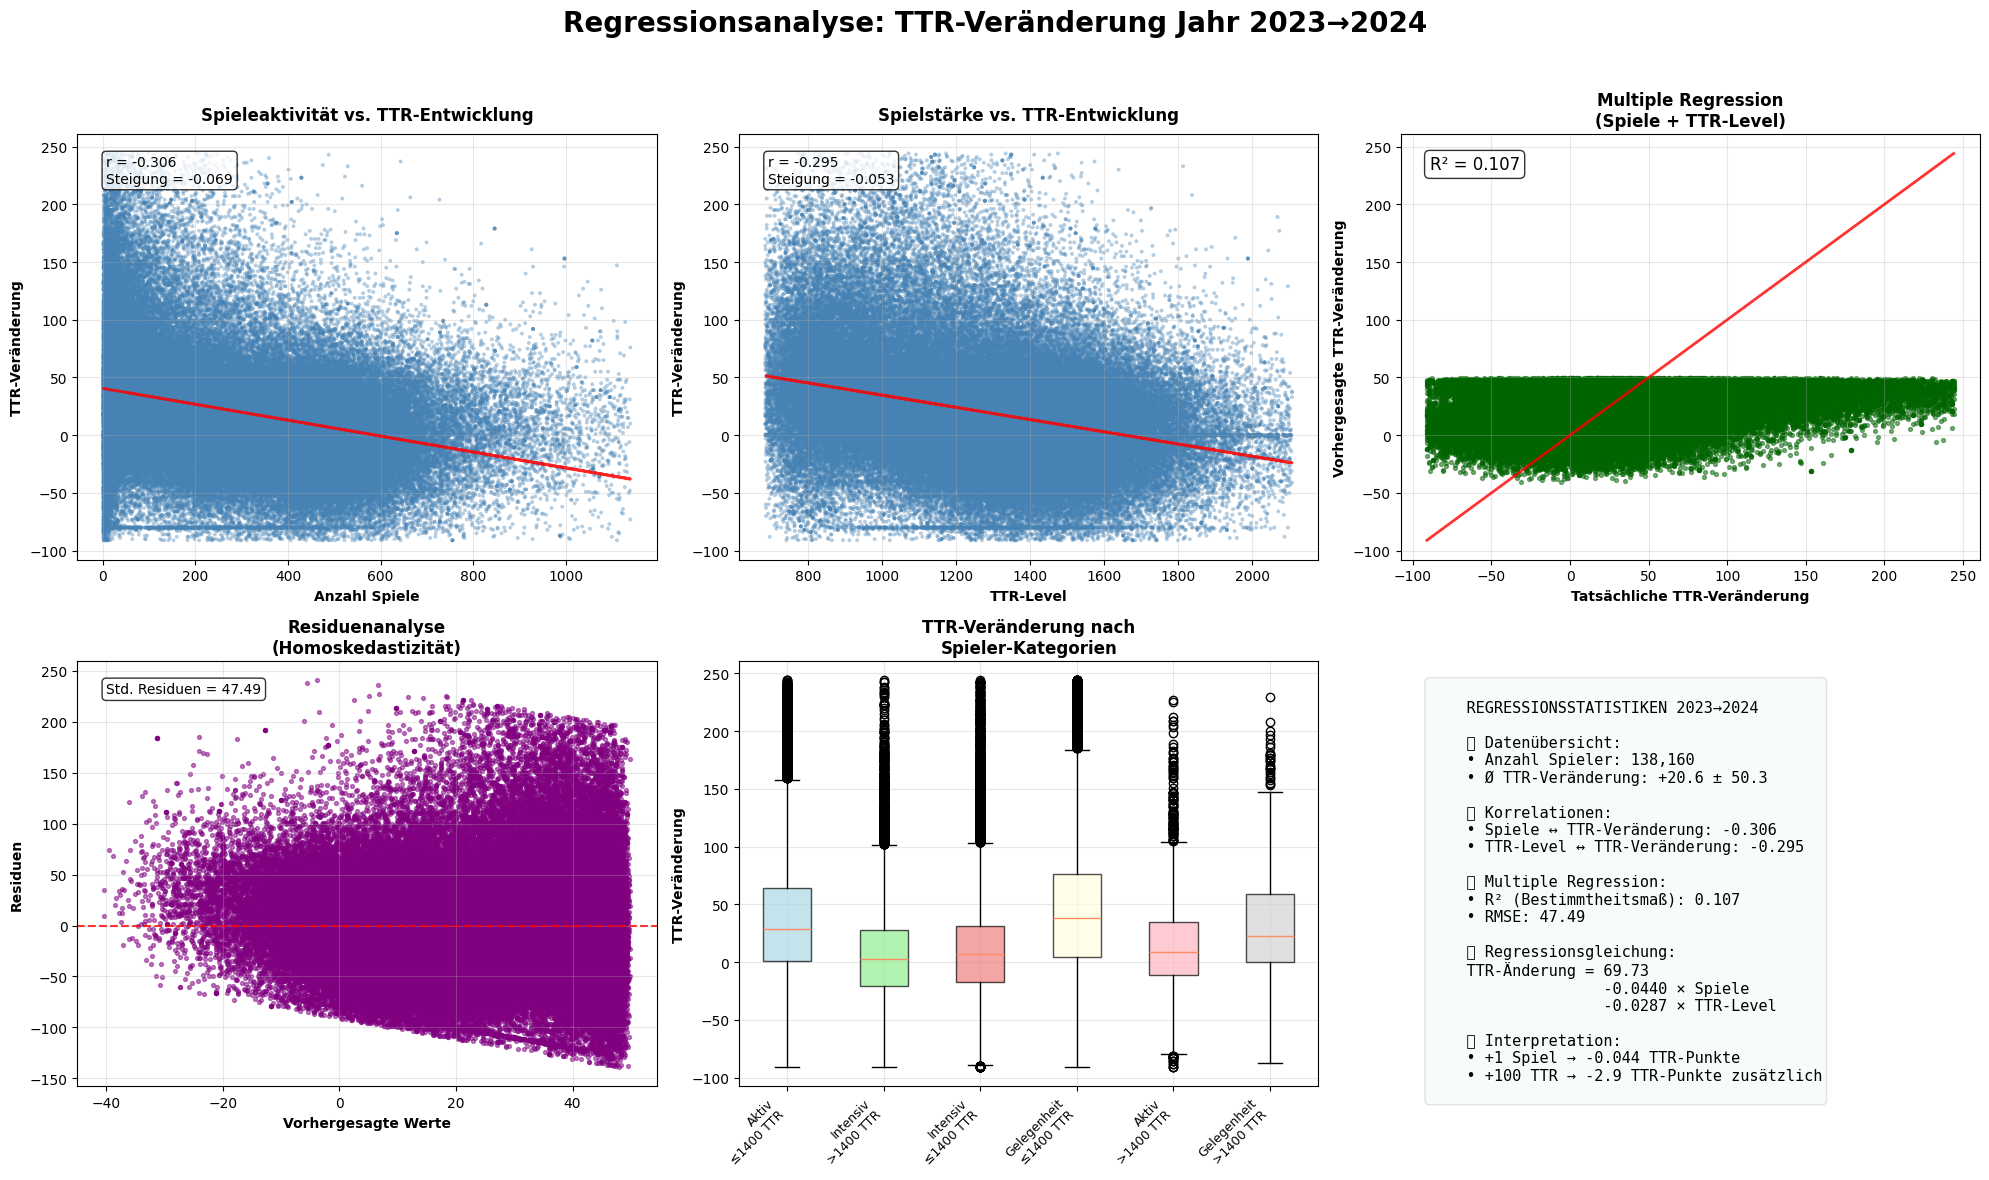

📄 Detaillierter Report gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/regression_report_23_24.txt

    ═══════════════════════════════════════════════════════════
                    DETAILLIERTE REGRESSIONSANALYSE
                            2023→2024
    ═══════════════════════════════════════════════════════════
    
    📊 DATENÜBERSICHT:
    ▪ Gesamte Stichprobe: 138,160 Spieler
    ▪ TTR-Veränderung: μ = +20.62, σ = 50.26
    ▪ Spieleanzahl: μ = 289.7, σ = 223.6
    ▪ TTR-Level: μ = 1266, σ = 280
    
    🔗 KORRELATIONSMATRIX:
    ▪ Spiele ↔ TTR-Veränderung: r = -0.3064
    ▪ TTR ↔ TTR-Veränderung: r = -0.2953
    ▪ Spiele ↔ TTR-Level: r = 0.6903
    
    📈 MULTIPLE REGRESSION:
    ▪ R² = 0.1073 (10.7% erklärte Varianz)
    ▪ Adj. R² ≈ 0.1073
    ▪ RMSE = 47.488
    ▪ F-Statistik: 8303.11
    
    🧮 REGRESSIONSKOEFFIZIENTEN:
    ▪ Konstante (Intercept): 69.7326
    ▪ Spiele-Koeff

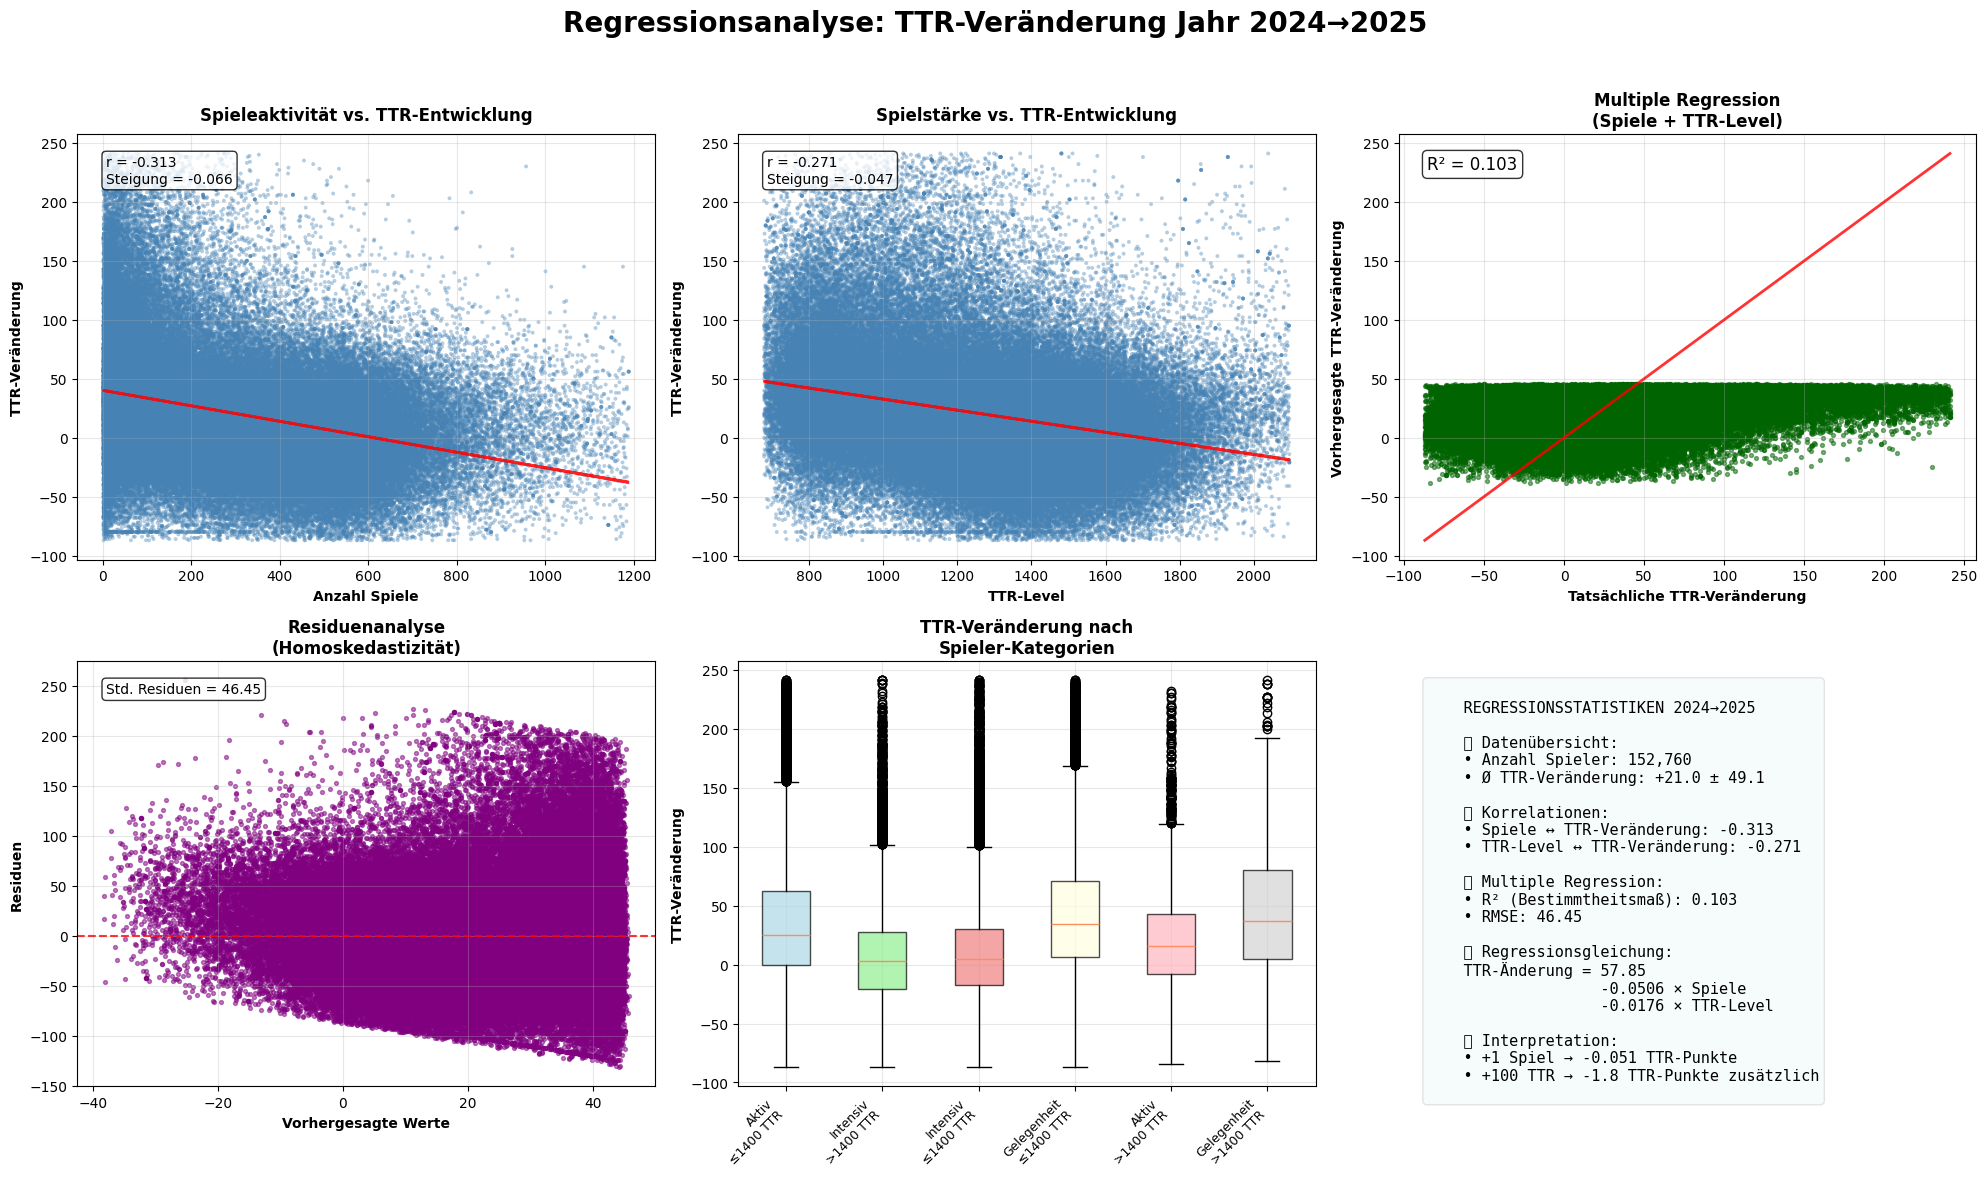

📄 Detaillierter Report gespeichert: /Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5/regression_report_24_25.txt

    ═══════════════════════════════════════════════════════════
                    DETAILLIERTE REGRESSIONSANALYSE
                            2024→2025
    ═══════════════════════════════════════════════════════════
    
    📊 DATENÜBERSICHT:
    ▪ Gesamte Stichprobe: 152,760 Spieler
    ▪ TTR-Veränderung: μ = +20.95, σ = 49.05
    ▪ Spieleanzahl: μ = 293.0, σ = 234.0
    ▪ TTR-Level: μ = 1251, σ = 284
    
    🔗 KORRELATIONSMATRIX:
    ▪ Spiele ↔ TTR-Veränderung: r = -0.3130
    ▪ TTR ↔ TTR-Veränderung: r = -0.2715
    ▪ Spiele ↔ TTR-Level: r = 0.7016
    
    📈 MULTIPLE REGRESSION:
    ▪ R² = 0.1033 (10.3% erklärte Varianz)
    ▪ Adj. R² ≈ 0.1032
    ▪ RMSE = 46.450
    ▪ F-Statistik: 8795.01
    
    🧮 REGRESSIONSKOEFFIZIENTEN:
    ▪ Konstante (Intercept): 57.8456
    ▪ Spiele-Koeff

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import os

def create_comprehensive_regression_analysis(data, period_key, save_folder="/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5"):
    """
    Erstellt eine umfassende, präsentationsfähige Regressionsanalyse
    
    Parameters:
    data: DataFrame mit Spielerdaten
    period_key: '23_24' oder '24_25' für Jahresvergleiche
    save_folder: Ordner zum Speichern
    """
    
    # Erstelle Ordner falls nicht vorhanden
    os.makedirs(save_folder, exist_ok=True)
    
    # Zeitraum-Definitionen
    periods = {
        '23_24': {
            'title': 'Regressionsanalyse: TTR-Veränderung Jahr 2023→2024',
            'change_col': 'jahres_ttr_change_23_24',
            'spiele_col': 'Anzahl_Einzel_Q1_2023',
            'ttr_col': 'TTR_Q1_2023',
            'period_name': '2023→2024'
        },
        '24_25': {
            'title': 'Regressionsanalyse: TTR-Veränderung Jahr 2024→2025',
            'change_col': 'jahres_ttr_change_24_25',
            'spiele_col': 'Anzahl_Einzel_Q1_2024',
            'ttr_col': 'TTR_Q1_2024',
            'period_name': '2024→2025'
        }
    }
    
    if period_key not in periods:
        print(f"Unbekannter Zeitraum: {period_key}")
        return
    
    period_info = periods[period_key]
    
    # Berechne TTR-Jahresveränderung falls nötig
    if period_key == '23_24':
        if 'TTR_Q1_2023' in data.columns and 'TTR_Q1_2024' in data.columns:
            data['jahres_ttr_change_23_24'] = data['TTR_Q1_2024'] - data['TTR_Q1_2023']
        else:
            print("Warnung: TTR_Q1_2023 oder TTR_Q1_2024 Spalten nicht gefunden!")
            return
    elif period_key == '24_25':
        if 'TTR_Q1_2024' in data.columns and 'TTR_Q1_2025' in data.columns:
            data['jahres_ttr_change_24_25'] = data['TTR_Q1_2025'] - data['TTR_Q1_2024']
        else:
            print("Warnung: TTR_Q1_2024 oder TTR_Q1_2025 Spalten nicht gefunden!")
            return
    
    # Bereite Daten vor
    spiele_col = period_info['spiele_col']
    ttr_col = period_info['ttr_col'] 
    change_col = period_info['change_col']
    
    # Filtere valide Daten
    reg_data = data[[spiele_col, ttr_col, change_col]].dropna().copy()
    
    if len(reg_data) < 100:
        print("Zu wenige Daten für aussagekräftige Regression!")
        return
    
    # Entferne extreme Outliers (99.5% Quantil)
    for col in [spiele_col, ttr_col, change_col]:
        q995 = reg_data[col].quantile(0.995)
        q005 = reg_data[col].quantile(0.005)
        reg_data = reg_data[(reg_data[col] >= q005) & (reg_data[col] <= q995)]
    
    print(f"📊 Regressionsanalyse für {period_info['period_name']}")
    print(f"Datenpunkte: {len(reg_data):,}")
    
    # === 1. HAUPTANALYSE: 4-Panel Figure ===
    fig = plt.figure(figsize=(20, 12))
    
    # Panel 1: Spiele vs TTR-Veränderung
    ax1 = plt.subplot(2, 3, 1)
    create_regression_plot(reg_data[spiele_col], reg_data[change_col], ax1,
                          'Anzahl Spiele', 'TTR-Veränderung', 
                          'Spieleaktivität vs. TTR-Entwicklung')
    
    # Panel 2: TTR-Level vs TTR-Veränderung
    ax2 = plt.subplot(2, 3, 2)
    create_regression_plot(reg_data[ttr_col], reg_data[change_col], ax2,
                          'TTR-Level', 'TTR-Veränderung',
                          'Spielstärke vs. TTR-Entwicklung')
    
    # Panel 3: Multiple Regression Visualisierung
    ax3 = plt.subplot(2, 3, 3)
    create_multiple_regression_plot(reg_data, spiele_col, ttr_col, change_col, ax3)
    
    # Panel 4: Residuenanalyse
    ax4 = plt.subplot(2, 3, 4)
    create_residual_analysis(reg_data, spiele_col, ttr_col, change_col, ax4)
    
    # Panel 5: Kategorische Analyse
    ax5 = plt.subplot(2, 3, 5)
    create_categorical_analysis(reg_data, spiele_col, ttr_col, change_col, ax5)
    
    # Panel 6: Statistik-Summary
    ax6 = plt.subplot(2, 3, 6)
    create_statistics_summary(reg_data, spiele_col, ttr_col, change_col, ax6, period_info['period_name'])
    
    plt.suptitle(period_info['title'], fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Speichern
    save_path = os.path.join(save_folder, f"comprehensive_regression_{period_key}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Umfassende Regressionsanalyse gespeichert: {save_path}")
    plt.show()
    
    # === 2. DETAILLIERTE STATISTIKEN ===
    create_detailed_statistics_report(reg_data, spiele_col, ttr_col, change_col, 
                                    period_info['period_name'], save_folder, period_key)


def create_regression_plot(x, y, ax, xlabel, ylabel, title):
    """Erstellt einen einzelnen Regression Plot"""
    
    # Scatter Plot mit Transparenz
    ax.scatter(x, y, alpha=0.4, s=8, color='steelblue', edgecolors='none')
    
    # Regressionslinie
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "red", linewidth=2, alpha=0.8)
    
    # Konfidenzintervall
    def add_confidence_interval(x_vals, y_vals, ax):
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
        
        x_sorted = np.sort(x_vals)
        y_pred = slope * x_sorted + intercept
        
        # Berechne Standardfehler der Vorhersage
        n = len(x_vals)
        x_mean = np.mean(x_vals)
        ssx = np.sum((x_vals - x_mean) ** 2)
        s_err = np.sqrt(np.sum((y_vals - (slope * x_vals + intercept)) ** 2) / (n - 2))
        
        # 95% Konfidenzintervall
        t_val = 1.96  # Approximation für große Stichproben
        margin = t_val * s_err * np.sqrt(1/n + (x_sorted - x_mean)**2 / ssx)
        
        ax.fill_between(x_sorted, y_pred - margin, y_pred + margin, 
                       alpha=0.2, color='red', label='95% Konfidenzintervall')
    
    try:
        add_confidence_interval(x, y, ax)
    except:
        pass  # Falls Konfidenzintervall nicht berechnet werden kann
    
    # Statistiken
    correlation = np.corrcoef(x, y)[0,1]
    slope = z[0]
    
    # Labels und Titel
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    
    # Statistik-Text
    ax.text(0.05, 0.95, f'r = {correlation:.3f}\nSteigung = {slope:.3f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_multiple_regression_plot(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt Multiple Regression Visualisierung"""
    
    # Multiple lineare Regression
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    
    # Predicted vs Actual
    ax.scatter(y, y_pred, alpha=0.5, s=8, color='darkgreen')
    
    # Perfekte Linie
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'red', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Tatsächliche TTR-Veränderung', fontweight='bold')
    ax.set_ylabel('Vorhergesagte TTR-Veränderung', fontweight='bold')
    ax.set_title('Multiple Regression\n(Spiele + TTR-Level)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # R² anzeigen
    ax.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=12,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_residual_analysis(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt Residuenanalyse"""
    
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # Residuen vs Fitted Values
    ax.scatter(y_pred, residuals, alpha=0.5, s=8, color='purple')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    
    ax.set_xlabel('Vorhergesagte Werte', fontweight='bold')
    ax.set_ylabel('Residuen', fontweight='bold')
    ax.set_title('Residuenanalyse\n(Homoskedastizität)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Standardabweichung der Residuen
    std_residuals = np.std(residuals)
    ax.text(0.05, 0.95, f'Std. Residuen = {std_residuals:.2f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


def create_categorical_analysis(data, spiele_col, ttr_col, change_col, ax):
    """Erstellt kategorische Analyse"""
    
    # Erstelle Kategorien
    data_copy = data.copy()
    
    def categorize_players(row):
        spiele = row[spiele_col]
        ttr = row[ttr_col]
        
        if spiele <= 50 and ttr <= 1400:
            return 'Gelegenheit\n≤1400 TTR'
        elif spiele <= 50 and ttr > 1400:
            return 'Gelegenheit\n>1400 TTR'
        elif spiele <= 200 and ttr <= 1400:
            return 'Aktiv\n≤1400 TTR'
        elif spiele <= 200 and ttr > 1400:
            return 'Aktiv\n>1400 TTR'
        elif ttr <= 1400:
            return 'Intensiv\n≤1400 TTR'
        else:
            return 'Intensiv\n>1400 TTR'
    
    data_copy['kategorie'] = data_copy.apply(categorize_players, axis=1)
    
    # Boxplot
    categories = data_copy['kategorie'].unique()
    box_data = [data_copy[data_copy['kategorie'] == cat][change_col] for cat in categories]
    
    bp = ax.boxplot(box_data, labels=categories, patch_artist=True)
    
    # Färbe Boxen
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('TTR-Veränderung', fontweight='bold')
    ax.set_title('TTR-Veränderung nach\nSpieler-Kategorien', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


def create_statistics_summary(data, spiele_col, ttr_col, change_col, ax, period_name):
    """Erstellt Statistik-Zusammenfassung"""
    
    ax.axis('off')  # Keine Achsen
    
    # Berechne umfassende Statistiken
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    # Einfache Korrelationen
    corr_spiele = data[spiele_col].corr(data[change_col])
    corr_ttr = data[ttr_col].corr(data[change_col])
    
    # Multiple Regression
    model = LinearRegression()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))
    mse = mean_squared_error(y, model.predict(X))
    
    # Koeffizienten
    coef_spiele = model.coef_[0]
    coef_ttr = model.coef_[1]
    intercept = model.intercept_
    
    # Deskriptive Statistiken
    n_players = len(data)
    mean_change = data[change_col].mean()
    std_change = data[change_col].std()
    
    # Text zusammenstellen
    stats_text = f"""
    REGRESSIONSSTATISTIKEN {period_name}
    
    📊 Datenübersicht:
    • Anzahl Spieler: {n_players:,}
    • Ø TTR-Veränderung: {mean_change:+.1f} ± {std_change:.1f}
    
    🔗 Korrelationen:
    • Spiele ↔ TTR-Veränderung: {corr_spiele:.3f}
    • TTR-Level ↔ TTR-Veränderung: {corr_ttr:.3f}
    
    📈 Multiple Regression:
    • R² (Bestimmtheitsmaß): {r2:.3f}
    • RMSE: {np.sqrt(mse):.2f}
    
    🧮 Regressionsgleichung:
    TTR-Änderung = {intercept:.2f} 
                   {coef_spiele:+.4f} × Spiele
                   {coef_ttr:+.4f} × TTR-Level
    
    💡 Interpretation:
    • +1 Spiel → {coef_spiele:+.3f} TTR-Punkte
    • +100 TTR → {coef_ttr*100:+.1f} TTR-Punkte zusätzlich
    """
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
           verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.1))


def create_detailed_statistics_report(data, spiele_col, ttr_col, change_col, period_name, save_folder, period_key):
    """Erstellt detaillierten Statistikbericht"""
    
    # Berechne erweiterte Statistiken
    X = data[[spiele_col, ttr_col]]
    y = data[change_col]
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Weitere Metriken
    from scipy.stats import pearsonr
    
    # Partial correlations (vereinfacht)
    corr_matrix = data[[spiele_col, ttr_col, change_col]].corr()
    
    # Erstelle Report
    report = f"""
    ═══════════════════════════════════════════════════════════
                    DETAILLIERTE REGRESSIONSANALYSE
                            {period_name}
    ═══════════════════════════════════════════════════════════
    
    📊 DATENÜBERSICHT:
    ▪ Gesamte Stichprobe: {len(data):,} Spieler
    ▪ TTR-Veränderung: μ = {y.mean():+.2f}, σ = {y.std():.2f}
    ▪ Spieleanzahl: μ = {data[spiele_col].mean():.1f}, σ = {data[spiele_col].std():.1f}
    ▪ TTR-Level: μ = {data[ttr_col].mean():.0f}, σ = {data[ttr_col].std():.0f}
    
    🔗 KORRELATIONSMATRIX:
    ▪ Spiele ↔ TTR-Veränderung: r = {corr_matrix.loc[spiele_col, change_col]:.4f}
    ▪ TTR ↔ TTR-Veränderung: r = {corr_matrix.loc[ttr_col, change_col]:.4f}
    ▪ Spiele ↔ TTR-Level: r = {corr_matrix.loc[spiele_col, ttr_col]:.4f}
    
    📈 MULTIPLE REGRESSION:
    ▪ R² = {r2_score(y, y_pred):.4f} ({r2_score(y, y_pred)*100:.1f}% erklärte Varianz)
    ▪ Adj. R² ≈ {1 - (1-r2_score(y, y_pred))*(len(y)-1)/(len(y)-X.shape[1]-1):.4f}
    ▪ RMSE = {np.sqrt(mean_squared_error(y, y_pred)):.3f}
    ▪ F-Statistik: {((r2_score(y, y_pred)/(1-r2_score(y, y_pred))) * ((len(y)-X.shape[1]-1)/X.shape[1])):.2f}
    
    🧮 REGRESSIONSKOEFFIZIENTEN:
    ▪ Konstante (Intercept): {model.intercept_:.4f}
    ▪ Spiele-Koeffizient: {model.coef_[0]:.6f}
    ▪ TTR-Koeffizient: {model.coef_[1]:.6f}
    
    💡 PRAKTISCHE INTERPRETATION:
    ▪ Pro zusätzlichem Spiel: {model.coef_[0]:+.4f} TTR-Punkte Veränderung
    ▪ Pro 100 TTR-Punkte höher: {model.coef_[1]*100:+.2f} TTR-Punkte Veränderung
    ▪ Ein Spieler mit 1400 TTR und 100 Spielen: {model.intercept_ + model.coef_[0]*100 + model.coef_[1]*1400:+.1f} TTR Veränderung
    
    📊 MODELLGÜTE:
    ▪ Modell erklärt {r2_score(y, y_pred)*100:.1f}% der Varianz in TTR-Veränderungen
    ▪ Verbleibende Standardabweichung: {np.sqrt(mean_squared_error(y, y_pred)):.2f} TTR-Punkte
    
    ═══════════════════════════════════════════════════════════
    """
    
    # Speichere Report
    report_path = os.path.join(save_folder, f"regression_report_{period_key}.txt")
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
    
    print(f"📄 Detaillierter Report gespeichert: {report_path}")
    print(report)


def create_all_comprehensive_regressions(data, save_folder="visualisierungen"):
    """
    Erstellt alle umfassenden Regressionsanalysen
    """
    
    print(f"Erstelle umfassende Regressionsanalysen in Ordner: {save_folder}")
    
    # Erstelle für beide Zeiträume
    for period in ['23_24', '24_25']:
        create_comprehensive_regression_analysis(data, period, save_folder)
    
    print(f"Alle Regressionsanalysen erstellt in: {save_folder}")


# Beispiel für die Verwendung:
if __name__ == "__main__":
    # WICHTIG: Lade deine echten Daten HIER
    data = df_top_5_positiv  # <-- DEINE DATENVARIABLE
    
    # PFAD ZUM SPEICHERN DER VISUALISIERUNGEN
    save_folder = "/Users/kaihufnagel/Documents/BBA/6. Semester/BA Projekt I/QTTR-Veraenderungen-Klemm/Data_Analysis_Kai/Visualisierungen_Kai_Heatmaps_Top5"
    
    print("Benötigte Spalten:")
    print("- TTR_Q1_2023, TTR_Q1_2024, TTR_Q1_2025")
    print("- Anzahl_Einzel_Q1_2023, Anzahl_Einzel_Q1_2024")
    print(f"\nErstelle umfassende Regressionsanalysen in: {save_folder}")
    
    # Erstelle alle Analysen
    create_all_comprehensive_regressions(data, save_folder)